1. Umieść dane w Digital Ocean Spaces 

2. Czytaj dane z Digital Ocean Spaces

In [1]:
# !pip install --quiet boto3 python-dotenv

In [2]:
import pandas as pd

In [5]:
df = pd.read_csv('halfmarathon_wroclaw_2024__final.csv' , sep = ';')

In [6]:
# import boto3
# import os
# from dotenv import load_dotenv
# import pandas as pd


# load_dotenv()


# s3 = boto3.client(
#     "s3",
# )

# BUCKET_NAME = "zad9-domowe"


# try:
#     s3.head_bucket(Bucket=BUCKET_NAME)
#     print(f"✅ Bucket {BUCKET_NAME} już istnieje")
# except:
#     print(f"Tworzę nowy bucket: {BUCKET_NAME}...")
#     try:
#         s3.create_bucket(Bucket=BUCKET_NAME)
#         print(f"✅ Bucket {BUCKET_NAME} został utworzony")
#     except Exception as e:
#         print(f"❌ Błąd podczas tworzenia bucketu: {e}")


# csv_file = "halfmarathon_wroclaw_2024__final.csv"
# s3_path = "halfmarathon_wroclaw_2024__final.csv"

# print(f"Wysyłam plik {csv_file} do bucketu {BUCKET_NAME}")

# try:
#     s3.upload_file(
#         Filename=csv_file,
#         Bucket=BUCKET_NAME,
#         Key=s3_path
#     )
#     print(f"✅ Plik {csv_file} został pomyślnie wysłany!")
    
    
#     response = s3.head_object(Bucket=BUCKET_NAME, Key=s3_path)
    
# except Exception as e:
#     print(f"❌ Błąd podczas wysyłania pliku: {e}")


# print(f"Zawartość bucketu {BUCKET_NAME}:")
# response = s3.list_objects_v2(Bucket=BUCKET_NAME)

# if "Contents" in response:
#     for obj in response["Contents"]:
#         size_mb = obj['Size'] / (1024 * 1024)
#         print(f"  📄 {obj['Key']} ({size_mb:.2f} MB)")
# else:
#     print("Bucket jest pusty")
# print("Wczytuję dane z cloud storage...")

# obj = s3.get_object(Bucket=BUCKET_NAME, Key=s3_path)

# df = pd.read_csv(obj['Body'], sep=';')

# print(f"✅ Dane wczytane pomyślnie!")

3.Oczyść Dane

In [7]:
def convert_time_to_seconds(time):
    if pd.isnull(time) or time in ['DNS', 'DNF']:
        return None
    time = time.split(':')
    return int(time[0]) * 3600 + int(time[1]) * 60 + int(time[2])

df['Czas'] = df['Czas'].apply(convert_time_to_seconds)

df['Czas'].head()

0    3843.0
1    3864.0
2    3880.0
3    4184.0
4    4205.0
Name: Czas, dtype: float64

In [8]:
df.head()

,Miejsce,Numer startowy,Imię,Nazwisko,Miasto,Kraj,Drużyna,Płeć,Płeć Miejsce,Kategoria wiekowa,...,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
0,1.0,596,NIKODEM,DWORCZAK,KOŚCIAN,POL,NaN,M,1.0,M20,...,2.920000,00:45:07,2.0,3.083333,01:00:33,1.0,3.086667,0.007267,3843.0,3.036265
1,2.0,616,MATEUSZ,KACZOR,RADOM,POL,RLTL OPTIMA RADOM,M,2.0,M20,...,2.920000,00:45:07,3.0,3.083333,01:00:38,2.0,3.103333,0.008267,3864.0,3.052856
2,3.0,154,PATRYK,KOZŁOWSKI,RADOM,POL,RLTL-ZTE-RADOM,M,3.0,M20,...,2.920000,00:45:07,1.0,3.083333,01:00:59,3.0,3.173333,0.012467,3880.0,3.065497
3,4.0,591,DARIUSZ,BORATYŃSKI,WROCŁAW,POL,WOSIEK TEAM AZS AWF WROCŁAW,M,4.0,M20,...,3.110000,00:47:48,4.0,3.293333,01:05:40,4.0,3.573333,0.028667,4184.0,3.305681
4,5.0,521,SZYMON,DOROŻYŃSKI,LUBON,POL,SZYMI TEAM AZS POLITECHNIKA OPOLSKA,M,5.0,M30,...,3.153333,00:48:09,5.0,3.453333,01:06:05,5.0,3.586667,0.039800,4205.0,3.322272


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Miejsce,10300.0,5150.580291,2973.631580,1.000000,2575.750000,5150.500000,7725.250000,10302.000000
Numer startowy,13007.0,12139.714077,18040.402435,1.000000,3466.000000,7045.000000,10693.500000,86990.000000
Płeć Miejsce,10300.0,2998.812913,2052.225956,1.000000,1288.000000,2575.500000,4663.250000,7240.000000
Kategoria wiekowa Miejsce,10289.0,801.826028,629.605105,1.000000,284.000000,651.000000,1176.000000,2388.000000
Rocznik,12723.0,1981.801698,79.316604,0.000000,1978.000000,1985.000000,1993.000000,2006.000000
5 km Miejsce Open,10288.0,5169.467924,2983.060815,1.000000,2588.750000,5166.500000,7750.250000,10353.000000
5 km Tempo,10288.0,5.660503,0.831907,0.000000,5.089167,5.630000,6.190000,10.046667
10 km Miejsce Open,10288.0,5160.638802,2978.793840,1.000000,2581.750000,5158.500000,7739.250000,10330.000000
10 km Tempo,10279.0,5.599864,0.902119,2.920000,4.973333,5.506667,6.133333,11.346667
15 km Miejsce Open,10287.0,5153.521532,2973.518652,1.000000,2579.500000,5154.000000,7727.500000,10305.000000


In [9]:
df.columns

Index(['Miejsce', 'Numer startowy', 'Imię', 'Nazwisko', 'Miasto', 'Kraj',
       'Drużyna', 'Płeć', 'Płeć Miejsce', 'Kategoria wiekowa',
       'Kategoria wiekowa Miejsce', 'Rocznik', '5 km Czas',
       '5 km Miejsce Open', '5 km Tempo', '10 km Czas', '10 km Miejsce Open',
       '10 km Tempo', '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
       '20 km Czas', '20 km Miejsce Open', '20 km Tempo', 'Tempo Stabilność',
       'Czas', 'Tempo'],
      dtype='object')

In [10]:
df.isnull().sum()

Miejsce                      2707
Numer startowy                  0
Imię                            0
Nazwisko                        0
Miasto                       3094
Kraj                         2707
Drużyna                      8026
Płeć                            9
Płeć Miejsce                 2707
Kategoria wiekowa              20
Kategoria wiekowa Miejsce    2718
Rocznik                       284
5 km Czas                    2719
5 km Miejsce Open            2719
5 km Tempo                   2719
10 km Czas                   2719
10 km Miejsce Open           2719
10 km Tempo                  2728
15 km Czas                   2720
15 km Miejsce Open           2720
15 km Tempo                  2730
20 km Czas                   2712
20 km Miejsce Open           2712
20 km Tempo                  2722
Tempo Stabilność             2740
Czas                         2707
Tempo                        2707
dtype: int64

### Usuwamy osoby które nie przebiegły nawet 5 km -  kolumna `5 km Czas` równa 'None'  
##### ( musimy je odrzucić ponieważ nie są one reprezentatywne jeżeli pytamy użytkownika o czas na 5 km )
#####  Są to 'głównie' osoby które też nie dobiegły na metę.

In [11]:
df = df.dropna(subset=['5 km Czas'])

In [12]:
df.isnull().sum()

Miejsce                         0
Numer startowy                  0
Imię                            0
Nazwisko                        0
Miasto                        385
Kraj                            0
Drużyna                      6274
Płeć                            0
Płeć Miejsce                    0
Kategoria wiekowa               9
Kategoria wiekowa Miejsce       9
Rocznik                       284
5 km Czas                       0
5 km Miejsce Open               0
5 km Tempo                      0
10 km Czas                      9
10 km Miejsce Open              9
10 km Tempo                     9
15 km Czas                     10
15 km Miejsce Open             10
15 km Tempo                    19
20 km Czas                      3
20 km Miejsce Open              3
20 km Tempo                    12
Tempo Stabilność               21
Czas                            0
Tempo                           0
dtype: int64

In [13]:
columns_to_drop = ['Numer startowy', 'Imię', 'Nazwisko', 'Miasto', 'Kraj', 'Drużyna']
df = df.drop(columns=columns_to_drop)

df.columns


Index(['Miejsce', 'Płeć', 'Płeć Miejsce', 'Kategoria wiekowa',
       'Kategoria wiekowa Miejsce', 'Rocznik', '5 km Czas',
       '5 km Miejsce Open', '5 km Tempo', '10 km Czas', '10 km Miejsce Open',
       '10 km Tempo', '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
       '20 km Czas', '20 km Miejsce Open', '20 km Tempo', 'Tempo Stabilność',
       'Czas', 'Tempo'],
      dtype='object')

In [14]:
df[df['Rocznik'].isna()].head(20)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,...,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
38,39.0,M,36.0,M30,12.0,NaN,00:18:20,40.0,3.666667,00:36:31,...,3.636667,00:55:34,43.0,3.810000,01:14:55,37.0,3.870000,0.015667,4766.0,3.765505
104,105.0,M,100.0,M30,50.0,NaN,00:19:35,111.0,3.916667,00:38:49,...,3.846667,00:58:54,111.0,4.016667,01:19:47,105.0,4.176667,0.019000,5067.0,4.003318
208,209.0,M,203.0,M30,86.0,NaN,00:20:01,147.0,4.003333,00:39:51,...,3.966667,01:00:42,156.0,4.170000,01:22:55,185.0,4.443333,0.030467,5307.0,4.192937
298,299.0,M,283.0,M30,127.0,NaN,00:21:09,366.0,4.230000,00:41:41,...,4.106667,01:02:59,294.0,4.260000,01:25:08,294.0,4.430000,0.015067,5415.0,4.278265
786,787.0,M,746.0,M20,129.0,NaN,00:24:24,1786.0,4.880000,00:47:06,...,4.540000,01:10:11,1151.0,4.616667,01:32:51,852.0,4.533333,-0.019267,5858.0,4.628269
788,789.0,M,748.0,M30,311.0,NaN,00:22:35,825.0,4.516667,00:44:30,...,4.383333,01:08:12,821.0,4.740000,01:32:18,793.0,4.820000,0.025333,5859.0,4.629059
905,906.0,K,49.0,K30,20.0,NaN,00:23:16,1101.0,4.653333,00:45:37,...,4.470000,01:09:15,959.0,4.726667,01:33:31,932.0,4.853333,0.017133,5932.0,4.686735
1131,1132.0,M,1062.0,M20,185.0,NaN,00:22:20,728.0,4.466667,00:44:47,...,4.490000,01:09:58,1100.0,5.036667,01:35:23,1181.0,5.083333,0.047933,6036.0,4.768903
1364,1365.0,M,1270.0,M40,443.0,NaN,00:25:19,2484.0,5.063333,00:48:22,...,4.610000,01:12:18,1524.0,4.786667,01:37:12,1393.0,4.980000,-0.001467,6160.0,4.866872
1503,1504.0,K,115.0,K30,53.0,NaN,00:24:48,2098.0,4.960000,00:48:44,...,4.786667,01:13:25,1761.0,4.936667,01:38:10,1520.0,4.950000,0.002400,6228.0,4.920597


In [15]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              9
Kategoria wiekowa Miejsce      9
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     9
10 km Miejsce Open             9
10 km Tempo                    9
15 km Czas                    10
15 km Miejsce Open            10
15 km Tempo                   19
20 km Czas                     3
20 km Miejsce Open             3
20 km Tempo                   12
Tempo Stabilność              21
Czas                           0
Tempo                          0
dtype: int64

In [16]:
df[df['Kategoria wiekowa'].isna()].head(50)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,...,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
2279,2280.0,M,2069.0,NaN,NaN,0.0,00:26:06,3167.0,5.220000,00:50:03,...,4.790000,01:14:51,2138.0,4.960000,01:41:23,2094.0,5.306667,0.008600,6509.0,5.142609
5592,5593.0,M,4623.0,NaN,NaN,0.0,00:27:21,4345.0,5.470000,00:55:17,...,5.586667,01:25:40,5435.0,6.076667,01:56:55,5527.0,6.250000,0.056600,7462.0,5.895552
6011,6012.0,M,4903.0,NaN,NaN,0.0,00:27:44,4730.0,5.546667,00:56:09,...,5.683333,01:27:30,5968.0,6.270000,01:58:54,5915.0,6.280000,0.055733,7593.0,5.999052
7716,7717.0,K,1790.0,NaN,NaN,0.0,00:32:01,8414.0,6.403333,01:03:03,...,6.206667,01:35:57,8005.0,6.580000,02:09:13,7766.0,6.653333,0.022467,8201.0,6.479419
8869,8870.0,M,6533.0,NaN,NaN,0.0,00:33:08,9016.0,6.626667,01:06:13,...,6.616667,01:41:27,8945.0,7.046667,02:18:31,8893.0,7.413333,0.055800,8811.0,6.961365
9360,9361.0,M,6788.0,NaN,NaN,0.0,00:33:22,9102.0,6.673333,01:06:50,...,6.693333,01:43:13,9156.0,7.276667,02:23:40,9337.0,8.090000,0.096667,9165.0,7.241052
9703,9704.0,M,6955.0,NaN,NaN,0.0,00:32:28,8671.0,6.493333,01:07:54,...,7.086667,01:47:44,9636.0,7.966667,02:29:51,9696.0,8.423333,0.133400,9562.0,7.554713
10036,10039.0,M,7123.0,NaN,NaN,0.0,00:34:43,9598.0,6.943333,01:14:00,...,7.856667,01:54:49,10037.0,8.163333,02:39:15,10040.0,8.886667,0.122733,10168.0,8.033499
10158,10161.0,M,7184.0,NaN,NaN,0.0,00:40:16,10305.0,8.053333,01:20:48,...,8.106667,02:03:06,10215.0,8.460000,02:45:53,10173.0,8.556667,0.037267,10537.0,8.325038


#### Musimy usunąć osoby nie posiadające danych o `roczniku` i `kategorii wiekowej` 
#### jednocześnie ,bo są to najważniejsze kolumny do predycji naszego modelu

In [17]:
df = df.dropna(subset=['Kategoria wiekowa'])

In [18]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     9
10 km Miejsce Open             9
10 km Tempo                    9
15 km Czas                    10
15 km Miejsce Open            10
15 km Tempo                   19
20 km Czas                     3
20 km Miejsce Open             3
20 km Tempo                   12
Tempo Stabilność              21
Czas                           0
Tempo                          0
dtype: int64

In [19]:
df[df['10 km Czas'].isna()].head(10)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,...,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
349,350.0,M,333.0,M40,100.0,1979.0,00:20:17,172.0,4.056667,NaN,...,NaN,01:02:24,237.0,NaN,01:26:13,355.0,4.763333,NaN,5472.0,4.323299
1161,1162.0,M,1090.0,M40,379.0,1983.0,00:24:51,2127.0,4.970000,NaN,...,NaN,01:11:14,1327.0,NaN,01:35:44,1224.0,4.900000,NaN,6049.0,4.779174
2233,2234.0,M,2029.0,M50,185.0,NaN,00:34:32,9562.0,6.906667,NaN,...,NaN,00:54:53,33.0,NaN,01:38:27,1562.0,8.713333,NaN,6494.0,5.130758
3582,3583.0,K,434.0,K40,151.0,1975.0,00:33:47,9283.0,6.756667,NaN,...,NaN,01:23:31,4661.0,NaN,01:49:33,3760.0,5.206667,NaN,6921.0,5.468120
6257,6258.0,K,1200.0,K40,400.0,1979.0,00:30:01,6977.0,6.003333,NaN,...,NaN,01:30:42,6855.0,NaN,02:01:08,6377.0,6.086667,NaN,7668.0,6.058308
6366,6367.0,M,5132.0,M40,1740.0,1977.0,00:29:15,6374.0,5.850000,NaN,...,NaN,01:28:42,6298.0,NaN,02:01:00,6338.0,6.460000,NaN,7703.0,6.085960
7212,7213.0,K,1558.0,K40,518.0,1982.0,00:29:41,6709.0,5.936667,NaN,...,NaN,01:31:33,7064.0,NaN,02:05:33,7206.0,6.800000,NaN,7994.0,6.315873
9008,9009.0,M,6611.0,M30,2160.0,1992.0,00:30:31,7378.0,6.103333,NaN,...,NaN,01:40:08,8750.0,NaN,02:19:36,8995.0,7.893333,NaN,8895.0,7.027732
10228,10231.0,M,7214.0,M40,2381.0,1983.0,00:38:12,10208.0,7.640000,NaN,...,NaN,02:06:23,10260.0,NaN,02:50:50,10238.0,8.890000,NaN,10848.0,8.570751


#### Brakujące dane w kolumnie `10 km czas` - 9 rekordów 
#### obliczamy za pomocą interpolacji mając dane z `5 km` i `15 km Czas`

In [20]:
def convert_time_to_seconds_safe(time):
    """Convert time string or numeric value to seconds"""
    if pd.isnull(time):
        return None
    if isinstance(time, (int, float)):
        return int(time)
    if time in ['DNS', 'DNF']:
        return None
    try:
        time_parts = str(time).split(':')
        return int(time_parts[0]) * 3600 + int(time_parts[1]) * 60 + int(time_parts[2])
    except:
        return None

if df['5 km Czas'].dtype == 'object':
    df['5 km Czas'] = df['5 km Czas'].apply(convert_time_to_seconds_safe)
if df['10 km Czas'].dtype == 'object':
    df['10 km Czas'] = df['10 km Czas'].apply(convert_time_to_seconds_safe)   
if df['15 km Czas'].dtype == 'object':
    df['15 km Czas'] = df['15 km Czas'].apply(convert_time_to_seconds_safe)
if df['20 km Czas'].dtype == 'object':
    df['20 km Czas'] = df['20 km Czas'].apply(convert_time_to_seconds_safe)



def interpolate_10km_time(row):
    if pd.notna(row['10 km Czas']):
        return row['10 km Czas']
    
    if pd.notna(row['5 km Czas']) and pd.notna(row['15 km Czas']):
        return ((row['5 km Czas'] + row['15 km Czas']) / 2)
    
    return None

df['10 km Czas'] = df.apply(interpolate_10km_time, axis=1)

df['10 km Czas'] = df['10 km Czas'].apply(
    lambda x: int(x) if pd.notna(x) else None
)

df.isnull().sum()


Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             9
10 km Tempo                    9
15 km Czas                    10
15 km Miejsce Open            10
15 km Tempo                   19
20 km Czas                     3
20 km Miejsce Open             3
20 km Tempo                   12
Tempo Stabilność              21
Czas                           0
Tempo                          0
dtype: int64

In [21]:
df[df['10 km Tempo'].isna()].head(10)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,...,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
349,350.0,M,333.0,M40,100.0,1979.0,1217,172.0,4.056667,2480,...,NaN,3744.0,237.0,NaN,5173.0,355.0,4.763333,NaN,5472.0,4.323299
1161,1162.0,M,1090.0,M40,379.0,1983.0,1491,2127.0,4.970000,2882,...,NaN,4274.0,1327.0,NaN,5744.0,1224.0,4.900000,NaN,6049.0,4.779174
2233,2234.0,M,2029.0,M50,185.0,NaN,2072,9562.0,6.906667,2682,...,NaN,3293.0,33.0,NaN,5907.0,1562.0,8.713333,NaN,6494.0,5.130758
3582,3583.0,K,434.0,K40,151.0,1975.0,2027,9283.0,6.756667,3519,...,NaN,5011.0,4661.0,NaN,6573.0,3760.0,5.206667,NaN,6921.0,5.468120
6257,6258.0,K,1200.0,K40,400.0,1979.0,1801,6977.0,6.003333,3621,...,NaN,5442.0,6855.0,NaN,7268.0,6377.0,6.086667,NaN,7668.0,6.058308
6366,6367.0,M,5132.0,M40,1740.0,1977.0,1755,6374.0,5.850000,3538,...,NaN,5322.0,6298.0,NaN,7260.0,6338.0,6.460000,NaN,7703.0,6.085960
7212,7213.0,K,1558.0,K40,518.0,1982.0,1781,6709.0,5.936667,3637,...,NaN,5493.0,7064.0,NaN,7533.0,7206.0,6.800000,NaN,7994.0,6.315873
9008,9009.0,M,6611.0,M30,2160.0,1992.0,1831,7378.0,6.103333,3919,...,NaN,6008.0,8750.0,NaN,8376.0,8995.0,7.893333,NaN,8895.0,7.027732
10228,10231.0,M,7214.0,M40,2381.0,1983.0,2292,10208.0,7.640000,4937,...,NaN,7583.0,10260.0,NaN,10250.0,10238.0,8.890000,NaN,10848.0,8.570751


#### Na podobnej zasadzie wypełniany 9 rekordów z brakiem w `10 km Tempo`

In [22]:
def calculate_tempo_from_time(time_in_seconds, distance_km):
    """Oblicza tempo (czas na 1 km) z czasu i dystansu"""
    if pd.isnull(time_in_seconds):
        return None
    tempo_seconds = time_in_seconds / distance_km
    minutes = int(tempo_seconds // 60)
    seconds = int(tempo_seconds % 60)
    return f"{minutes}:{seconds:02d}"


df['10 km Tempo'] = df.apply(
    lambda row: calculate_tempo_from_time(row['10 km Czas'], 10) if pd.isna(row['10 km Tempo']) else row['10 km Tempo'],
    axis=1
)


df['15 km Tempo'] = df.apply(
    lambda row: calculate_tempo_from_time(row['15 km Czas'], 15) if pd.isna(row['15 km Tempo']) else row['15 km Tempo'],
    axis=1
)


df[df['10 km Tempo'].isna()].head(10)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,...,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo


In [23]:
def convert_tempo_to_decimal(tempo):
    """Konwertuje tempo z formatu mm:ss na liczbę dziesiętną (minuty)"""
    if pd.isna(tempo) or tempo is None:
        return None
    if isinstance(tempo, (int, float)):
        
        return round(float(tempo), 6)
    
    
    try:
        parts = str(tempo).split(':')
        minutes = int(parts[0])
        seconds = int(parts[1])
        decimal_tempo = minutes + (seconds / 60)
        return round(decimal_tempo, 6)
    except:
        return None

tempo_columns = ['5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo']

for col in tempo_columns:
    if col in df.columns:
        df[col] = df[col].apply(convert_tempo_to_decimal)

df[tempo_columns].head(20)

df.to_csv('halfmarathon_wroclaw_2024__cleaned_partly.csv', sep=';', index=False)


In [24]:
print("=" * 100)
print("KONWERSJA JEDNOSTEK TEMPA: min/km → sek/km (poprawiona)")
print("=" * 100)

tempo_columns_to_convert = ['5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo']

def tempo_to_seconds(val):
    if pd.isnull(val):
        return None
    if isinstance(val, (int, float)):
        
        if 100 < val < 500:
            return val
        
        return val * 60
    if isinstance(val, str):
        
        parts = val.split(":")
        if len(parts) == 2:
            try:
                return int(parts[0]) * 60 + int(parts[1])
            except:
                return None
        try:
            return float(val)
        except:
            return None
    return None

print("\nPRZED konwersją (przykład - 5 rekordów):")
print(df[tempo_columns_to_convert].head())

for col in tempo_columns_to_convert:
    df[col] = df[col].apply(tempo_to_seconds)
    df[col] = df[col].apply(lambda x: round(x, 2) if pd.notna(x) else None)

print("\nPO konwersji (przykład - 5 rekordów):")
print(df[tempo_columns_to_convert].head())

print("\n" + "=" * 100)
print("STATUS KONWERSJI:")
print("=" * 100)
for col in tempo_columns_to_convert:
    print(f"✓ {col}: min/km → sek/km (poprawnie)")
print(f"✓ Tempo Stabilność: bez zmian (min/km)")

print("\n" + "=" * 100)
print("PORÓWNANIE PRZED I PO (rekordy 1-5):")
print("=" * 100)
print(df.head()[[
    'Miejsce', '5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo', 'Tempo Stabilność'
]])


KONWERSJA JEDNOSTEK TEMPA: min/km → sek/km (poprawiona)

PRZED konwersją (przykład - 5 rekordów):
   5 km Tempo  10 km Tempo  15 km Tempo  20 km Tempo
0    3.020000     2.920000     3.083333     3.086667
1    3.020000     2.920000     3.083333     3.103333
2    3.020000     2.920000     3.083333     3.173333
3    3.156667     3.110000     3.293333     3.573333
4    3.023333     3.153333     3.453333     3.586667

PO konwersji (przykład - 5 rekordów):
   5 km Tempo  10 km Tempo  15 km Tempo  20 km Tempo
0       181.2        175.2        185.0        185.2
1       181.2        175.2        185.0        186.2
2       181.2        175.2        185.0        190.4
3       189.4        186.6        197.6        214.4
4       181.4        189.2        207.2        215.2

STATUS KONWERSJI:
✓ 5 km Tempo: min/km → sek/km (poprawnie)
✓ 10 km Tempo: min/km → sek/km (poprawnie)
✓ 15 km Tempo: min/km → sek/km (poprawnie)
✓ 20 km Tempo: min/km → sek/km (poprawnie)
✓ Tempo Stabilność: bez zmian (min/km

#### Teraz próbujemy zaadresować 9 braków w kolumnie `10 km Miejsce Open`

In [25]:
pd.set_option('display.max_columns', None) 
df[df['10 km Miejsce Open'].isna()].head(10)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
349,350.0,M,333.0,M40,100.0,1979.0,1217,172.0,243.4,2480,NaN,248.0,3744.0,237.0,249.0,5173.0,355.0,285.8,NaN,5472.0,4.323299
1161,1162.0,M,1090.0,M40,379.0,1983.0,1491,2127.0,298.2,2882,NaN,288.0,4274.0,1327.0,284.0,5744.0,1224.0,294.0,NaN,6049.0,4.779174
2233,2234.0,M,2029.0,M50,185.0,NaN,2072,9562.0,414.4,2682,NaN,268.0,3293.0,33.0,219.0,5907.0,1562.0,522.8,NaN,6494.0,5.130758
3582,3583.0,K,434.0,K40,151.0,1975.0,2027,9283.0,405.4,3519,NaN,351.0,5011.0,4661.0,334.0,6573.0,3760.0,312.4,NaN,6921.0,5.468120
6257,6258.0,K,1200.0,K40,400.0,1979.0,1801,6977.0,360.2,3621,NaN,362.0,5442.0,6855.0,362.0,7268.0,6377.0,365.2,NaN,7668.0,6.058308
6366,6367.0,M,5132.0,M40,1740.0,1977.0,1755,6374.0,351.0,3538,NaN,353.0,5322.0,6298.0,354.0,7260.0,6338.0,387.6,NaN,7703.0,6.085960
7212,7213.0,K,1558.0,K40,518.0,1982.0,1781,6709.0,356.2,3637,NaN,363.0,5493.0,7064.0,366.0,7533.0,7206.0,408.0,NaN,7994.0,6.315873
9008,9009.0,M,6611.0,M30,2160.0,1992.0,1831,7378.0,366.2,3919,NaN,391.0,6008.0,8750.0,400.0,8376.0,8995.0,473.6,NaN,8895.0,7.027732
10228,10231.0,M,7214.0,M40,2381.0,1983.0,2292,10208.0,458.4,4937,NaN,493.0,7583.0,10260.0,505.0,10250.0,10238.0,533.4,NaN,10848.0,8.570751


#### Automatyczne wypełnianie brakujących miejsc na 10 km
Strategia: dla każdego brakującego miejsca, znajdź zawodników z podobnym czasem (w przedziale ±4 sekund) i przypisz średnią ich miejsc


In [26]:
df_original = df.copy()

missing_places = df[df['10 km Miejsce Open'].isna()].copy()

print(f"Liczba rekordów z brakującym '10 km Miejsce Open': {len(missing_places)}")
print(f"\nCzasy dla brakujących miejsc:")
print(missing_places[['Miejsce', '10 km Czas', '10 km Miejsce Open']].sort_values('10 km Czas'))


Liczba rekordów z brakującym '10 km Miejsce Open': 9

Czasy dla brakujących miejsc:
       Miejsce  10 km Czas  10 km Miejsce Open
349      350.0        2480                 NaN
2233    2234.0        2682                 NaN
1161    1162.0        2882                 NaN
3582    3583.0        3519                 NaN
6366    6367.0        3538                 NaN
6257    6258.0        3621                 NaN
7212    7213.0        3637                 NaN
9008    9009.0        3919                 NaN
10228  10231.0        4937                 NaN


In [27]:
def fill_missing_10km_place(row, df_full, time_range=4):
    """
    Wypełnia brakujące miejsce na 10 km na podstawie zawodników z podobnym czasem.
    
    Parameters:
    - row: wiersz z brakującym miejscem
    - df_full: pełny dataframe ze wszystkimi zawodnikami
    - time_range: zakres czasu w sekundach (±4 sekundy domyślnie)
    
    Returns:
    - miejsce zaokrąglone do najbliższej liczby całkowitej
    """
    time_10km = row['10 km Czas']
    
    if pd.isna(time_10km):
        return None
    
    similar_athletes = df_full[
        (df_full['10 km Czas'].notna()) &
        (df_full['10 km Miejsce Open'].notna()) &
        (df_full['10 km Czas'] >= time_10km - time_range) &
        (df_full['10 km Czas'] <= time_10km + time_range)
    ]
    

    if len(similar_athletes) > 0:
        avg_place = similar_athletes['10 km Miejsce Open'].mean()
        return round(avg_place)
    
    similar_athletes = df_full[
        (df_full['10 km Czas'].notna()) &
        (df_full['10 km Miejsce Open'].notna()) &
        (df_full['10 km Czas'] >= time_10km - 10) &
        (df_full['10 km Czas'] <= time_10km + 10)
    ]
    
    if len(similar_athletes) > 0:
        avg_place = similar_athletes['10 km Miejsce Open'].mean()
        return round(avg_place)
    
    return None

df['10 km Miejsce Open'] = df.apply(
    lambda row: fill_missing_10km_place(row, df) if pd.isna(row['10 km Miejsce Open']) else row['10 km Miejsce Open'],
    axis=1
)

print(f"Brakujące wartości po interpolacji: {df['10 km Miejsce Open'].isna().sum()}")
print(f"\nWypełnione rekordy:")
print(df_original[df_original['10 km Miejsce Open'].isna()][['Miejsce', '10 km Czas', '10 km Miejsce Open']].sort_values('10 km Czas'))


Brakujące wartości po interpolacji: 0

Wypełnione rekordy:
       Miejsce  10 km Czas  10 km Miejsce Open
349      350.0        2480                 NaN
2233    2234.0        2682                 NaN
1161    1162.0        2882                 NaN
3582    3583.0        3519                 NaN
6366    6367.0        3538                 NaN
6257    6258.0        3621                 NaN
7212    7213.0        3637                 NaN
9008    9009.0        3919                 NaN
10228  10231.0        4937                 NaN


In [28]:
manual_assignments = {
    350: 275,
    2234: 807,
    7213: 7357,
    10231: 10295
}

print("=" * 80)
print("RĘCZNE PRZYPISANIA - PRZED:")
print("=" * 80)

for miejsce, miejsce_10km in manual_assignments.items():
    row = df[df['Miejsce'] == miejsce]
    if not row.empty:
        print(f"\nMiejsce końcowe: {miejsce}")
        print(f"  10 km Czas: {row['10 km Czas'].values[0]}s")
        print(f"  Było: 10 km Miejsce Open = {row['10 km Miejsce Open'].values[0]}")
        print(f"  Będzie: 10 km Miejsce Open = {miejsce_10km}")

for miejsce, miejsce_10km in manual_assignments.items():
    df.loc[df['Miejsce'] == miejsce, '10 km Miejsce Open'] = miejsce_10km


RĘCZNE PRZYPISANIA - PRZED:

Miejsce końcowe: 350
  10 km Czas: 2480s
  Było: 10 km Miejsce Open = 276.0
  Będzie: 10 km Miejsce Open = 275

Miejsce końcowe: 2234
  10 km Czas: 2682s
  Było: 10 km Miejsce Open = 808.0
  Będzie: 10 km Miejsce Open = 807

Miejsce końcowe: 7213
  10 km Czas: 3637s
  Było: 10 km Miejsce Open = 7356.0
  Będzie: 10 km Miejsce Open = 7357

Miejsce końcowe: 10231
  10 km Czas: 4937s
  Było: 10 km Miejsce Open = 10296.0
  Będzie: 10 km Miejsce Open = 10295


In [29]:
df.loc[df['Miejsce'] ==  350 ]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
349,350.0,M,333.0,M40,100.0,1979.0,1217,172.0,243.4,2480,275.0,248.0,3744.0,237.0,249.0,5173.0,355.0,285.8,NaN,5472.0,4.323299


In [30]:
df.loc[df['Miejsce'] ==  2234 ]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
2233,2234.0,M,2029.0,M50,185.0,NaN,2072,9562.0,414.4,2682,807.0,268.0,3293.0,33.0,219.0,5907.0,1562.0,522.8,NaN,6494.0,5.130758


In [ ]:
df.loc[df['Miejsce'] ==  7213 ]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
7212,7213.0,K,1558.0,K40,518.0,1982.0,1781,6709.0,356.2,3637,7357.0,363.0,5493.0,7064.0,366.0,7533.0,7206.0,408.0,NaN,7994.0,6.315873


In [ ]:
df.loc[df['Miejsce'] ==  10231]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
10228,10231.0,M,7214.0,M40,2381.0,1983.0,2292,10208.0,458.4,4937,10295.0,493.0,7583.0,10260.0,505.0,10250.0,10238.0,533.4,NaN,10848.0,8.570751


In [31]:
print("=" * 80)
print("FINALNY STAN DANYCH:")
print("=" * 80)
print(f"Brakujące wartości w '10 km Miejsce Open': {df['10 km Miejsce Open'].isna().sum()}")


df.to_csv('halfmarathon_wroclaw_2024__cleaned_partly.csv', sep=';', index=False)


FINALNY STAN DANYCH:
Brakujące wartości w '10 km Miejsce Open': 0


In [32]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                    10
15 km Miejsce Open            10
15 km Tempo                   10
20 km Czas                     3
20 km Miejsce Open             3
20 km Tempo                   12
Tempo Stabilność              21
Czas                           0
Tempo                          0
dtype: int64

In [33]:
df[df['15 km Czas'].isna()].head(15)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
2435,2436.0,K,237.0,K30,97.0,1991.0,1506,2325.0,301.2,3006,2498.0,300.0,NaN,NaN,NaN,6228.0,2570.0,NaN,NaN,6557.0,5.180533
2449,2450.0,M,2209.0,M20,399.0,1998.0,1565,3155.0,313.0,3059,2878.0,298.8,NaN,NaN,NaN,6205.0,2483.0,NaN,NaN,6563.0,5.185273
3309,3310.0,K,381.0,K20,86.0,NaN,1638,4282.0,327.6,3214,4015.0,315.2,NaN,NaN,NaN,6507.0,3485.0,NaN,NaN,6847.0,5.409655
3493,3494.0,M,3073.0,M30,1082.0,1989.0,1619,3972.0,323.8,3218,4059.0,319.8,NaN,NaN,NaN,6524.0,3546.0,NaN,NaN,6897.0,5.449159
3583,3584.0,M,3150.0,M20,586.0,2000.0,1676,4912.0,335.2,3276,4538.0,320.0,NaN,NaN,NaN,6557.0,3679.0,NaN,NaN,6921.0,5.468120
5277,5278.0,M,4404.0,M30,1515.0,1989.0,1711,5644.0,342.2,3392,5647.0,336.2,NaN,NaN,NaN,6941.0,5295.0,NaN,NaN,7351.0,5.807853
5576,5577.0,M,4611.0,M30,1577.0,1985.0,1707,5569.0,341.4,3333,5074.0,325.2,NaN,NaN,NaN,7009.0,5508.0,NaN,NaN,7455.0,5.890021
5656,5657.0,K,992.0,K40,346.0,1983.0,1744,6213.0,348.8,3425,5919.0,336.2,NaN,NaN,NaN,7069.0,5685.0,NaN,NaN,7486.0,5.914514
10285,10288.0,M,7236.0,M30,2328.0,1994.0,2603,10343.0,520.6,5308,10322.0,541.0,NaN,NaN,NaN,10832.0,10295.0,NaN,NaN,11460.0,9.054278
10295,10298.0,K,3059.0,K70,6.0,1948.0,2610,10344.0,522.0,5286,10321.0,535.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11987.0,9.470649


#### Uzupełnianie brakujących danych 15 km Czas, 15 km Tempo i 15 km Miejsce open
#### Analogicznie do metody dla 10 km - interpolacja zawodników z podobnym czasem


In [34]:
print(f"\nRekordy z brakującym '15 km Czas':")
missing_15km_time = df[df['15 km Czas'].isna()][['Miejsce', '10 km Czas', '15 km Czas', '20 km Czas']].sort_values('Miejsce')
print(missing_15km_time)



Rekordy z brakującym '15 km Czas':
       Miejsce  10 km Czas  15 km Czas  20 km Czas
2435    2436.0        3006         NaN      6228.0
2449    2450.0        3059         NaN      6205.0
3309    3310.0        3214         NaN      6507.0
3493    3494.0        3218         NaN      6524.0
3583    3584.0        3276         NaN      6557.0
5277    5278.0        3392         NaN      6941.0
5576    5577.0        3333         NaN      7009.0
5656    5657.0        3425         NaN      7069.0
10285  10288.0        5308         NaN     10832.0
10295  10298.0        5286         NaN         NaN


In [35]:
def fill_missing_15km_time(row, df_full, time_range=4):
    """
    Wypełnia brakujący czas na 15 km na podstawie zawodników z podobnym czasem.
    
    Parameters:
    - row: wiersz z brakującym czasem
    - df_full: pełny dataframe ze wszystkimi zawodnikami
    - time_range: zakres czasu w sekundach (±4 sekundy domyślnie)
    
    Returns:
    - czas zaokrąglony do liczby całkowitej
    """
    time_15km = row['15 km Czas']
    

    if pd.notna(time_15km):
        return time_15km
    

    whole_time = row['Czas']
    
    if pd.isna(whole_time):
        
        if pd.notna(row['10 km Czas']) and pd.notna(row['20 km Czas']):
            
            return int((row['10 km Czas'] + row['20 km Czas']) / 2)
        return None
    
 
    similar_athletes = df_full[
        (df_full['15 km Czas'].notna()) &
        (df_full['Czas'] >= whole_time - time_range) &
        (df_full['Czas'] <= whole_time + time_range)
    ]
    
    if len(similar_athletes) > 0:
        avg_time = similar_athletes['15 km Czas'].mean()
        return int(avg_time)
    
    similar_athletes = df_full[
        (df_full['15 km Czas'].notna()) &
        (df_full['Czas'] >= whole_time - 10) &
        (df_full['Czas'] <= whole_time + 10)
    ]
    
    if len(similar_athletes) > 0:
        avg_time = similar_athletes['15 km Czas'].mean()
        return int(avg_time)
    
    # Fallback: interpolacja między 10 km i 20 km
    if pd.notna(row['10 km Czas']) and pd.notna(row['20 km Czas']):
        return int((row['10 km Czas'] + row['20 km Czas']) / 2)
    
    return None

df_original_15km = df.copy()


df['15 km Czas'] = df.apply(
    lambda row: fill_missing_15km_time(row, df) if pd.isna(row['15 km Czas']) else row['15 km Czas'],
    axis=1
)

print("=" * 80)
print("UZUPEŁNIANIE CZASU NA 15 KM:")
print("=" * 80)
print(f"Brakujące czasy na 15 km PO: {df['15 km Czas'].isna().sum()}")

if (df_original_15km['15 km Czas'].isna().sum()) > 0:
    print(f"\nWypełnione rekordy:")
    filled_mask = df_original_15km['15 km Czas'].isna() & df['15 km Czas'].notna()
    print(df[filled_mask][['Miejsce', '10 km Czas', '15 km Czas', '20 km Czas']].sort_values('Miejsce'))


UZUPEŁNIANIE CZASU NA 15 KM:
Brakujące czasy na 15 km PO: 1

Wypełnione rekordy:
       Miejsce  10 km Czas  15 km Czas  20 km Czas
2435    2436.0        3006      4572.0      6228.0
2449    2450.0        3059      4573.0      6205.0
3309    3310.0        3214      4777.0      6507.0
3493    3494.0        3218      4822.0      6524.0
3583    3584.0        3276      4842.0      6557.0
5277    5278.0        3392      5118.0      6941.0
5576    5577.0        3333      5176.0      7009.0
5656    5657.0        3425      5211.0      7069.0
10285  10288.0        5308      7773.0     10832.0


In [36]:
def fill_missing_15km_place(row, df_full, time_range=4):
    """
    Wypełnia brakujące miejsce na 15 km na podstawie zawodników z podobnym czasem.
    
    Parameters:
    - row: wiersz z brakującym miejscem
    - df_full: pełny dataframe ze wszystkimi zawodnikami
    - time_range: zakres czasu w sekundach (±4 sekundy domyślnie)
    
    Returns:
    - miejsce zaokrąglone do liczby całkowitej
    """
    time_15km = row['15 km Czas']
    
    if pd.isna(time_15km):
        return None
    

    similar_athletes = df_full[
        (df_full['15 km Czas'].notna()) &
        (df_full['15 km Miejsce Open'].notna()) &
        (df_full['15 km Czas'] >= time_15km - time_range) &
        (df_full['15 km Czas'] <= time_15km + time_range)
    ]
    
    if len(similar_athletes) > 0:
        avg_place = similar_athletes['15 km Miejsce Open'].mean()
        return round(avg_place)
    

    similar_athletes = df_full[
        (df_full['15 km Czas'].notna()) &
        (df_full['15 km Miejsce Open'].notna()) &
        (df_full['15 km Czas'] >= time_15km - 10) &
        (df_full['15 km Czas'] <= time_15km + 10)
    ]
    
    if len(similar_athletes) > 0:
        avg_place = similar_athletes['15 km Miejsce Open'].mean()
        return round(avg_place)
    
    return None

df['15 km Miejsce Open'] = df.apply(
    lambda row: fill_missing_15km_place(row, df) if pd.isna(row['15 km Miejsce Open']) else row['15 km Miejsce Open'],
    axis=1
)


df['15 km Tempo'] = df.apply(
    lambda row: calculate_tempo_from_time(row['15 km Czas'], 15) if pd.isna(row['15 km Tempo']) else row['15 km Tempo'],
    axis=1
)


df['15 km Tempo'] = df['15 km Tempo'].apply(convert_tempo_to_decimal)

print("=" * 80)
print("UZUPEŁNIANIE MIEJSC I TEMPA NA 15 KM:")
print("=" * 80)
print(f"Brakujące miejsca na 15 km: {df['15 km Miejsce Open'].isna().sum()}")
print(f"Brakujące tempa na 15 km: {df['15 km Tempo'].isna().sum()}")


UZUPEŁNIANIE MIEJSC I TEMPA NA 15 KM:
Brakujące miejsca na 15 km: 1
Brakujące tempa na 15 km: 1


In [37]:
manual_15km_assignments = {
    3494: 3574,
    3584: 3703,
    5278: 5317,
    5657: 5803
}

print("=" * 80)
print("RĘCZNE PRZYPISANIA - 15 KM MIEJSCE OPEN - PRZED:")
print("=" * 80)

for miejsce, miejsce_15km in manual_15km_assignments.items():
    row = df[df['Miejsce'] == miejsce]
    if not row.empty:
        print(f"\nMiejsce końcowe: {miejsce}")
        print(f"  15 km Czas: {row['15 km Czas'].values[0]}s")
        print(f"  Było: 15 km Miejsce Open = {row['15 km Miejsce Open'].values[0]}")
        print(f"  Będzie: 15 km Miejsce Open = {miejsce_15km}")

for miejsce, miejsce_15km in manual_15km_assignments.items():
    df.loc[df['Miejsce'] == miejsce, '15 km Miejsce Open'] = miejsce_15km

print("\n" + "=" * 80)
print("RĘCZNE PRZYPISANIA - 15 KM MIEJSCE OPEN - PO:")
print("=" * 80)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

for miejsce in manual_15km_assignments.keys():
    row = df[df['Miejsce'] == miejsce]
    if not row.empty:
        print(f"\nMiejsce końcowe: {miejsce}")
        print(f"  15 km Czas: {row['15 km Czas'].values[0]}s")
        print(f"  15 km Tempo: {row['15 km Tempo'].values[0]:.4f}")
        print(f"  15 km Miejsce Open = {row['15 km Miejsce Open'].values[0]}")

print("\n" + "=" * 80)
print("PEŁNE DANE ZMIENONYCH REKORDÓW:")
print("=" * 80)
print(df[df['Miejsce'].isin(list(manual_15km_assignments.keys()))].sort_values('Miejsce')[
    ['Miejsce', '15 km Czas', '15 km Tempo', '15 km Miejsce Open', '20 km Czas', '20 km Tempo', '20 km Miejsce Open']
])


RĘCZNE PRZYPISANIA - 15 KM MIEJSCE OPEN - PRZED:

Miejsce końcowe: 3494
  15 km Czas: 4822.0s
  Było: 15 km Miejsce Open = 3576.0
  Będzie: 15 km Miejsce Open = 3574

Miejsce końcowe: 3584
  15 km Czas: 4842.0s
  Było: 15 km Miejsce Open = 3701.0
  Będzie: 15 km Miejsce Open = 3703

Miejsce końcowe: 5278
  15 km Czas: 5118.0s
  Było: 15 km Miejsce Open = 5321.0
  Będzie: 15 km Miejsce Open = 5317

Miejsce końcowe: 5657
  15 km Czas: 5211.0s
  Było: 15 km Miejsce Open = 5808.0
  Będzie: 15 km Miejsce Open = 5803

RĘCZNE PRZYPISANIA - 15 KM MIEJSCE OPEN - PO:

Miejsce końcowe: 3494
  15 km Czas: 4822.0s
  15 km Tempo: 5.3500
  15 km Miejsce Open = 3574.0

Miejsce końcowe: 3584
  15 km Czas: 4842.0s
  15 km Tempo: 5.3667
  15 km Miejsce Open = 3703.0

Miejsce końcowe: 5278
  15 km Czas: 5118.0s
  15 km Tempo: 5.6833
  15 km Miejsce Open = 5317.0

Miejsce końcowe: 5657
  15 km Czas: 5211.0s
  15 km Tempo: 5.7833
  15 km Miejsce Open = 5803.0

PEŁNE DANE ZMIENONYCH REKORDÓW:
      Miejsce  

In [38]:
df.loc[df['Miejsce'] == 5657 ]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
5656,5657.0,K,992.0,K40,346.0,1983.0,1744,6213.0,348.8,3425,5919.0,336.2,5211.0,5803.0,5.783333,7069.0,5685.0,NaN,NaN,7486.0,5.914514


#### Analiza ostatniego problematycznego rekordu
##### Rekord z Miejscem 10298 ma brakujące dane na 15 km i 20 km - sprawdzenie czy warto go zachować czy usunąć


In [39]:
print("=" * 80)
print("ANALIZA REKORDU Z MIEJSCEM 10298:")
print("=" * 80)

problematic_record = df[df['Miejsce'] == 10298.0]
print("\nPełne dane rekordu:")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(problematic_record)

print("\n" + "=" * 80)
print("ANALIZA BRAKUJĄCYCH DANYCH:")
print("=" * 80)

if not problematic_record.empty:
    record = problematic_record.iloc[0]
    
    data_status = {
        'Płeć': pd.notna(record['Płeć']),
        'Kategoria wiekowa': pd.notna(record['Kategoria wiekowa']),
        'Rocznik': pd.notna(record['Rocznik']),
        '5 km Czas': pd.notna(record['5 km Czas']),
        '5 km Miejsce': pd.notna(record['5 km Miejsce Open']),
        '10 km Czas': pd.notna(record['10 km Czas']),
        '10 km Miejsce': pd.notna(record['10 km Miejsce Open']),
        '15 km Czas': pd.notna(record['15 km Czas']),
        '15 km Miejsce': pd.notna(record['15 km Miejsce Open']),
        '20 km Czas': pd.notna(record['20 km Czas']),
        '20 km Miejsce': pd.notna(record['20 km Miejsce Open']),
        'Czas całkowity': pd.notna(record['Czas']),
    }
    
    for field, has_data in data_status.items():
        status = "✓ OK" if has_data else "✗ BRAK"
        print(f"  {field:20s}: {status}")
    
    print(f"\nRekord ma {sum(data_status.values())} z {len(data_status)} pól danych")
    print(f"Procent kompletności: {(sum(data_status.values()) / len(data_status) * 100):.1f}%")
    

    print("\n" + "=" * 80)
    print("OCENA WARTOŚCI REKORDU DLA MODELU:")
    print("=" * 80)
    
    critical_columns = {
        'Płeć': record['Płeć'],
        'Kategoria wiekowa': record['Kategoria wiekowa'],
        '5 km Czas': record['5 km Czas'],
        '10 km Czas': record['10 km Czas'],
    }
    
    critical_ok = sum(1 for v in critical_columns.values() if pd.notna(v))
    print(f"\nKolumny krytyczne dla predykcji:")
    for col, val in critical_columns.items():
        status = "✓" if pd.notna(val) else "✗"
        print(f"  {status} {col}")
    
    print(f"\nRekord ma {critical_ok}/4 kolumny krytyczne")
    
    if critical_ok >= 3:
        print("\n✓ Rekord WARTO ZACHOWAĆ - ma wystarczająco danych do treningu modelu")
        print("  Można interpolować brakujące 15 km i 20 km na podstawie 5 km i 10 km")
    else:
        print("\n✗ Rekord WARTO USUNĄĆ - zbyt wiele brakujących danych krytycznych")


ANALIZA REKORDU Z MIEJSCEM 10298:

Pełne dane rekordu:
       Miejsce Płeć  Płeć Miejsce Kategoria wiekowa  \
10295  10298.0    K        3059.0               K70   

       Kategoria wiekowa Miejsce  Rocznik  5 km Czas  5 km Miejsce Open  \
10295                        6.0   1948.0       2610            10344.0   

       5 km Tempo  10 km Czas  10 km Miejsce Open  10 km Tempo  15 km Czas  \
10295       522.0        5286             10321.0        535.2         NaN   

       15 km Miejsce Open  15 km Tempo  20 km Czas  20 km Miejsce Open  \
10295                 NaN          NaN         NaN                 NaN   

       20 km Tempo  Tempo Stabilność     Czas     Tempo  
10295          NaN               NaN  11987.0  9.470649  

ANALIZA BRAKUJĄCYCH DANYCH:
  Płeć                : ✓ OK
  Kategoria wiekowa   : ✓ OK
  Rocznik             : ✓ OK
  5 km Czas           : ✓ OK
  5 km Miejsce        : ✓ OK
  10 km Czas          : ✓ OK
  10 km Miejsce       : ✓ OK
  15 km Czas          : ✗ BRA

In [40]:
print("=" * 80)
print("UZUPEŁNIANIE BRAKUJĄCYCH DANYCH DLA REKORDU 10298:")
print("=" * 80)

if not problematic_record.empty:
    idx = problematic_record.index[0]
    record = df.loc[idx]
    

    time_5km = record['5 km Czas']
    time_10km = record['10 km Czas']
    

    tempo_5_10km = (time_10km - time_5km) / 5  
    
    print(f"\nDane dostępne:")
    print(f"  5 km Czas: {time_5km}s")
    print(f"  10 km Czas: {time_10km}s")
    print(f"  Całkowity czas: {record['Czas']}s")
    print(f"  Średnie tempo 5-10 km: {tempo_5_10km:.1f}s/km")
    
    time_15km_calc = int(time_10km + (5 * tempo_5_10km))
    time_20km_calc = int(time_10km + (10 * tempo_5_10km))
    
    print(f"\nObliczone czasy (interpolacja tempa):")
    print(f"  15 km Czas: {time_15km_calc}s (obliczony: 10km + 5km*tempo)")
    print(f"  20 km Czas: {time_20km_calc}s (obliczony: 10km + 10km*tempo)")
    print(f"  Różnica do całkowitego czasu: {record['Czas'] - time_20km_calc}s (sprintu)")
    
    df.loc[idx, '15 km Czas'] = time_15km_calc
    df.loc[idx, '20 km Czas'] = time_20km_calc
    
    df.loc[idx, '15 km Tempo'] = calculate_tempo_from_time(time_15km_calc, 15)
    df.loc[idx, '20 km Tempo'] = calculate_tempo_from_time(time_20km_calc, 20)
    
    df.loc[idx, '15 km Tempo'] = convert_tempo_to_decimal(df.loc[idx, '15 km Tempo'])
    df.loc[idx, '20 km Tempo'] = convert_tempo_to_decimal(df.loc[idx, '20 km Tempo'])
    
    df.loc[idx, '15 km Miejsce Open'] = fill_missing_15km_place(df.loc[idx], df)
    
    time_20km_filled = df.loc[idx, '20 km Czas']
    if pd.notna(time_20km_filled):
        similar_20km = df[
            (df['20 km Czas'].notna()) &
            (df['20 km Miejsce Open'].notna()) &
            (df['20 km Czas'] >= time_20km_filled - 10) &
            (df['20 km Czas'] <= time_20km_filled + 10)
        ]
        if len(similar_20km) > 0:
            df.loc[idx, '20 km Miejsce Open'] = round(similar_20km['20 km Miejsce Open'].mean())
    
    print(f"\n✓ Uzupełnione:")
    print(f"  15 km Czas: {df.loc[idx, '15 km Czas']}")
    print(f"  15 km Tempo: {df.loc[idx, '15 km Tempo']:.4f}")
    print(f"  15 km Miejsce Open: {df.loc[idx, '15 km Miejsce Open']}")
    print(f"  20 km Czas: {df.loc[idx, '20 km Czas']}")
    print(f"  20 km Tempo: {df.loc[idx, '20 km Tempo']:.4f}")
    print(f"  20 km Miejsce Open: {df.loc[idx, '20 km Miejsce Open']}")


UZUPEŁNIANIE BRAKUJĄCYCH DANYCH DLA REKORDU 10298:

Dane dostępne:
  5 km Czas: 2610s
  10 km Czas: 5286s
  Całkowity czas: 11987.0s
  Średnie tempo 5-10 km: 535.2s/km

Obliczone czasy (interpolacja tempa):
  15 km Czas: 7962s (obliczony: 10km + 5km*tempo)
  20 km Czas: 10638s (obliczony: 10km + 10km*tempo)
  Różnica do całkowitego czasu: 1349.0s (sprintu)

✓ Uzupełnione:
  15 km Czas: 7962.0
  15 km Tempo: 8.8333
  15 km Miejsce Open: nan
  20 km Czas: 10638.0
  20 km Tempo: 8.8500
  20 km Miejsce Open: 10280.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_14012\937659182.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '8:50' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx, '15 km Tempo'] = calculate_tempo_from_time(time_15km_calc, 15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_14012\937659182.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '8:51' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx, '20 km Tempo'] = calculate_tempo_from_time(time_20km_calc, 20)


In [41]:
print("\n" + "=" * 80)
print("FINALIZACJA:")
print("=" * 80)

print(f"\nBrakujące wartości w całym datasecie:")
remaining_nulls = df.isnull().sum()
print(remaining_nulls[remaining_nulls > 0])

if pd.isna(df.loc[idx, '15 km Miejsce Open']):
    time_15km = df.loc[idx, '15 km Czas']
    similar_15km = df[
        (df['15 km Czas'].notna()) &
        (df['15 km Miejsce Open'].notna()) &
        (df['15 km Czas'] >= time_15km - 20) & 
        (df['15 km Czas'] <= time_15km + 20)
    ]
    if len(similar_15km) > 0:
        df.loc[idx, '15 km Miejsce Open'] = round(similar_15km['15 km Miejsce Open'].mean())
        print(f"✓ Uzupełniono 15 km Miejsce Open na podstawie {len(similar_15km)} zawodników z czasem ±20s")
        print(f"  Wartość: {df.loc[idx, '15 km Miejsce Open']}")


FINALIZACJA:

Brakujące wartości w całym datasecie:
Rocznik               284
15 km Miejsce Open      1
20 km Czas              2
20 km Miejsce Open      2
20 km Tempo            11
Tempo Stabilność       21
dtype: int64
✓ Uzupełniono 15 km Miejsce Open na podstawie 2 zawodników z czasem ±20s
  Wartość: 10298.0


In [42]:
df.loc[df['Miejsce'] ==  10298]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
10295,10298.0,K,3059.0,K70,6.0,1948.0,2610,10344.0,522.0,5286,10321.0,535.2,7962.0,10298.0,8.833333,10638.0,10280.0,8.85,NaN,11987.0,9.470649


In [43]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     2
20 km Miejsce Open             2
20 km Tempo                   11
Tempo Stabilność              21
Czas                           0
Tempo                          0
dtype: int64

In [44]:
pd.set_option('display.max_columns', None) 
df[df['20 km Czas'].isna()].head(15)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
1667,1668.0,M,1539.0,M30,577.0,1987.0,1508,2348.0,301.6,2967,2227.0,291.8,4460.0,1991.0,298.6,NaN,NaN,NaN,NaN,6291.0,4.970372
5484,5485.0,M,4548.0,M50,477.0,1974.0,1639,4303.0,327.8,3261,4402.0,324.4,5091.0,5166.0,366.0,NaN,NaN,NaN,NaN,7422.0,5.863949


#### Uzupełnianie brakujących 20 km Czas i 20 km Tempo
Na podstawie trendu z pomiarów 5km, 10km, 15km - ekstrapolacja do 20km


In [45]:
print("=" * 80)
print("REKORDY Z BRAKUJĄCYM 20 KM CZAS I TEMPO:")
print("=" * 80)

missing_20km = df[df['20 km Czas'].isna()].copy()
print(f"Liczba rekordów z brakującym 20 km Czas: {len(missing_20km)}\n")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(missing_20km[['Miejsce', '5 km Czas', '5 km Tempo', '10 km Czas', '10 km Tempo', '15 km Czas', '15 km Tempo', '20 km Czas', 'Czas']])

def extrapolate_20km_time(row):
    """
    Ekstrapoluje czas na 20 km na podstawie tempa z wcześniejszych pomiarów
    """
    if pd.notna(row['20 km Czas']):
        return row['20 km Czas']
    
    time_5km = row['5 km Czas']
    time_10km = row['10 km Czas']
    time_15km = row['15 km Czas']
    
    if pd.isna(time_5km) or pd.isna(time_10km) or pd.isna(time_15km):
        return None
    
    tempo_5_10km = (time_10km - time_5km) / 5  
    tempo_10_15km = (time_15km - time_10km) / 5  
    
    avg_tempo = tempo_10_15km
    
    time_20km_calc = int(time_15km + (5 * avg_tempo))
    
    return time_20km_calc

print("\n" + "=" * 80)
print("UZUPEŁNIANIE 20 KM CZAS - NA PODSTAWIE TRENDU:")
print("=" * 80)

for idx in missing_20km.index:
    row = df.loc[idx]
    
    time_5km = row['5 km Czas']
    time_10km = row['10 km Czas']
    time_15km = row['15 km Czas']
    
    tempo_5_10km = (time_10km - time_5km) / 5
    tempo_10_15km = (time_15km - time_10km) / 5
    
    time_20km_calc = extrapolate_20km_time(row)
    
    print(f"\nMiejsce: {row['Miejsce']}")
    print(f"  5 km:  {time_5km}s (tempo: {tempo_5_10km:.1f}s/km)")
    print(f"  10 km: {time_10km}s (tempo: {tempo_10_15km:.1f}s/km)")
    print(f"  15 km: {time_15km}s")
    print(f"  Ekstrapolacja: tempo z 10-15km = {tempo_10_15km:.1f}s/km")
    print(f"  20 km: {time_20km_calc}s (obliczony: 15km + 5km × {tempo_10_15km:.1f}s/km)")
    print(f"  Całkowity czas: {row['Czas']}s")
    
    df.loc[idx, '20 km Czas'] = time_20km_calc
    
    df.loc[idx, '20 km Tempo'] = calculate_tempo_from_time(time_20km_calc, 20)
    df.loc[idx, '20 km Tempo'] = convert_tempo_to_decimal(df.loc[idx, '20 km Tempo'])
    
    time_20km = df.loc[idx, '20 km Czas']
    similar_20km = df[
        (df['20 km Czas'].notna()) &
        (df['20 km Miejsce Open'].notna()) &
        (df['20 km Czas'] >= time_20km - 10) &
        (df['20 km Czas'] <= time_20km + 10)
    ]
    if len(similar_20km) > 0:
        df.loc[idx, '20 km Miejsce Open'] = round(similar_20km['20 km Miejsce Open'].mean())
    
    print(f"  ✓ 20 km Tempo: {df.loc[idx, '20 km Tempo']:.4f}")
    print(f"  ✓ 20 km Miejsce Open: {df.loc[idx, '20 km Miejsce Open']}")

print("\n" + "=" * 80)
print("ZMIENIONE REKORDY - PEŁNE DANE:")
print("=" * 80)
print(df[df['Miejsce'].isin(missing_20km['Miejsce'].values)][
    ['Miejsce', '5 km Czas', '5 km Tempo', '10 km Czas', '10 km Tempo', '15 km Czas', '15 km Tempo', '20 km Czas', '20 km Tempo', '20 km Miejsce Open', 'Czas']
])


REKORDY Z BRAKUJĄCYM 20 KM CZAS I TEMPO:
Liczba rekordów z brakującym 20 km Czas: 2

      Miejsce  5 km Czas  5 km Tempo  10 km Czas  10 km Tempo  15 km Czas  \
1667   1668.0       1508       301.6        2967        291.8      4460.0   
5484   5485.0       1639       327.8        3261        324.4      5091.0   

     15 km Tempo  20 km Czas    Czas  
1667       298.6         NaN  6291.0  
5484       366.0         NaN  7422.0  

UZUPEŁNIANIE 20 KM CZAS - NA PODSTAWIE TRENDU:

Miejsce: 1668.0
  5 km:  1508s (tempo: 291.8s/km)
  10 km: 2967s (tempo: 298.6s/km)
  15 km: 4460.0s
  Ekstrapolacja: tempo z 10-15km = 298.6s/km
  20 km: 5953s (obliczony: 15km + 5km × 298.6s/km)
  Całkowity czas: 6291.0s
  ✓ 20 km Tempo: 4.9500
  ✓ 20 km Miejsce Open: 1702.0

Miejsce: 5485.0
  5 km:  1639s (tempo: 324.4s/km)
  10 km: 3261s (tempo: 366.0s/km)
  15 km: 5091.0s
  Ekstrapolacja: tempo z 10-15km = 366.0s/km
  20 km: 6921s (obliczony: 15km + 5km × 366.0s/km)
  Całkowity czas: 7422.0s
  ✓ 20 km Tempo

In [46]:
df.loc[df['Miejsce'] ==  5485]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
5484,5485.0,M,4548.0,M50,477.0,1974.0,1639,4303.0,327.8,3261,4402.0,324.4,5091.0,5166.0,366.0,6921.0,5230.0,5.766667,NaN,7422.0,5.863949


In [47]:
df_filtered = df[(df['20 km Czas'] >= 6920) & (df['20 km Czas'] <= 6924	)]

df_filtered = df_filtered.sort_values(by='20 km Czas')
pd.set_option('display.max_columns', None) 
df_filtered

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
5078,5079.0,M,4272.0,M30,1474.0,1992.0,1703,5499.0,340.6,3406,5769.0,340.6,5172.0,5597.0,353.2,6920.0,5226.0,349.6,0.013200,7283.0,5.754128
5154,5155.0,M,4322.0,M30,1494.0,1985.0,1737,6095.0,347.4,3410,5816.0,334.6,5152.0,5507.0,348.4,6920.0,5225.0,353.6,0.010800,7307.0,5.773090
5224,5225.0,M,4370.0,M20,821.0,1997.0,1575,3293.0,315.0,3268,4461.0,338.6,5070.0,5046.0,360.4,6920.0,5223.0,370.0,0.062267,7333.0,5.793632
5288,5289.0,M,4410.0,M60,98.0,1960.0,1450,1639.0,290.0,2987,2359.0,307.4,4848.0,3731.0,372.2,6920.0,5224.0,414.4,0.146000,7353.0,5.809434
5212,5213.0,M,4361.0,M40,1483.0,NaN,1798,6934.0,359.6,3408,5805.0,322.0,5099.0,5215.0,338.2,6921.0,5227.0,364.4,0.010200,7328.0,5.789682
5484,5485.0,M,4548.0,M50,477.0,1974.0,1639,4303.0,327.8,3261,4402.0,324.4,5091.0,5166.0,366.0,6921.0,5230.0,5.766667,NaN,7422.0,5.863949
5017,5018.0,M,4229.0,M40,1438.0,1982.0,1814,7174.0,362.8,3527,6634.0,342.6,5260.0,6009.0,346.6,6922.0,5228.0,332.4,-0.029067,7265.0,5.739907
5202,5203.0,K,850.0,K30,328.0,1993.0,1705,5532.0,341.0,3353,5278.0,329.6,5094.0,5183.0,348.2,6922.0,5229.0,365.6,0.030800,7325.0,5.787311
5243,5244.0,M,4382.0,M20,823.0,1996.0,1659,4643.0,331.8,3317,4906.0,331.6,5047.0,4872.0,346.0,6922.0,5231.0,375.0,0.048000,7341.0,5.799953
5270,5271.0,M,4400.0,M20,826.0,1998.0,1551,2975.0,310.2,3134,3372.0,316.6,4860.0,3808.0,345.2,6922.0,5230.0,412.4,0.111733,7349.0,5.806273


#### Ręczne przypisanie wartości dla 2 rekordów w kolumnie 20 km Miejsce Open

In [48]:
manual_20km_assignments = {
    1668: 1695,
    5485: 5227
}

print("=" * 80)
print("RĘCZNE PRZYPISANIA - 20 KM MIEJSCE OPEN - PRZED:")
print("=" * 80)

for miejsce, miejsce_20km in manual_20km_assignments.items():
    row = df[df['Miejsce'] == miejsce]
    if not row.empty:
        print(f"\nMiejsce końcowe: {miejsce}")
        print(f"  20 km Czas: {row['20 km Czas'].values[0]}s")
        print(f"  Było: 20 km Miejsce Open = {row['20 km Miejsce Open'].values[0]}")
        print(f"  Będzie: 20 km Miejsce Open = {miejsce_20km}")

for miejsce, miejsce_20km in manual_20km_assignments.items():
    df.loc[df['Miejsce'] == miejsce, '20 km Miejsce Open'] = miejsce_20km

print("\n" + "=" * 80)
print("RĘCZNE PRZYPISANIA - 20 KM MIEJSCE OPEN - PO:")
print("=" * 80)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

for miejsce in manual_20km_assignments.keys():
    row = df[df['Miejsce'] == miejsce]
    if not row.empty:
        print(f"\nMiejsce końcowe: {miejsce}")
        print(f"  20 km Czas: {row['20 km Czas'].values[0]}s")
        print(f"  20 km Tempo: {row['20 km Tempo'].values[0]:.4f}")
        print(f"  20 km Miejsce Open = {row['20 km Miejsce Open'].values[0]}")



RĘCZNE PRZYPISANIA - 20 KM MIEJSCE OPEN - PRZED:

Miejsce końcowe: 1668
  20 km Czas: 5953.0s
  Było: 20 km Miejsce Open = 1702.0
  Będzie: 20 km Miejsce Open = 1695

Miejsce końcowe: 5485
  20 km Czas: 6921.0s
  Było: 20 km Miejsce Open = 5230.0
  Będzie: 20 km Miejsce Open = 5227

RĘCZNE PRZYPISANIA - 20 KM MIEJSCE OPEN - PO:

Miejsce końcowe: 1668
  20 km Czas: 5953.0s
  20 km Tempo: 4.9500
  20 km Miejsce Open = 1695.0

Miejsce końcowe: 5485
  20 km Czas: 6921.0s
  20 km Tempo: 5.7667
  20 km Miejsce Open = 5227.0


In [49]:
df.loc[df['Miejsce'] ==  5485]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
5484,5485.0,M,4548.0,M50,477.0,1974.0,1639,4303.0,327.8,3261,4402.0,324.4,5091.0,5166.0,366.0,6921.0,5227.0,5.766667,NaN,7422.0,5.863949


In [50]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    9
Tempo Stabilność              21
Czas                           0
Tempo                          0
dtype: int64

In [51]:
df[df['20 km Tempo'].isna()].head(9)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
2435,2436.0,K,237.0,K30,97.0,1991.0,1506,2325.0,301.2,3006,2498.0,300.0,4572.0,2454.0,5.066667,6228.0,2570.0,NaN,NaN,6557.0,5.180533
2449,2450.0,M,2209.0,M20,399.0,1998.0,1565,3155.0,313.0,3059,2878.0,298.8,4573.0,2458.0,5.066667,6205.0,2483.0,NaN,NaN,6563.0,5.185273
3309,3310.0,K,381.0,K20,86.0,NaN,1638,4282.0,327.6,3214,4015.0,315.2,4777.0,3376.0,5.3,6507.0,3485.0,NaN,NaN,6847.0,5.409655
3493,3494.0,M,3073.0,M30,1082.0,1989.0,1619,3972.0,323.8,3218,4059.0,319.8,4822.0,3574.0,5.35,6524.0,3546.0,NaN,NaN,6897.0,5.449159
3583,3584.0,M,3150.0,M20,586.0,2000.0,1676,4912.0,335.2,3276,4538.0,320.0,4842.0,3703.0,5.366667,6557.0,3679.0,NaN,NaN,6921.0,5.468120
5277,5278.0,M,4404.0,M30,1515.0,1989.0,1711,5644.0,342.2,3392,5647.0,336.2,5118.0,5317.0,5.683333,6941.0,5295.0,NaN,NaN,7351.0,5.807853
5576,5577.0,M,4611.0,M30,1577.0,1985.0,1707,5569.0,341.4,3333,5074.0,325.2,5176.0,5621.0,5.75,7009.0,5508.0,NaN,NaN,7455.0,5.890021
5656,5657.0,K,992.0,K40,346.0,1983.0,1744,6213.0,348.8,3425,5919.0,336.2,5211.0,5803.0,5.783333,7069.0,5685.0,NaN,NaN,7486.0,5.914514
10285,10288.0,M,7236.0,M30,2328.0,1994.0,2603,10343.0,520.6,5308,10322.0,541.0,7773.0,10282.0,8.633333,10832.0,10295.0,NaN,NaN,11460.0,9.054278


In [52]:
missing_20km_tempo = df[(df['20 km Czas'].notna()) & (df['20 km Tempo'].isna())]
print(f"Liczba rekordów: {len(missing_20km_tempo)}\n")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(missing_20km_tempo[['Miejsce', '5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Czas', '20 km Tempo']])

def extrapolate_20km_tempo(row):
    """
    Ekstrapoluje tempo na 20 km na podstawie trendu z 5, 10, 15 km
    """
    if pd.notna(row['20 km Tempo']):
        return row['20 km Tempo']
    
    tempo_5km = row['5 km Tempo']
    tempo_10km = row['10 km Tempo']
    tempo_15km = row['15 km Tempo']
    time_20km = row['20 km Czas']
    
    if pd.isna(time_20km):
        return None

    if pd.notna(time_20km):
        calculated_tempo = calculate_tempo_from_time(time_20km, 20)
        return convert_tempo_to_decimal(calculated_tempo)
    
    if pd.notna(tempo_10km) and pd.notna(tempo_15km):
        tempo_trend = tempo_15km - tempo_10km
        tempo_20km_approx = tempo_15km + tempo_trend
        return round(tempo_20km_approx, 6)
    
    return None


for idx in missing_20km_tempo.index:
    row = df.loc[idx]
    
    tempo_5km = row['5 km Tempo']
    tempo_10km = row['10 km Tempo']
    tempo_15km = row['15 km Tempo']
    time_20km = row['20 km Czas']
    
    if pd.notna(time_20km):
        calculated_tempo = calculate_tempo_from_time(time_20km, 20)
        tempo_20km_final = convert_tempo_to_decimal(calculated_tempo)
    else:
        tempo_20km_final = extrapolate_20km_tempo(row)
    
    print(f"\nMiejsce: {row['Miejsce']}")
    print(f"  5 km Tempo:  {tempo_5km:.4f} s/km")
    print(f"  10 km Tempo: {tempo_10km:.4f} s/km")
    print(f"  15 km Tempo: {tempo_15km:.4f} min/km")
    print(f"  20 km Czas:  {time_20km}s")
    
    if pd.notna(time_20km):
        print(f"  Obliczony 20 km Tempo: {tempo_20km_final:.4f} min/km (z czasu)")
    else:
        print(f"  Ekstrapolowany 20 km Tempo: {tempo_20km_final:.4f} s/km (z trendu)")
    
    df.loc[idx, '20 km Tempo'] = tempo_20km_final




Liczba rekordów: 9

       Miejsce  5 km Tempo  10 km Tempo 15 km Tempo  20 km Czas 20 km Tempo
2435    2436.0       301.2        300.0    5.066667      6228.0         NaN
2449    2450.0       313.0        298.8    5.066667      6205.0         NaN
3309    3310.0       327.6        315.2         5.3      6507.0         NaN
3493    3494.0       323.8        319.8        5.35      6524.0         NaN
3583    3584.0       335.2        320.0    5.366667      6557.0         NaN
5277    5278.0       342.2        336.2    5.683333      6941.0         NaN
5576    5577.0       341.4        325.2        5.75      7009.0         NaN
5656    5657.0       348.8        336.2    5.783333      7069.0         NaN
10285  10288.0       520.6        541.0    8.633333     10832.0         NaN

Miejsce: 2436.0
  5 km Tempo:  301.2000 s/km
  10 km Tempo: 300.0000 s/km
  15 km Tempo: 5.0667 min/km
  20 km Czas:  6228.0s
  Obliczony 20 km Tempo: 5.1833 min/km (z czasu)

Miejsce: 2450.0
  5 km Tempo:  313.0000 s/k

In [53]:
df.loc[df['Miejsce'] ==  2436]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
2435,2436.0,K,237.0,K30,97.0,1991.0,1506,2325.0,301.2,3006,2498.0,300.0,4572.0,2454.0,5.066667,6228.0,2570.0,5.183333,NaN,6557.0,5.180533


In [54]:
df_filtered = df[(df['20 km Czas'] >= 6227) & (df['20 km Czas'] <= 6229	)]

df_filtered = df_filtered.sort_values(by='20 km Czas')
df_filtered

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
2520,2521.0,K,253.0,K30,103.0,1993.0,1546,2900.0,309.2,3050,2809.0,300.8,4636.0,2771.0,317.2,6227.0,2562.0,318.2,0.014467,6583.0,5.201075
2525,2526.0,K,254.0,K40,77.0,1978.0,1570,3226.0,314.0,3070,2941.0,300.0,4633.0,2758.0,312.6,6227.0,2563.0,318.8,0.009000,6584.0,5.201865
2545,2546.0,M,2287.0,M40,791.0,1984.0,1485,2038.0,297.0,2944,2095.0,291.8,4475.0,2065.0,306.2,6227.0,2565.0,350.4,0.058200,6589.0,5.205815
2652,2653.0,M,2376.0,M50,222.0,1967.0,1579,3351.0,315.8,3059,2875.0,296.0,4572.0,2451.0,302.6,6227.0,2564.0,331.0,0.017400,6625.0,5.234258
2435,2436.0,K,237.0,K30,97.0,1991.0,1506,2325.0,301.2,3006,2498.0,300.0,4572.0,2454.0,5.066667,6228.0,2570.0,5.183333,NaN,6557.0,5.180533
2544,2545.0,M,2286.0,M20,418.0,1997.0,1485,2043.0,297.0,2945,2100.0,292.0,4479.0,2081.0,306.8,6228.0,2569.0,349.8,0.057733,6589.0,5.205815
2559,2560.0,M,2298.0,M20,422.0,1997.0,1627,4096.0,325.4,3131,3342.0,300.8,4660.0,2872.0,305.8,6228.0,2566.0,313.6,-0.010133,6592.0,5.208185
2595,2596.0,M,2329.0,M30,836.0,1989.0,1509,2360.0,301.8,2990,2395.0,296.2,4550.0,2372.0,312.0,6228.0,2568.0,335.6,0.039067,6605.0,5.218456
2647,2648.0,M,2372.0,M40,821.0,1976.0,1425,1413.0,285.0,2861,1585.0,287.2,4433.0,1883.0,314.4,6228.0,2567.0,359.0,0.083067,6624.0,5.233468
2540,2541.0,M,2282.0,M60,40.0,1960.0,1625,4064.0,325.0,3138,3404.0,302.6,4679.0,2953.0,308.2,6229.0,2572.0,310.0,-0.013133,6588.0,5.205025


In [55]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    0
Tempo Stabilność              21
Czas                           0
Tempo                          0
dtype: int64

In [56]:
df[df['Tempo Stabilność'].isna()].head(25)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
349,350.0,M,333.0,M40,100.0,1979.0,1217,172.0,243.4,2480,275.0,248.0,3744.0,237.0,249.0,5173.0,355.0,285.8,NaN,5472.0,4.323299
1161,1162.0,M,1090.0,M40,379.0,1983.0,1491,2127.0,298.2,2882,1694.0,288.0,4274.0,1327.0,284.0,5744.0,1224.0,294.0,NaN,6049.0,4.779174
1667,1668.0,M,1539.0,M30,577.0,1987.0,1508,2348.0,301.6,2967,2227.0,291.8,4460.0,1991.0,298.6,5953.0,1695.0,4.95,NaN,6291.0,4.970372
2233,2234.0,M,2029.0,M50,185.0,NaN,2072,9562.0,414.4,2682,807.0,268.0,3293.0,33.0,219.0,5907.0,1562.0,522.8,NaN,6494.0,5.130758
2435,2436.0,K,237.0,K30,97.0,1991.0,1506,2325.0,301.2,3006,2498.0,300.0,4572.0,2454.0,5.066667,6228.0,2570.0,5.183333,NaN,6557.0,5.180533
2449,2450.0,M,2209.0,M20,399.0,1998.0,1565,3155.0,313.0,3059,2878.0,298.8,4573.0,2458.0,5.066667,6205.0,2483.0,5.166667,NaN,6563.0,5.185273
3309,3310.0,K,381.0,K20,86.0,NaN,1638,4282.0,327.6,3214,4015.0,315.2,4777.0,3376.0,5.3,6507.0,3485.0,5.416667,NaN,6847.0,5.409655
3493,3494.0,M,3073.0,M30,1082.0,1989.0,1619,3972.0,323.8,3218,4059.0,319.8,4822.0,3574.0,5.35,6524.0,3546.0,5.433333,NaN,6897.0,5.449159
3582,3583.0,K,434.0,K40,151.0,1975.0,2027,9283.0,405.4,3519,6589.0,351.0,5011.0,4661.0,334.0,6573.0,3760.0,312.4,NaN,6921.0,5.468120
3583,3584.0,M,3150.0,M20,586.0,2000.0,1676,4912.0,335.2,3276,4538.0,320.0,4842.0,3703.0,5.366667,6557.0,3679.0,5.45,NaN,6921.0,5.468120


In [57]:
# pip install scikit-learn

#### Obliczam brakujące dane w Tempo Stabilność na podstawie  tempo na 5km, 10km, 15km, i 20km

In [58]:
def normalize_tempo_to_seconds(tempo_value):
    """
    Normalize tempo to seconds per km.
    If value is < 100, assume it's in minutes (convert to seconds).
    If value is >= 100, assume it's already in seconds.
    """
    if pd.isna(tempo_value):
        return None
    
    tempo_float = float(tempo_value)
    
 
    if tempo_float < 100:
        return tempo_float * 60  
    else:
        return tempo_float

def calculate_tempo_stability(row):
    """
    Calculate Tempo Stabilność based on tempo from 5km, 10km, 15km, and 20km.
    
    Stability formula using linear regression:
    - Fit a line through tempo values at checkpoints [5, 10, 15, 20] km
    - Calculate the slope (change in tempo per km)
    - Normalize to -1 (accelerates) to 1 (slows down), 0 (stable)
    
    Returns:
    - Value between -1 and 1
    """
   
    tempo_5km = normalize_tempo_to_seconds(row['5 km Tempo'])
    tempo_10km = normalize_tempo_to_seconds(row['10 km Tempo'])
    tempo_15km = normalize_tempo_to_seconds(row['15 km Tempo'])
    tempo_20km = normalize_tempo_to_seconds(row['20 km Tempo'])
    
   
    if any(pd.isna(t) for t in [tempo_5km, tempo_10km, tempo_15km, tempo_20km]):
        return None
    
  
    checkpoints = [5, 10, 15, 20]
    tempos = [tempo_5km, tempo_10km, tempo_15km, tempo_20km]
    
    x_mean = sum(checkpoints) / len(checkpoints)
    y_mean = sum(tempos) / len(tempos)
    
    numerator = sum((checkpoints[i] - x_mean) * (tempos[i] - y_mean) for i in range(len(checkpoints)))
    denominator = sum((checkpoints[i] - x_mean) ** 2 for i in range(len(checkpoints)))
    
    if denominator == 0:
        return 0.0
    
    slope = numerator / denominator  
    

    avg_tempo = y_mean
    
    reference_slope = avg_tempo * 0.02 
    
    if reference_slope == 0:
        return 0.0
    

    stability = slope / reference_slope
    

    stability = max(-1.0, min(1.0, stability))
    
    return round(stability, 6)

missing_stability = df[df['Tempo Stabilność'].isna()].copy()
print(f"Liczba rekordów z brakującym Tempo Stabilność: {len(missing_stability)}")

print("\n" + "=" * 80)
print("OBLICZANIE TEMPO STABILNOŚĆ:")
print("=" * 80)

calculated_count = 0
for idx in missing_stability.index:
    row = df.loc[idx]
    
    tempo_5km = row['5 km Tempo']
    tempo_10km = row['10 km Tempo']
    tempo_15km = row['15 km Tempo']
    tempo_20km = row['20 km Tempo']
    
    stability = calculate_tempo_stability(row)
    
    if stability is not None:
        df.loc[idx, 'Tempo Stabilność'] = stability
        calculated_count += 1
        
        if calculated_count <= 5:
            print(f"\nMiejsce: {row['Miejsce']}")
            print(f"  5 km Tempo:  {tempo_5km}")
            print(f"  10 km Tempo: {tempo_10km}")
            print(f"  15 km Tempo: {tempo_15km}")
            print(f"  20 km Tempo: {tempo_20km}")
            print(f"  Tempo Stabilność: {stability:.6f}")

print(f"\n✓ Obliczono {calculated_count} wartości Tempo Stabilność")
print(f"✓ Pozostało brakujących: {df['Tempo Stabilność'].isna().sum()}")


Liczba rekordów z brakującym Tempo Stabilność: 21

OBLICZANIE TEMPO STABILNOŚĆ:

Miejsce: 350.0
  5 km Tempo:  243.4
  10 km Tempo: 248.0
  15 km Tempo: 249.0
  20 km Tempo: 285.8
  Tempo Stabilność: 0.499708

Miejsce: 1162.0
  5 km Tempo:  298.2
  10 km Tempo: 288.0
  15 km Tempo: 284.0
  20 km Tempo: 294.0
  Tempo Stabilność: -0.057035

Miejsce: 1668.0
  5 km Tempo:  301.6
  10 km Tempo: 291.8
  15 km Tempo: 298.6
  20 km Tempo: 4.95
  Tempo Stabilność: -0.023549

Miejsce: 2234.0
  5 km Tempo:  414.4
  10 km Tempo: 268.0
  15 km Tempo: 219.0
  20 km Tempo: 522.8
  Tempo Stabilność: 0.775734

Miejsce: 2436.0
  5 km Tempo:  301.2
  10 km Tempo: 300.0
  15 km Tempo: 5.066667
  20 km Tempo: 5.183333
  Tempo Stabilność: 0.109850

✓ Obliczono 21 wartości Tempo Stabilność
✓ Pozostało brakujących: 0


In [59]:
print("\n" + "=" * 80)
print("WERYFIKACJA WYNIKÓW:")
print("=" * 80)

print(f"\nBrakujące wartości Tempo Stabilność: {df['Tempo Stabilność'].isna().sum()}")
print(f"\nStatystyki Tempo Stabilność:")
print(df['Tempo Stabilność'].describe())

print("\n" + "=" * 80)
print("PRZYKŁADY OBLICZONYCH WARTOŚCI:")
print("=" * 80)

filled_rows = df.loc[missing_stability.index]
print(f"\nPokazuję wszystkie {len(filled_rows)} obliczone rekordy:")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(filled_rows[['Miejsce', '5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo', 'Tempo Stabilność']].sort_values('Miejsce'))



WERYFIKACJA WYNIKÓW:

Brakujące wartości Tempo Stabilność: 0

Statystyki Tempo Stabilność:
count    10279.000000
mean         0.041662
std          0.046544
min         -0.844026
25%          0.012933
50%          0.031000
75%          0.061200
max          0.812362
Name: Tempo Stabilność, dtype: float64

PRZYKŁADY OBLICZONYCH WARTOŚCI:

Pokazuję wszystkie 21 obliczone rekordy:
       Miejsce  5 km Tempo  10 km Tempo 15 km Tempo 20 km Tempo  \
349      350.0       243.4        248.0       249.0       285.8   
1161    1162.0       298.2        288.0       284.0       294.0   
1667    1668.0       301.6        291.8       298.6        4.95   
2233    2234.0       414.4        268.0       219.0       522.8   
2435    2436.0       301.2        300.0    5.066667    5.183333   
2449    2450.0       313.0        298.8    5.066667    5.166667   
3309    3310.0       327.6        315.2         5.3    5.416667   
3493    3494.0       323.8        319.8        5.35    5.433333   
3582    3583.0 

In [60]:
print("\n" + "=" * 80)
print("PODSUMOWANIE:")
print("=" * 80)
print(f"✓ Wszystkie brakujące wartości Tempo Stabilność zostały obliczone")
print(f"✓ Łączna liczba wypełnionych wartości: {calculated_count}")
print(f"✓ Pozostało brakujących: {df['Tempo Stabilność'].isna().sum()}")

if df['Tempo Stabilność'].isna().sum() == 0:
    print("\n✓ SUKCES: Wszystkie wartości Tempo Stabilność zostały wypełnione!")
else:
    print(f"\n⚠ UWAGA: Pozostało {df['Tempo Stabilność'].isna().sum()} brakujących wartości")

print("\n" + "=" * 80)
print("FINALNE STATYSTYKI TEMPO STABILNOŚĆ:")
print("=" * 80)
print(df['Tempo Stabilność'].describe())



PODSUMOWANIE:
✓ Wszystkie brakujące wartości Tempo Stabilność zostały obliczone
✓ Łączna liczba wypełnionych wartości: 21
✓ Pozostało brakujących: 0

✓ SUKCES: Wszystkie wartości Tempo Stabilność zostały wypełnione!

FINALNE STATYSTYKI TEMPO STABILNOŚĆ:
count    10279.000000
mean         0.041662
std          0.046544
min         -0.844026
25%          0.012933
50%          0.031000
75%          0.061200
max          0.812362
Name: Tempo Stabilność, dtype: float64


In [61]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    0
Tempo Stabilność               0
Czas                           0
Tempo                          0
dtype: int64

In [62]:
df.loc[df['Miejsce'] ==  2450]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
2449,2450.0,M,2209.0,M20,399.0,1998.0,1565,3155.0,313.0,3059,2878.0,298.8,4573.0,2458.0,5.066667,6205.0,2483.0,5.166667,-0.0124,6563.0,5.185273


#### Sprawdzanie i naprawa rekordów z tempem < 12 (niewłaściwie skonwertowane z min/km na sek/km)


In [63]:
tempo_columns = ['5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo']

print("=" * 80)
print("SPRAWDZANIE REKORDÓW Z TEMPO < 12 (min/km zamiast sek/km):")
print("=" * 80)

issues_found = {}
for col in tempo_columns:
    mask = (df[col].notna()) & (df[col] < 12)
    if mask.sum() > 0:
        issues_found[col] = mask.sum()
        print(f"\n{col}: {mask.sum()} rekordów z tempem < 12")

if not issues_found:
    print("\n✓ Nie znaleziono rekordów z tempem < 12 - wszystkie są już w sek/km")
else:
    print(f"\n⚠ Znaleziono łącznie {sum(issues_found.values())} przypadków do naprawy")
    
    print("\n" + "=" * 80)
    print("PRZYKŁADOWE REKORDY Z PROBLEMEM:")
    print("=" * 80)
    

    problem_mask = pd.Series(False, index=df.index)
    for col in tempo_columns:
        problem_mask |= (df[col].notna()) & (df[col] < 12)
    
    problem_rows = df[problem_mask].copy()
    print(f"\nLiczba unikalnych rekordów z problemem: {len(problem_rows)}")
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print("\nPierwsze 10 rekordów:")
    print(problem_rows[['Miejsce'] + tempo_columns].head(10))


SPRAWDZANIE REKORDÓW Z TEMPO < 12 (min/km zamiast sek/km):

5 km Tempo: 1 rekordów z tempem < 12

15 km Tempo: 10 rekordów z tempem < 12

20 km Tempo: 12 rekordów z tempem < 12

⚠ Znaleziono łącznie 23 przypadków do naprawy

PRZYKŁADOWE REKORDY Z PROBLEMEM:

Liczba unikalnych rekordów z problemem: 13

Pierwsze 10 rekordów:
      Miejsce  5 km Tempo  10 km Tempo 15 km Tempo 20 km Tempo
1667   1668.0       301.6        291.8       298.6        4.95
2435   2436.0       301.2        300.0    5.066667    5.183333
2449   2450.0       313.0        298.8    5.066667    5.166667
2629   2630.0         0.0        624.4       316.8       315.4
3309   3310.0       327.6        315.2         5.3    5.416667
3493   3494.0       323.8        319.8        5.35    5.433333
3583   3584.0       335.2        320.0    5.366667        5.45
5277   5278.0       342.2        336.2    5.683333    5.783333
5484   5485.0       327.8        324.4       366.0    5.766667
5576   5577.0       341.4        325.2       

In [64]:
issues_to_fix = {}
for col in tempo_columns:
    mask = (df[col].notna()) & (df[col] < 12)
    if mask.sum() > 0:
        issues_to_fix[col] = mask.sum()

if issues_to_fix:
    print("\n" + "=" * 80)
    print("NAPRAWA REKORDÓW - KONWERSJA min/km → sek/km:")
    print("=" * 80)
    
    fixed_count = 0
    for col in tempo_columns:
        mask = (df[col].notna()) & (df[col] < 12)
        count = mask.sum()
        
        if count > 0:
            print(f"\n{col}:")
            print(f"  Przed: {count} rekordów z tempem < 12")

            example_values = df.loc[mask, col].head(5).tolist()
            print(f"  Przykładowe wartości przed: {example_values}")
            
            df.loc[mask, col] = df.loc[mask, col] * 60
            
            example_values_after = df.loc[mask, col].head(5).tolist()
            print(f"  Przykładowe wartości po: {example_values_after}")
            
            fixed_count += count
            print(f"  ✓ Naprawiono {count} rekordów")
    
    print(f"\n✓ Łącznie naprawiono {fixed_count} wartości tempa")
    
    print("\n" + "=" * 80)
    print("WERYFIKACJA PO NAPRAWIE:")
    print("=" * 80)
    
    remaining_issues = {}
    for col in tempo_columns:
        mask = (df[col].notna()) & (df[col] < 12)
        if mask.sum() > 0:
            remaining_issues[col] = mask.sum()
    
    if not remaining_issues:
        print("✓ SUKCES: Wszystkie wartości tempa są teraz w sek/km (>= 12)")
    else:
        print(f"⚠ UWAGA: Pozostało {sum(remaining_issues.values())} rekordów z tempem < 12")
        for col, count in remaining_issues.items():
            print(f"  {col}: {count} rekordów")
else:
    print("\n✓ Nie było problemów do naprawy")



NAPRAWA REKORDÓW - KONWERSJA min/km → sek/km:

5 km Tempo:
  Przed: 1 rekordów z tempem < 12
  Przykładowe wartości przed: [0.0]
  Przykładowe wartości po: [0.0]
  ✓ Naprawiono 1 rekordów

15 km Tempo:
  Przed: 10 rekordów z tempem < 12
  Przykładowe wartości przed: [5.066667, 5.066667, 5.3, 5.35, 5.366667]
  Przykładowe wartości po: [304.00002, 304.00002, 318.0, 321.0, 322.00001999999995]
  ✓ Naprawiono 10 rekordów

20 km Tempo:
  Przed: 12 rekordów z tempem < 12
  Przykładowe wartości przed: [4.95, 5.183333, 5.166667, 5.416667, 5.433333]
  Przykładowe wartości po: [297.0, 310.99998, 310.00002, 325.00002, 325.99998]
  ✓ Naprawiono 12 rekordów

✓ Łącznie naprawiono 23 wartości tempa

WERYFIKACJA PO NAPRAWIE:
⚠ UWAGA: Pozostało 1 rekordów z tempem < 12
  5 km Tempo: 1 rekordów


In [65]:
print("\n" + "=" * 80)
print("FINALNE STATYSTYKI TEMPA (powinny być w sek/km):")
print("=" * 80)

for col in tempo_columns:
    valid_values = df[col].dropna()
    if len(valid_values) > 0:
        min_val = valid_values.min()
        max_val = valid_values.max()
        mean_val = valid_values.mean()
        print(f"\n{col}:")
        print(f"  Min: {min_val:.2f} sek/km")
        print(f"  Max: {max_val:.2f} sek/km")
        print(f"  Średnia: {mean_val:.2f} sek/km")
        print(f"  Wartości < 12: {(valid_values < 12).sum()}")

print("\n" + "=" * 80)
print("PODSUMOWANIE:")
print("=" * 80)
total_under_12 = sum(((df[col].notna()) & (df[col] < 12)).sum() for col in tempo_columns)
if total_under_12 == 0:
    print("✓ Wszystkie wartości tempa są w formacie sek/km (>= 12)")
else:
    print(f"⚠ Pozostało {total_under_12} wartości < 12 sek/km")



FINALNE STATYSTYKI TEMPA (powinny być w sek/km):

5 km Tempo:
  Min: 0.00 sek/km
  Max: 602.80 sek/km
  Średnia: 339.59 sek/km
  Wartości < 12: 1

10 km Tempo:
  Min: 175.20 sek/km
  Max: 680.80 sek/km
  Średnia: 335.95 sek/km
  Wartości < 12: 0

15 km Tempo:
  Min: 185.00 sek/km
  Max: 672.80 sek/km
  Średnia: 357.15 sek/km
  Wartości < 12: 0

20 km Tempo:
  Min: 185.20 sek/km
  Max: 713.00 sek/km
  Średnia: 373.93 sek/km
  Wartości < 12: 0

PODSUMOWANIE:
⚠ Pozostało 1 wartości < 12 sek/km


In [66]:
print("\n" + "=" * 80)
print("DODATKOWA NAPRAWA POZOSTAŁYCH REKORDÓW:")
print("=" * 80)

remaining_issues_final = {}
for col in tempo_columns:
    mask = (df[col].notna()) & (df[col] < 12) & (df[col] != 0)  # Wyklucz 0.0
    if mask.sum() > 0:
        remaining_issues_final[col] = mask.sum()
        print(f"\n{col}: {mask.sum()} rekordów z tempem < 12 (bez 0.0)")

zero_values = {}
for col in tempo_columns:
    mask = (df[col].notna()) & (df[col] == 0)
    if mask.sum() > 0:
        zero_values[col] = mask.sum()
        print(f"\n{col}: {mask.sum()} rekordów z tempem = 0.0 (błędne dane?)")

if remaining_issues_final:
    print("\n" + "=" * 80)
    print("NAPRAWA POZOSTAŁYCH REKORDÓW:")
    print("=" * 80)
    
    for col, count in remaining_issues_final.items():
        mask = (df[col].notna()) & (df[col] < 12) & (df[col] != 0)
        
        problem_rows = df[mask][['Miejsce', col]]
        print(f"\n{col}:")
        print(f"  Liczba rekordów: {count}")
        print(f"  Wartości: {df.loc[mask, col].tolist()}")
        print(f"  Miejsca: {df.loc[mask, 'Miejsce'].tolist()}")
        
        df.loc[mask, col] = df.loc[mask, col] * 60
        print(f"  ✓ Naprawiono - nowe wartości: {df.loc[mask, col].tolist()}")

if zero_values:
    print("\n" + "=" * 80)
    print("REKORDY Z TEMPO = 0.0 (wymagają ręcznej weryfikacji):")
    print("=" * 80)
    
    for col, count in zero_values.items():
        mask = (df[col].notna()) & (df[col] == 0)
        print(f"\n{col}: {count} rekordów z tempem = 0.0")
        problem_rows = df[mask][['Miejsce', '5 km Czas', '10 km Czas', '15 km Czas', '20 km Czas', col]]
        print(problem_rows)
        

        if '5 km' in col:
            distance = 5
            time_col = '5 km Czas'
        elif '10 km' in col:
            distance = 10
            time_col = '10 km Czas'
        elif '15 km' in col:
            distance = 15
            time_col = '15 km Czas'
        elif '20 km' in col:
            distance = 20
            time_col = '20 km Czas'
        else:
            distance = None
            time_col = None
        
        if distance and time_col:
            for idx in df[mask].index:
                time_val = df.loc[idx, time_col]
                if pd.notna(time_val) and time_val > 0:
                    tempo_seconds = time_val / distance
                    df.loc[idx, col] = tempo_seconds
                    print(f"  ✓ Obliczono tempo dla Miejsce {df.loc[idx, 'Miejsce']}: {tempo_seconds:.2f} sek/km")

print("\n" + "=" * 80)
print("FINALNA WERYFIKACJA:")
print("=" * 80)

final_issues = {}
for col in tempo_columns:
    mask = (df[col].notna()) & (df[col] < 12)
    if mask.sum() > 0:
        final_issues[col] = mask.sum()

if not final_issues:
    print("✓ SUKCES: Wszystkie wartości tempa są teraz w sek/km (>= 12) lub NaN")
else:
    print(f"⚠ Pozostało {sum(final_issues.values())} rekordów z tempem < 12:")
    for col, count in final_issues.items():
        mask = (df[col].notna()) & (df[col] < 12)
        print(f"  {col}: {count} rekordów")
        print(f"    Wartości: {df.loc[mask, col].tolist()}")
        print(f"    Miejsca: {df.loc[mask, 'Miejsce'].tolist()}")



DODATKOWA NAPRAWA POZOSTAŁYCH REKORDÓW:

5 km Tempo: 1 rekordów z tempem = 0.0 (błędne dane?)

REKORDY Z TEMPO = 0.0 (wymagają ręcznej weryfikacji):

5 km Tempo: 1 rekordów z tempem = 0.0
      Miejsce  5 km Czas  10 km Czas  15 km Czas  20 km Czas  5 km Tempo
2629   2630.0          0        3122      4706.0      6283.0         0.0

FINALNA WERYFIKACJA:
⚠ Pozostało 1 rekordów z tempem < 12:
  5 km Tempo: 1 rekordów
    Wartości: [0.0]
    Miejsca: [2630.0]


##### Naprawa rekordu z Miejsce = 2630 - obliczenie wartości 5 km na podstawie interpolacji z 10 km, 15 km i 20 km


In [67]:
print("=" * 80)
print("ANALIZA REKORDU Z MIEJSCEM 2630:")
print("=" * 80)

record_2630 = df[df['Miejsce'] == 2630.0]
if record_2630.empty:
    print("⚠ Nie znaleziono rekordu z Miejsce = 2630")
else:
    idx = record_2630.index[0]
    row = record_2630.iloc[0]
    
    print(f"\nAktualne wartości dla Miejsce 2630:")
    print(f"  5 km Czas: {row['5 km Czas']}")
    print(f"  5 km Miejsce Open: {row['5 km Miejsce Open']}")
    print(f"  5 km Tempo: {row['5 km Tempo']}")
    print(f"\n  10 km Czas: {row['10 km Czas']}")
    print(f"  10 km Miejsce Open: {row['10 km Miejsce Open']}")
    print(f"  10 km Tempo: {row['10 km Tempo']}")
    print(f"\n  15 km Czas: {row['15 km Czas']}")
    print(f"  15 km Miejsce Open: {row['15 km Miejsce Open']}")
    print(f"  15 km Tempo: {row['15 km Tempo']}")
    print(f"\n  20 km Czas: {row['20 km Czas']}")
    print(f"  20 km Miejsce Open: {row['20 km Miejsce Open']}")
    print(f"  20 km Tempo: {row['20 km Tempo']}")
    
    if pd.notna(row['10 km Czas']) and pd.notna(row['15 km Czas']) and pd.notna(row['20 km Czas']):
        print("\n✓ Wszystkie wymagane dane (10km, 15km, 20km) są dostępne")
    else:
        print("\n⚠ Brakuje niektórych danych dla 10km, 15km lub 20km")


ANALIZA REKORDU Z MIEJSCEM 2630:

Aktualne wartości dla Miejsce 2630:
  5 km Czas: 0
  5 km Miejsce Open: 1.0
  5 km Tempo: 0.0

  10 km Czas: 3122
  10 km Miejsce Open: 3287.0
  10 km Tempo: 624.4

  15 km Czas: 4706.0
  15 km Miejsce Open: 3084.0
  15 km Tempo: 316.8

  20 km Czas: 6283.0
  20 km Miejsce Open: 2732.0
  20 km Tempo: 315.4

✓ Wszystkie wymagane dane (10km, 15km, 20km) są dostępne


In [68]:
if not record_2630.empty:
    idx = record_2630.index[0]
    row = record_2630.iloc[0]
    
    time_10km = row['10 km Czas']
    time_15km = row['15 km Czas']
    time_20km = row['20 km Czas']
    place_10km = row['10 km Miejsce Open']
    place_15km = row['15 km Miejsce Open']
    place_20km = row['20 km Miejsce Open']
    tempo_10km = row['10 km Tempo']
    tempo_15km = row['15 km Tempo']
    tempo_20km = row['20 km Tempo']
    
    if pd.notna(time_10km) and pd.notna(time_15km) and pd.notna(time_20km):
        print("\n" + "=" * 80)
        print("OBLICZANIE WARTOŚCI 5 KM PRZEZ INTERPOLACJĘ WSTECZNĄ:")
        print("=" * 80)
        

        checkpoints = [10, 15, 20]
  
        times = [time_10km, time_15km, time_20km]
        
        x_mean = sum(checkpoints) / len(checkpoints)
        y_mean = sum(times) / len(times)
        
        numerator = sum((checkpoints[i] - x_mean) * (times[i] - y_mean) for i in range(len(checkpoints)))
        denominator = sum((checkpoints[i] - x_mean) ** 2 for i in range(len(checkpoints)))
        
        if denominator != 0:
            slope_time = numerator / denominator 
            intercept_time = y_mean - slope_time * x_mean
            time_5km_calc = intercept_time + slope_time * 5
            time_5km_calc = int(time_5km_calc)
        else:
            pace_10_15 = (time_15km - time_10km) / 5 
            time_5km_calc = int(time_10km - (5 * pace_10_15))
        
        print(f"\n1. 5 km Czas:")
        print(f"   Dane wejściowe: 10km={time_10km}s, 15km={time_15km}s, 20km={time_20km}s")
        print(f"   Obliczony: {time_5km_calc}s")
        
        if pd.notna(place_10km) and pd.notna(place_15km) and pd.notna(place_20km):
            places = [place_10km, place_15km, place_20km]
            
            numerator_place = sum((checkpoints[i] - x_mean) * (places[i] - sum(places)/len(places)) for i in range(len(checkpoints)))
            
            if denominator != 0:
                slope_place = numerator_place / denominator
                intercept_place = sum(places)/len(places) - slope_place * x_mean
                place_5km_calc = intercept_place + slope_place * 5
                place_5km_calc = round(place_5km_calc)
            else:
                
                pace_place = (place_15km - place_10km) / 5
                place_5km_calc = round(place_10km - (5 * pace_place))
            
            print(f"\n2. 5 km Miejsce Open:")
            print(f"   Dane wejściowe: 10km={place_10km}, 15km={place_15km}, 20km={place_20km}")
            print(f"   Obliczony: {place_5km_calc}")
        else:
            place_5km_calc = None
            print(f"\n2. 5 km Miejsce Open: Brak danych do interpolacji")
        
        if pd.notna(tempo_10km) and pd.notna(tempo_15km) and pd.notna(tempo_20km):
            def normalize_tempo(t):
                if pd.isna(t):
                    return None
                t_float = float(t)
                if t_float < 100:
                    return t_float * 60
                return t_float
            
            tempo_10km_sec = normalize_tempo(tempo_10km)
            tempo_15km_sec = normalize_tempo(tempo_15km)
            tempo_20km_sec = normalize_tempo(tempo_20km)
            
            if all(pd.notna(t) for t in [tempo_10km_sec, tempo_15km_sec, tempo_20km_sec]):
                tempos = [tempo_10km_sec, tempo_15km_sec, tempo_20km_sec]
                y_mean_tempo = sum(tempos) / len(tempos)
                
                numerator_tempo = sum((checkpoints[i] - x_mean) * (tempos[i] - y_mean_tempo) for i in range(len(checkpoints)))
                
                if denominator != 0:
                    slope_tempo = numerator_tempo / denominator
                    intercept_tempo = y_mean_tempo - slope_tempo * x_mean
                    tempo_5km_calc = intercept_tempo + slope_tempo * 5
                else:
                    tempo_5km_calc = tempo_10km_sec
                
                print(f"\n3. 5 km Tempo:")
                print(f"   Dane wejściowe: 10km={tempo_10km_sec:.2f}s/km, 15km={tempo_15km_sec:.2f}s/km, 20km={tempo_20km_sec:.2f}s/km")
                print(f"   Obliczony: {tempo_5km_calc:.2f} sek/km")
            else:
                
                tempo_5km_calc = time_5km_calc / 5
                print(f"\n3. 5 km Tempo:")
                print(f"   Obliczony z czasu: {tempo_5km_calc:.2f} sek/km")
        else:
            
            tempo_5km_calc = time_5km_calc / 5
            print(f"\n3. 5 km Tempo:")
            print(f"   Obliczony z czasu: {tempo_5km_calc:.2f} sek/km")
        
        print("\n" + "=" * 80)
        print("ZASTOSOWANIE OBLICZONYCH WARTOŚCI:")
        print("=" * 80)
        
        print(f"\nPrzed naprawą:")
        print(f"  5 km Czas: {row['5 km Czas']}")
        print(f"  5 km Miejsce Open: {row['5 km Miejsce Open']}")
        print(f"  5 km Tempo: {row['5 km Tempo']}")
        
        df.loc[idx, '5 km Czas'] = time_5km_calc
        if place_5km_calc is not None:
            df.loc[idx, '5 km Miejsce Open'] = place_5km_calc
        df.loc[idx, '5 km Tempo'] = round(tempo_5km_calc, 2)
        
        print(f"\nPo naprawie:")
        print(f"  5 km Czas: {df.loc[idx, '5 km Czas']}")
        print(f"  5 km Miejsce Open: {df.loc[idx, '5 km Miejsce Open']}")
        print(f"  5 km Tempo: {df.loc[idx, '5 km Tempo']}")
        
        print("\n✓ Rekord został naprawiony!")
    else:
        print("\n⚠ Brakuje wymaganych danych (10km, 15km, 20km Czas)")



OBLICZANIE WARTOŚCI 5 KM PRZEZ INTERPOLACJĘ WSTECZNĄ:

1. 5 km Czas:
   Dane wejściowe: 10km=3122s, 15km=4706.0s, 20km=6283.0s
   Obliczony: 1542s

2. 5 km Miejsce Open:
   Dane wejściowe: 10km=3287.0, 15km=3084.0, 20km=2732.0
   Obliczony: 3589

3. 5 km Tempo:
   Dane wejściowe: 10km=624.40s/km, 15km=316.80s/km, 20km=315.40s/km
   Obliczony: 727.87 sek/km

ZASTOSOWANIE OBLICZONYCH WARTOŚCI:

Przed naprawą:
  5 km Czas: 0
  5 km Miejsce Open: 1.0
  5 km Tempo: 0.0

Po naprawie:
  5 km Czas: 1542
  5 km Miejsce Open: 3589.0
  5 km Tempo: 727.87

✓ Rekord został naprawiony!


In [69]:
if not record_2630.empty:
    idx = record_2630.index[0]
    print("\n" + "=" * 80)
    print("WERYFIKACJA NAPRAWIONEGO REKORDU:")
    print("=" * 80)
    
    updated_row = df.loc[idx]
    print(f"\nPełne dane rekordu Miejsce 2630:")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print(updated_row[['Miejsce', '5 km Czas', '5 km Miejsce Open', '5 km Tempo', 
                       '10 km Czas', '10 km Miejsce Open', '10 km Tempo',
                       '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
                       '20 km Czas', '20 km Miejsce Open', '20 km Tempo']])
    
    print("\n" + "=" * 80)
    print("SPRAWDZENIE SPÓJNOŚCI DANYCH:")
    print("=" * 80)
    
    if pd.notna(updated_row['5 km Czas']) and pd.notna(updated_row['5 km Tempo']):
        tempo_from_time = updated_row['5 km Czas'] / 5
        tempo_value = updated_row['5 km Tempo']
        if tempo_value < 100:
            tempo_value = tempo_value * 60
        
        diff = abs(tempo_from_time - tempo_value)
        print(f"\nTempo obliczone z czasu: {tempo_from_time:.2f} sek/km")
        print(f"Tempo w kolumnie: {tempo_value:.2f} sek/km")
        print(f"Różnica: {diff:.2f} sek/km")
        
        if diff < 5:  
            print("✓ Tempo jest spójne z czasem")
        else:
            print("⚠ Uwaga: Duża różnica między tempem a czasem")
    
    
    if updated_row['5 km Czas'] > 0 and updated_row['5 km Czas'] < updated_row['10 km Czas']:
        print("✓ Czas 5km jest mniejszy niż czas 10km - OK")
    else:
        print("⚠ Uwaga: Czas 5km może być nieprawidłowy")
    
    if pd.notna(updated_row['5 km Miejsce Open']):
        if updated_row['5 km Miejsce Open'] > 0:
            print("✓ Miejsce Open 5km jest dodatnie - OK")
        else:
            print("⚠ Uwaga: Miejsce Open 5km jest nieprawidłowe")



WERYFIKACJA NAPRAWIONEGO REKORDU:

Pełne dane rekordu Miejsce 2630:
Miejsce               2630.0
5 km Czas               1542
5 km Miejsce Open     3589.0
5 km Tempo            727.87
10 km Czas              3122
10 km Miejsce Open    3287.0
10 km Tempo            624.4
15 km Czas            4706.0
15 km Miejsce Open    3084.0
15 km Tempo            316.8
20 km Czas            6283.0
20 km Miejsce Open    2732.0
20 km Tempo            315.4
Name: 2629, dtype: object

SPRAWDZENIE SPÓJNOŚCI DANYCH:

Tempo obliczone z czasu: 308.40 sek/km
Tempo w kolumnie: 727.87 sek/km
Różnica: 419.47 sek/km
⚠ Uwaga: Duża różnica między tempem a czasem
✓ Czas 5km jest mniejszy niż czas 10km - OK
✓ Miejsce Open 5km jest dodatnie - OK


#### Konwersja kolumny "Tempo" z minut na sekundy (min/km → sek/km)


In [70]:
print("=" * 80)
print("KONWERSJA KOLUMNY 'Tempo' Z MINUT NA SEKUNDY:")
print("=" * 80)


if 'Tempo' in df.columns:
    print(f"\nKolumna 'Tempo' znaleziona")
    print(f"Liczba rekordów: {len(df)}")
    print(f"Brakujące wartości: {df['Tempo'].isna().sum()}")
    
    
    print("\n" + "=" * 80)
    print("PRZED KONWERSJĄ (przykładowe wartości):")
    print("=" * 80)
    valid_tempo = df['Tempo'].dropna()
    if len(valid_tempo) > 0:
        print(f"  Min: {valid_tempo.min():.2f} min/km")
        print(f"  Max: {valid_tempo.max():.2f} min/km")
        print(f"  Średnia: {valid_tempo.mean():.2f} min/km")
        print(f"\n  Przykładowe wartości (pierwsze 10):")
        print(df[['Miejsce', 'Tempo']].head(10))
    
   
    print("\n" + "=" * 80)
    print("WYKONYWANIE KONWERSJI:")
    print("=" * 80)
    
    
    mask = df['Tempo'].notna()
    count_to_convert = mask.sum()
    
    print(f"  Liczba wartości do konwersji: {count_to_convert}")
    
    
    if count_to_convert > 0:
        example_before = df.loc[mask, 'Tempo'].head(5).tolist()
        print(f"  Przykładowe wartości przed: {example_before}")
        
       
        df.loc[mask, 'Tempo'] = df.loc[mask, 'Tempo'] * 60
        
        
        example_after = df.loc[mask, 'Tempo'].head(5).tolist()
        print(f"  Przykładowe wartości po: {example_after}")
        
        print(f"\n✓ Skonwertowano {count_to_convert} wartości")
    
    
    print("\n" + "=" * 80)
    print("PO KONWERSJI (statystyki):")
    print("=" * 80)
    valid_tempo_after = df['Tempo'].dropna()
    if len(valid_tempo_after) > 0:
        print(f"  Min: {valid_tempo_after.min():.2f} sek/km")
        print(f"  Max: {valid_tempo_after.max():.2f} sek/km")
        print(f"  Średnia: {valid_tempo_after.mean():.2f} sek/km")
        print(f"\n  Przykładowe wartości (pierwsze 10):")
        print(df[['Miejsce', 'Tempo']].head(10))
    
    print("\n" + "=" * 80)
    print("PODSUMOWANIE:")
    print("=" * 80)
    print("✓ Kolumna 'Tempo' została skonwertowana z min/km na sek/km")
    print(f"✓ Wszystkie wartości zostały pomnożone przez 60")
    print(f"✓ Konwersja zakończona pomyślnie")
else:
    print("\n⚠ Kolumna 'Tempo' nie została znaleziona w DataFrame")


KONWERSJA KOLUMNY 'Tempo' Z MINUT NA SEKUNDY:

Kolumna 'Tempo' znaleziona
Liczba rekordów: 10279
Brakujące wartości: 0

PRZED KONWERSJĄ (przykładowe wartości):
  Min: 3.04 min/km
  Max: 10.08 min/km
  Średnia: 5.89 min/km

  Przykładowe wartości (pierwsze 10):
   Miejsce     Tempo
0      1.0  3.036265
1      2.0  3.052856
2      3.0  3.065497
3      4.0  3.305681
4      5.0  3.322272
5      6.0  3.332543
6      7.0  3.356246
7      8.0  3.379158
8      9.0  3.384688
9     10.0  3.384688

WYKONYWANIE KONWERSJI:
  Liczba wartości do konwersji: 10279
  Przykładowe wartości przed: [3.036264517658213, 3.0528561270443237, 3.065497353243265, 3.30568065102315, 3.32227226040926]
  Przykładowe wartości po: [182.17587105949278, 183.17136762265943, 183.9298411945959, 198.34083906138898, 199.3363356245556]

✓ Skonwertowano 10279 wartości

PO KONWERSJI (statystyki):
  Min: 182.18 sek/km
  Max: 604.60 sek/km
  Średnia: 353.33 sek/km

  Przykładowe wartości (pierwsze 10):
   Miejsce       Tempo
0     

In [71]:
print("=" * 80)
print("WERYFIKACJA SPÓJNOŚCI - PORÓWNANIE Z INNYMI KOLUMNAMI TEMPA:")
print("=" * 80)

if 'Tempo' in df.columns:

    valid_tempo = df['Tempo'].dropna()
    
    if len(valid_tempo) > 0:
        min_val = valid_tempo.min()
        max_val = valid_tempo.max()
        
        print(f"\nKolumna 'Tempo':")
        print(f"  Min: {min_val:.2f} sek/km")
        print(f"  Max: {max_val:.2f} sek/km")
        
        
        if min_val >= 100 and max_val <= 1000:
            print("  ✓ Wartości są w rozsądnym zakresie dla sek/km (100-1000)")
        else:
            print(f"  ⚠ Uwaga: Wartości mogą być poza typowym zakresem dla sek/km")
        
        
        tempo_columns = ['5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo']
        print(f"\nPorównanie z innymi kolumnami tempa (powinny być w sek/km):")
        
        for col in tempo_columns:
            if col in df.columns:
                valid_col = df[col].dropna()
                if len(valid_col) > 0:
                    col_min = valid_col.min()
                    col_max = valid_col.max()
                    col_mean = valid_col.mean()
                    tempo_mean = valid_tempo.mean()
                    
                    print(f"\n  {col}:")
                    print(f"    Min: {col_min:.2f}, Max: {col_max:.2f}, Średnia: {col_mean:.2f} sek/km")
                    
                    
                    diff = abs(tempo_mean - col_mean)
                    if diff < 50: 
                        print(f"    ✓ Średnia jest podobna do 'Tempo' (różnica: {diff:.2f} sek/km)")
                    else:
                        print(f"    ⚠ Średnia różni się od 'Tempo' (różnica: {diff:.2f} sek/km)")
        
        print("\n" + "=" * 80)
        print("✓ Weryfikacja zakończona")
    else:
        print("\n⚠ Kolumna 'Tempo' nie zawiera żadnych wartości")
else:
    print("\n⚠ Kolumna 'Tempo' nie istnieje")


WERYFIKACJA SPÓJNOŚCI - PORÓWNANIE Z INNYMI KOLUMNAMI TEMPA:

Kolumna 'Tempo':
  Min: 182.18 sek/km
  Max: 604.60 sek/km
  ✓ Wartości są w rozsądnym zakresie dla sek/km (100-1000)

Porównanie z innymi kolumnami tempa (powinny być w sek/km):

  5 km Tempo:
    Min: 181.20, Max: 727.87, Średnia: 339.66 sek/km
    ✓ Średnia jest podobna do 'Tempo' (różnica: 13.67 sek/km)

  10 km Tempo:
    Min: 175.20, Max: 680.80, Średnia: 335.95 sek/km
    ✓ Średnia jest podobna do 'Tempo' (różnica: 17.38 sek/km)

  15 km Tempo:
    Min: 185.00, Max: 672.80, Średnia: 357.15 sek/km
    ✓ Średnia jest podobna do 'Tempo' (różnica: 3.81 sek/km)

  20 km Tempo:
    Min: 185.20, Max: 713.00, Średnia: 373.93 sek/km
    ✓ Średnia jest podobna do 'Tempo' (różnica: 20.59 sek/km)

✓ Weryfikacja zakończona


#### Analiza rozkładów kluczowych kolumn - sprawdzenie czy są bliskie rozkładowi normalnemu (Gauss)


In [72]:
# !pip install seaborn
# !pip install scipy

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np


try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')
sns.set_palette("husl")

print("=" * 80)
print("ANALIZA ROZKŁADÓW KOLUMN - SPRAWDZENIE NORMALNOŚCI:")
print("=" * 80)
print("\nBiblioteki zaimportowane pomyślnie")


ANALIZA ROZKŁADÓW KOLUMN - SPRAWDZENIE NORMALNOŚCI:

Biblioteki zaimportowane pomyślnie


In [74]:

def analyze_distribution(df, column_name, ax1, ax2):
    """
    Analizuje rozkład kolumny i wyświetla histogram oraz Q-Q plot
    """
    try:
        
        data_raw = df[column_name]
        data = pd.to_numeric(data_raw, errors='coerce').dropna()
        
        if len(data) == 0:
            ax1.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax1.transAxes)
            ax2.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax2.transAxes)
            return None
        
        
        data_array = data.values.astype(float)
        
        
        mean_val = np.mean(data_array)
        std_val = np.std(data_array, ddof=1)  
        median_val = np.median(data_array)
        
        
        if std_val == 0 or np.isnan(std_val):
            ax1.text(0.5, 0.5, 'Brak wariancji', ha='center', va='center', transform=ax1.transAxes)
            ax2.text(0.5, 0.5, 'Brak wariancji', ha='center', va='center', transform=ax2.transAxes)
            return None
        
        
        if len(data_array) < 5000:
            try:
                stat, p_value = stats.shapiro(data_array)
                test_name = "Shapiro-Wilk"
            except Exception as e:
                
                stat, p_value = stats.kstest(data_array, 'norm', args=(mean_val, std_val))
                test_name = "Kolmogorov-Smirnov (fallback)"
        else:
            
            stat, p_value = stats.kstest(data_array, 'norm', args=(mean_val, std_val))
            test_name = "Kolmogorov-Smirnov"
        
       
        ax1.hist(data_array, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        
        
        x = np.linspace(data_array.min(), data_array.max(), 100)
        normal_curve = stats.norm.pdf(x, mean_val, std_val)
        ax1.plot(x, normal_curve, 'r-', linewidth=2, label='Rozkład normalny')
        
        ax1.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Średnia: {mean_val:.2f}')
        ax1.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        
        ax1.set_title(f'{column_name}\n{test_name}: p-value = {p_value:.4f}', fontsize=10, fontweight='bold')
        ax1.set_xlabel('Wartość')
        ax1.set_ylabel('Gęstość')
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3)
        
        
        stats.probplot(data_array, dist="norm", plot=ax2)
        ax2.set_title('Q-Q Plot (Normalność)', fontsize=10, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        
        
        if p_value > 0.05:
            normality = "✓ Prawdopodobnie normalny (p > 0.05)"
        else:
            normality = "✗ Nie jest normalny (p ≤ 0.05)"
        
        return {
            'column': column_name,
            'mean': mean_val,
            'std': std_val,
            'median': median_val,
            'test': test_name,
            'p_value': p_value,
            'normality': normality
        }
    except Exception as e:
        
        error_msg = f'Błąd: {str(e)[:50]}'
        ax1.text(0.5, 0.5, error_msg, ha='center', va='center', transform=ax1.transAxes, 
                fontsize=10, color='red')
        ax2.text(0.5, 0.5, error_msg, ha='center', va='center', transform=ax2.transAxes,
                fontsize=10, color='red')
        print(f"Błąd w analizie kolumny '{column_name}': {e}")
        return None


In [75]:
columns_to_analyze = [
    'Rocznik',
    '5 km Czas', '5 km Miejsce Open', '5 km Tempo',
    '10 km Czas', '10 km Miejsce Open', '10 km Tempo',
    '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
    '20 km Czas', '20 km Miejsce Open', '20 km Tempo',
    'Tempo Stabilność',
    'Czas',
    'Tempo'
]


existing_columns = [col for col in columns_to_analyze if col in df.columns]
missing_columns = [col for col in columns_to_analyze if col not in df.columns]

print("=" * 80)
print("KOLUMNY DO ANALIZY:")
print("=" * 80)
print(f"\n✓ Kolumny dostępne ({len(existing_columns)}):")
for col in existing_columns:
    print(f"  - {col}")

if missing_columns:
    print(f"\n⚠ Kolumny brakujące ({len(missing_columns)}):")
    for col in missing_columns:
        print(f"  - {col}")

print(f"\nŁącznie do analizy: {len(existing_columns)} kolumn")


KOLUMNY DO ANALIZY:

✓ Kolumny dostępne (16):
  - Rocznik
  - 5 km Czas
  - 5 km Miejsce Open
  - 5 km Tempo
  - 10 km Czas
  - 10 km Miejsce Open
  - 10 km Tempo
  - 15 km Czas
  - 15 km Miejsce Open
  - 15 km Tempo
  - 20 km Czas
  - 20 km Miejsce Open
  - 20 km Tempo
  - Tempo Stabilność
  - Czas
  - Tempo

Łącznie do analizy: 16 kolumn


ANALIZA ROZKŁADÓW - CZĘŚĆ 1:


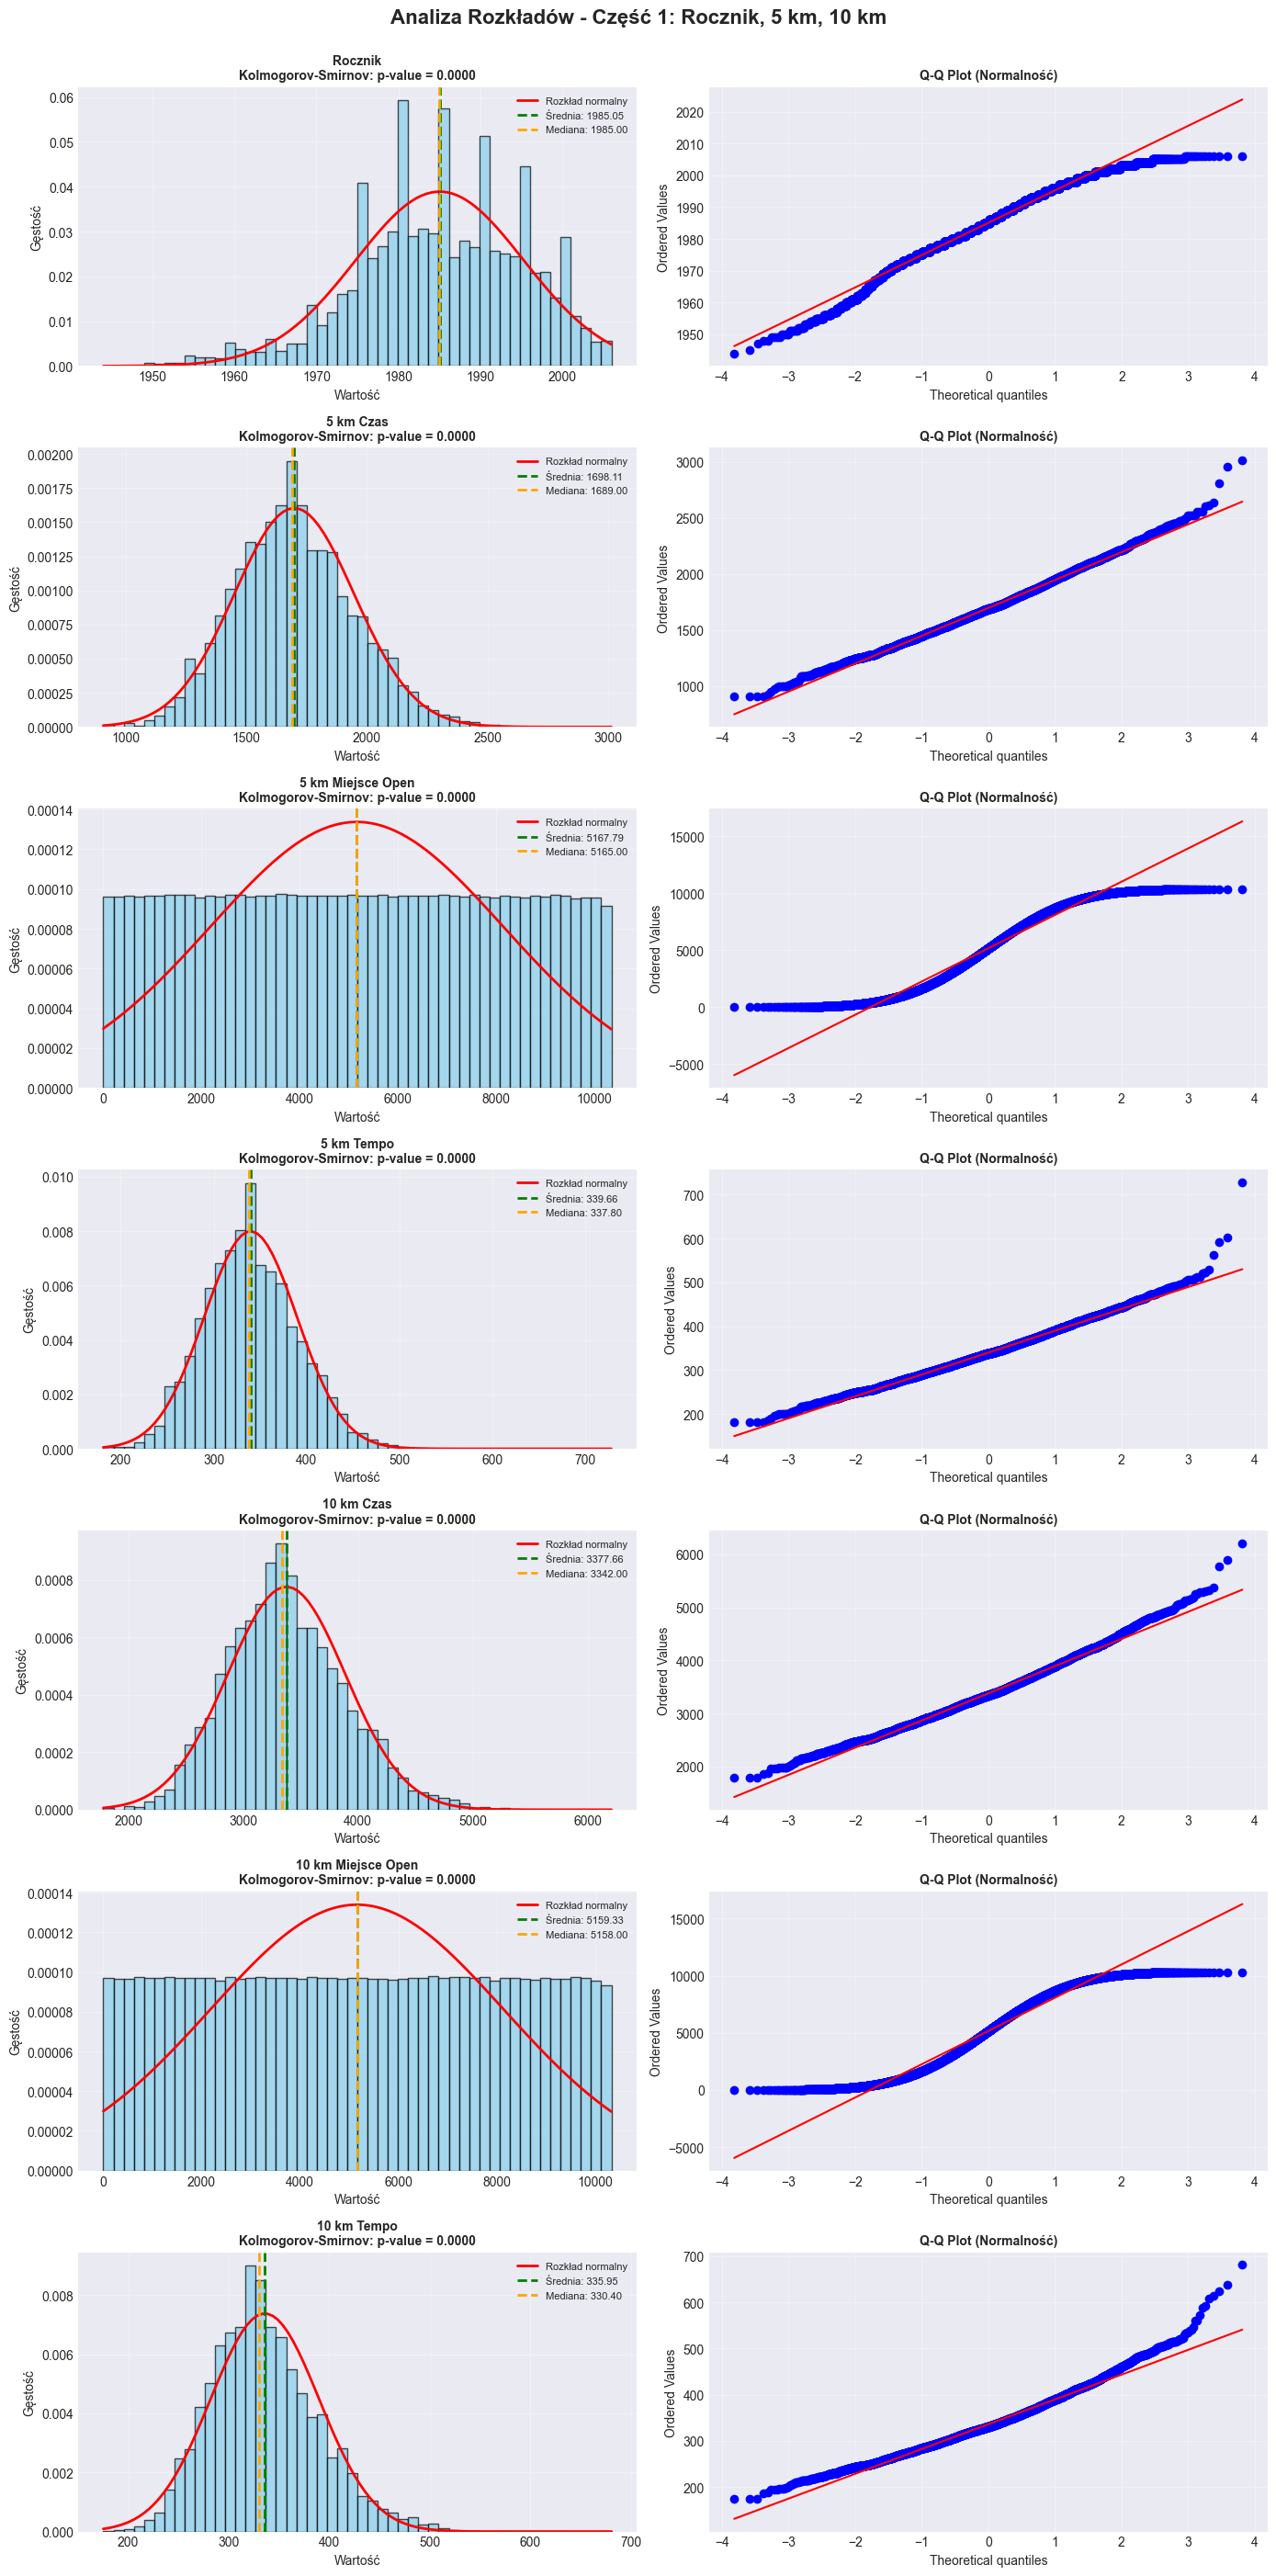


PODSUMOWANIE WYNIKÓW - CZĘŚĆ 1:

Rocznik:
  Średnia: 1985.05, Odch. std: 10.26, Mediana: 1985.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

5 km Czas:
  Średnia: 1698.11, Odch. std: 248.93, Mediana: 1689.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

5 km Miejsce Open:
  Średnia: 5167.79, Odch. std: 2982.28, Mediana: 5165.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

5 km Tempo:
  Średnia: 339.66, Odch. std: 49.93, Mediana: 337.80
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

10 km Czas:
  Średnia: 3377.66, Odch. std: 513.74, Mediana: 3342.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

10 km Miejsce Open:
  Średnia: 5159.33, Odch. std: 2978.88, Mediana: 5158.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

10 km Tempo:
  Średnia: 335.95, Odch. std: 54.11, Mediana: 330.40
  Test: Kolmogo

In [76]:
print("=" * 80)
print("ANALIZA ROZKŁADÓW - CZĘŚĆ 1:")
print("=" * 80)


part1_columns = ['Rocznik', '5 km Czas', '5 km Miejsce Open', '5 km Tempo', 
                 '10 km Czas', '10 km Miejsce Open', '10 km Tempo']
part1_columns = [col for col in part1_columns if col in df.columns]

n_cols = len(part1_columns)
fig, axes = plt.subplots(n_cols, 2, figsize=(14, 4 * n_cols))
fig.suptitle('Analiza Rozkładów - Część 1: Rocznik, 5 km, 10 km', fontsize=16, fontweight='bold', y=1.0)

results_part1 = []

if n_cols == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(part1_columns):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]
    
    result = analyze_distribution(df, col, ax1, ax2)
    if result:
        results_part1.append(result)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("PODSUMOWANIE WYNIKÓW - CZĘŚĆ 1:")
print("=" * 80)
for result in results_part1:
    print(f"\n{result['column']}:")
    print(f"  Średnia: {result['mean']:.2f}, Odch. std: {result['std']:.2f}, Mediana: {result['median']:.2f}")
    print(f"  Test: {result['test']}, p-value: {result['p_value']:.4f}")
    print(f"  {result['normality']}")


ANALIZA ROZKŁADÓW - CZĘŚĆ 2:


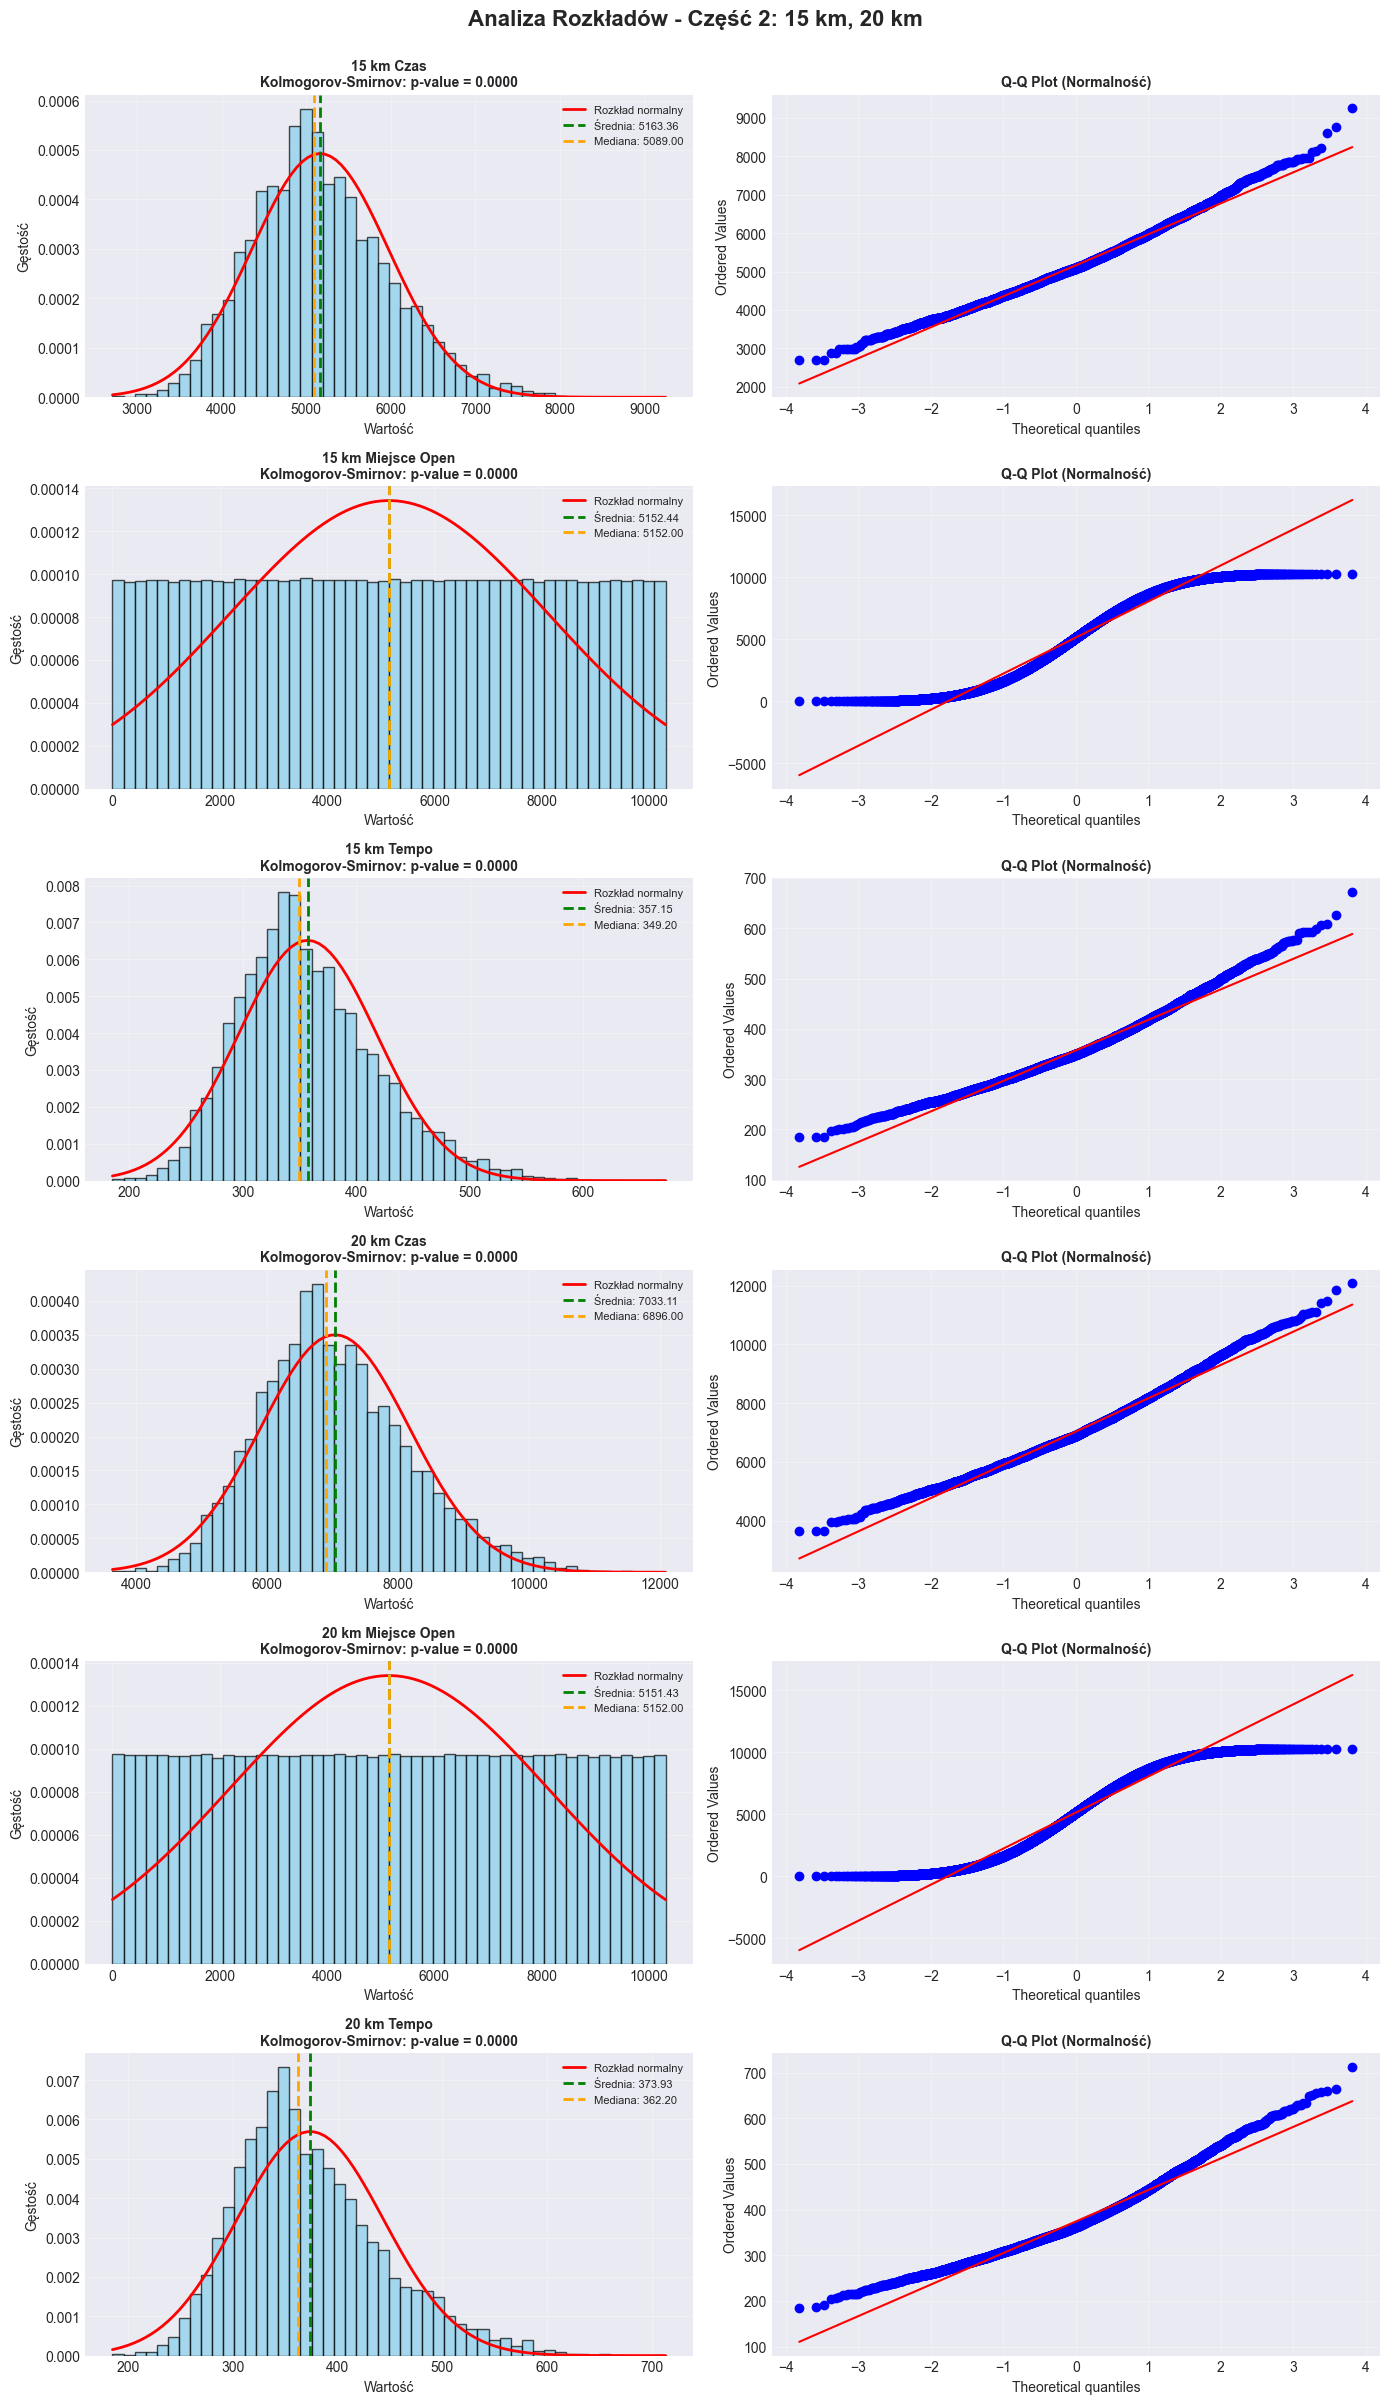


PODSUMOWANIE WYNIKÓW - CZĘŚĆ 2:

15 km Czas:
  Średnia: 5163.36, Odch. std: 809.65, Mediana: 5089.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

15 km Miejsce Open:
  Średnia: 5152.44, Odch. std: 2972.94, Mediana: 5152.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

15 km Tempo:
  Średnia: 357.15, Odch. std: 61.24, Mediana: 349.20
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

20 km Czas:
  Średnia: 7033.11, Odch. std: 1139.86, Mediana: 6896.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

20 km Miejsce Open:
  Średnia: 5151.43, Odch. std: 2974.69, Mediana: 5152.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

20 km Tempo:
  Średnia: 373.93, Odch. std: 70.07, Mediana: 362.20
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)


In [77]:
print("=" * 80)
print("ANALIZA ROZKŁADÓW - CZĘŚĆ 2:")
print("=" * 80)

part2_columns = ['15 km Czas', '15 km Miejsce Open', '15 km Tempo',
                 '20 km Czas', '20 km Miejsce Open', '20 km Tempo']
part2_columns = [col for col in part2_columns if col in df.columns]

n_cols = len(part2_columns)
fig, axes = plt.subplots(n_cols, 2, figsize=(14, 4 * n_cols))
fig.suptitle('Analiza Rozkładów - Część 2: 15 km, 20 km', fontsize=16, fontweight='bold', y=1.0)

results_part2 = []

if n_cols == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(part2_columns):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]
    
    result = analyze_distribution(df, col, ax1, ax2)
    if result:
        results_part2.append(result)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("PODSUMOWANIE WYNIKÓW - CZĘŚĆ 2:")
print("=" * 80)
for result in results_part2:
    print(f"\n{result['column']}:")
    print(f"  Średnia: {result['mean']:.2f}, Odch. std: {result['std']:.2f}, Mediana: {result['median']:.2f}")
    print(f"  Test: {result['test']}, p-value: {result['p_value']:.4f}")
    print(f"  {result['normality']}")


## Analiza przydatności kolumn "Miejsce Open" dla modelu ML



ANALIZA ROZKŁADÓW - CZĘŚĆ 3:


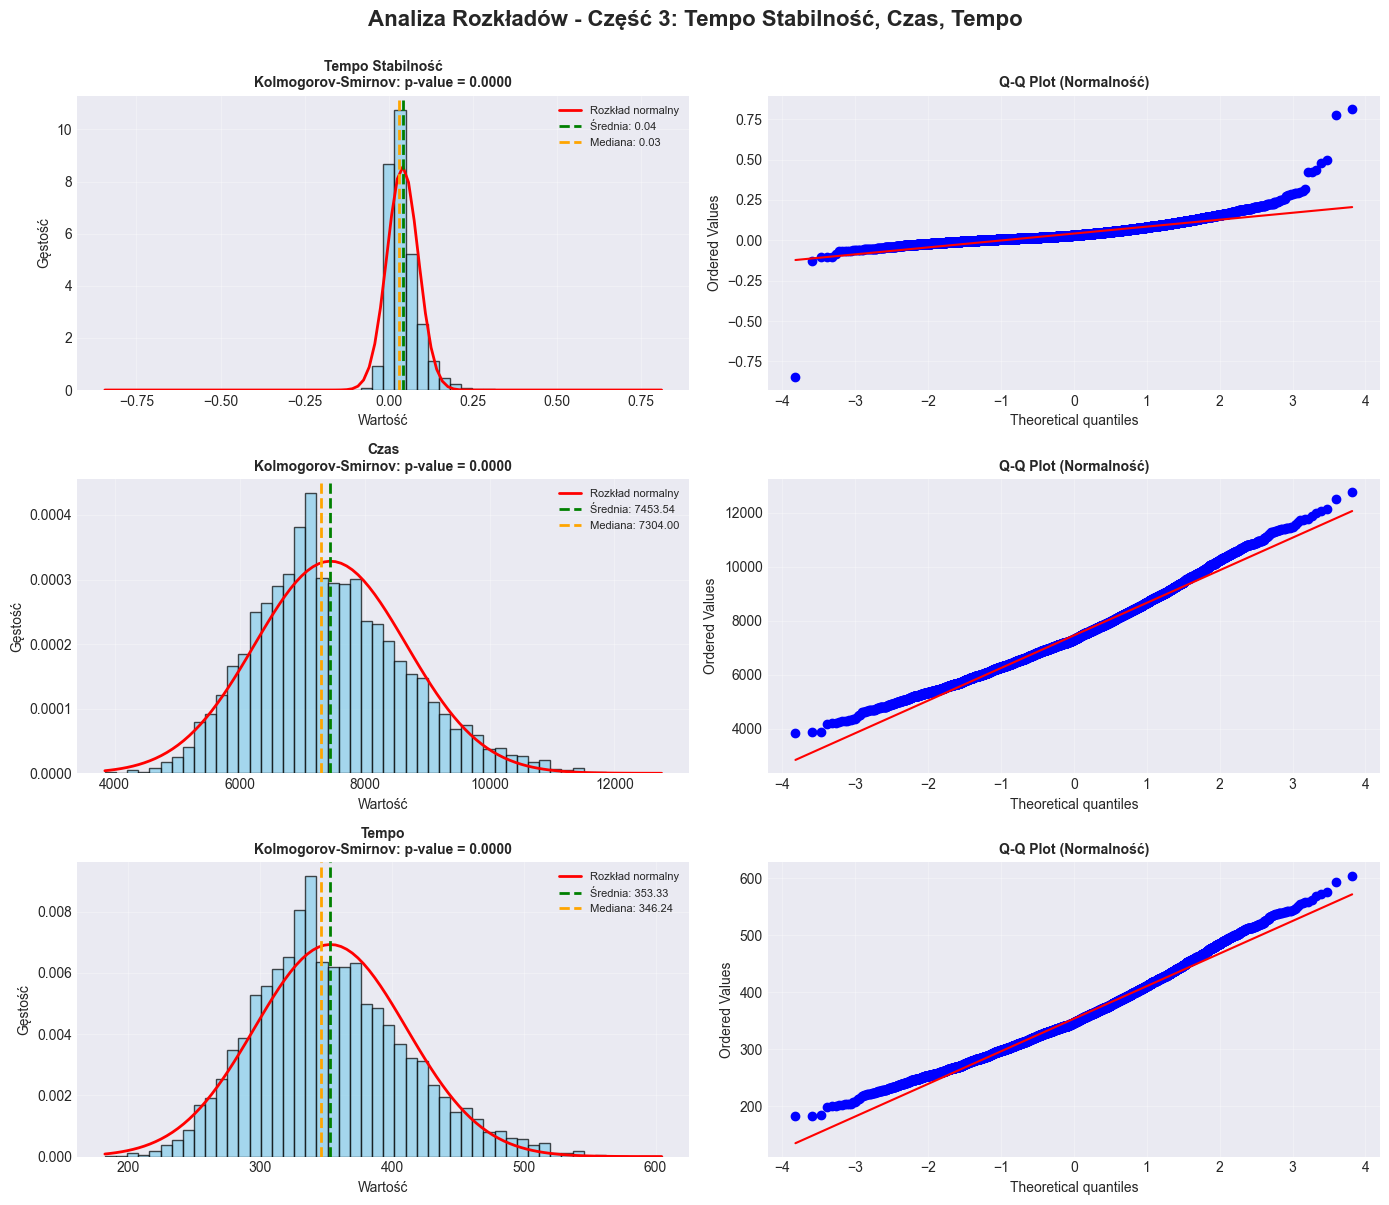


PODSUMOWANIE WYNIKÓW - CZĘŚĆ 3:

Tempo Stabilność:
  Średnia: 0.04, Odch. std: 0.05, Mediana: 0.03
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

Czas:
  Średnia: 7453.54, Odch. std: 1214.99, Mediana: 7304.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

Tempo:
  Średnia: 353.33, Odch. std: 57.60, Mediana: 346.24
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)


In [78]:
print("=" * 80)
print("ANALIZA ROZKŁADÓW - CZĘŚĆ 3:")
print("=" * 80)

part3_columns = ['Tempo Stabilność', 'Czas', 'Tempo']
part3_columns = [col for col in part3_columns if col in df.columns]

n_cols = len(part3_columns)
fig, axes = plt.subplots(n_cols, 2, figsize=(14, 4 * n_cols))
fig.suptitle('Analiza Rozkładów - Część 3: Tempo Stabilność, Czas, Tempo', fontsize=16, fontweight='bold', y=1.0)

results_part3 = []

if n_cols == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(part3_columns):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]
    
    result = analyze_distribution(df, col, ax1, ax2)
    if result:
        results_part3.append(result)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("PODSUMOWANIE WYNIKÓW - CZĘŚĆ 3:")
print("=" * 80)
for result in results_part3:
    print(f"\n{result['column']}:")
    print(f"  Średnia: {result['mean']:.2f}, Odch. std: {result['std']:.2f}, Mediana: {result['median']:.2f}")
    print(f"  Test: {result['test']}, p-value: {result['p_value']:.4f}")
    print(f"  {result['normality']}")


In [79]:
df.loc[df['Miejsce'] ==  5576]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
5575,5576.0,M,4610.0,M50,486.0,1973.0,1767,6527.0,353.4,3442,6058.0,335.0,5278.0,6093.0,367.2,7033.0,5588.0,351.0,0.008333,7453.0,353.306471


In [80]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    0
Tempo Stabilność               0
Czas                           0
Tempo                          0
dtype: int64

## Analiza Boxplot - Wykrywanie wartości odstających

Boxploty pozwalają zidentyfikować wartości odstające (outliers) w danych. 

Dla każdej kolumny związanej z kilometrami (5, 10, 15, 20) oraz dla końcowych wartości sprawdzimy:
- **Miejsce Open** - pozycja zawodnika
- **Czas** - czas na danym kilometrze
- **Tempo** - tempo na danym kilometrze
- **Tempo Stabilność** - stabilność tempa
- **Czas** (końcowy) - całkowity czas
- **Tempo** (końcowe) - końcowe tempo

Wartości odstające to punkty poza "wąsami" boxplotu (zwykle > 1.5 * IQR od kwartyli).


ANALIZA BOXPLOT - WYKRYWANIE WARTOŚCI ODSTAJĄCYCH

✓ Znaleziono 15 kolumn do analizy


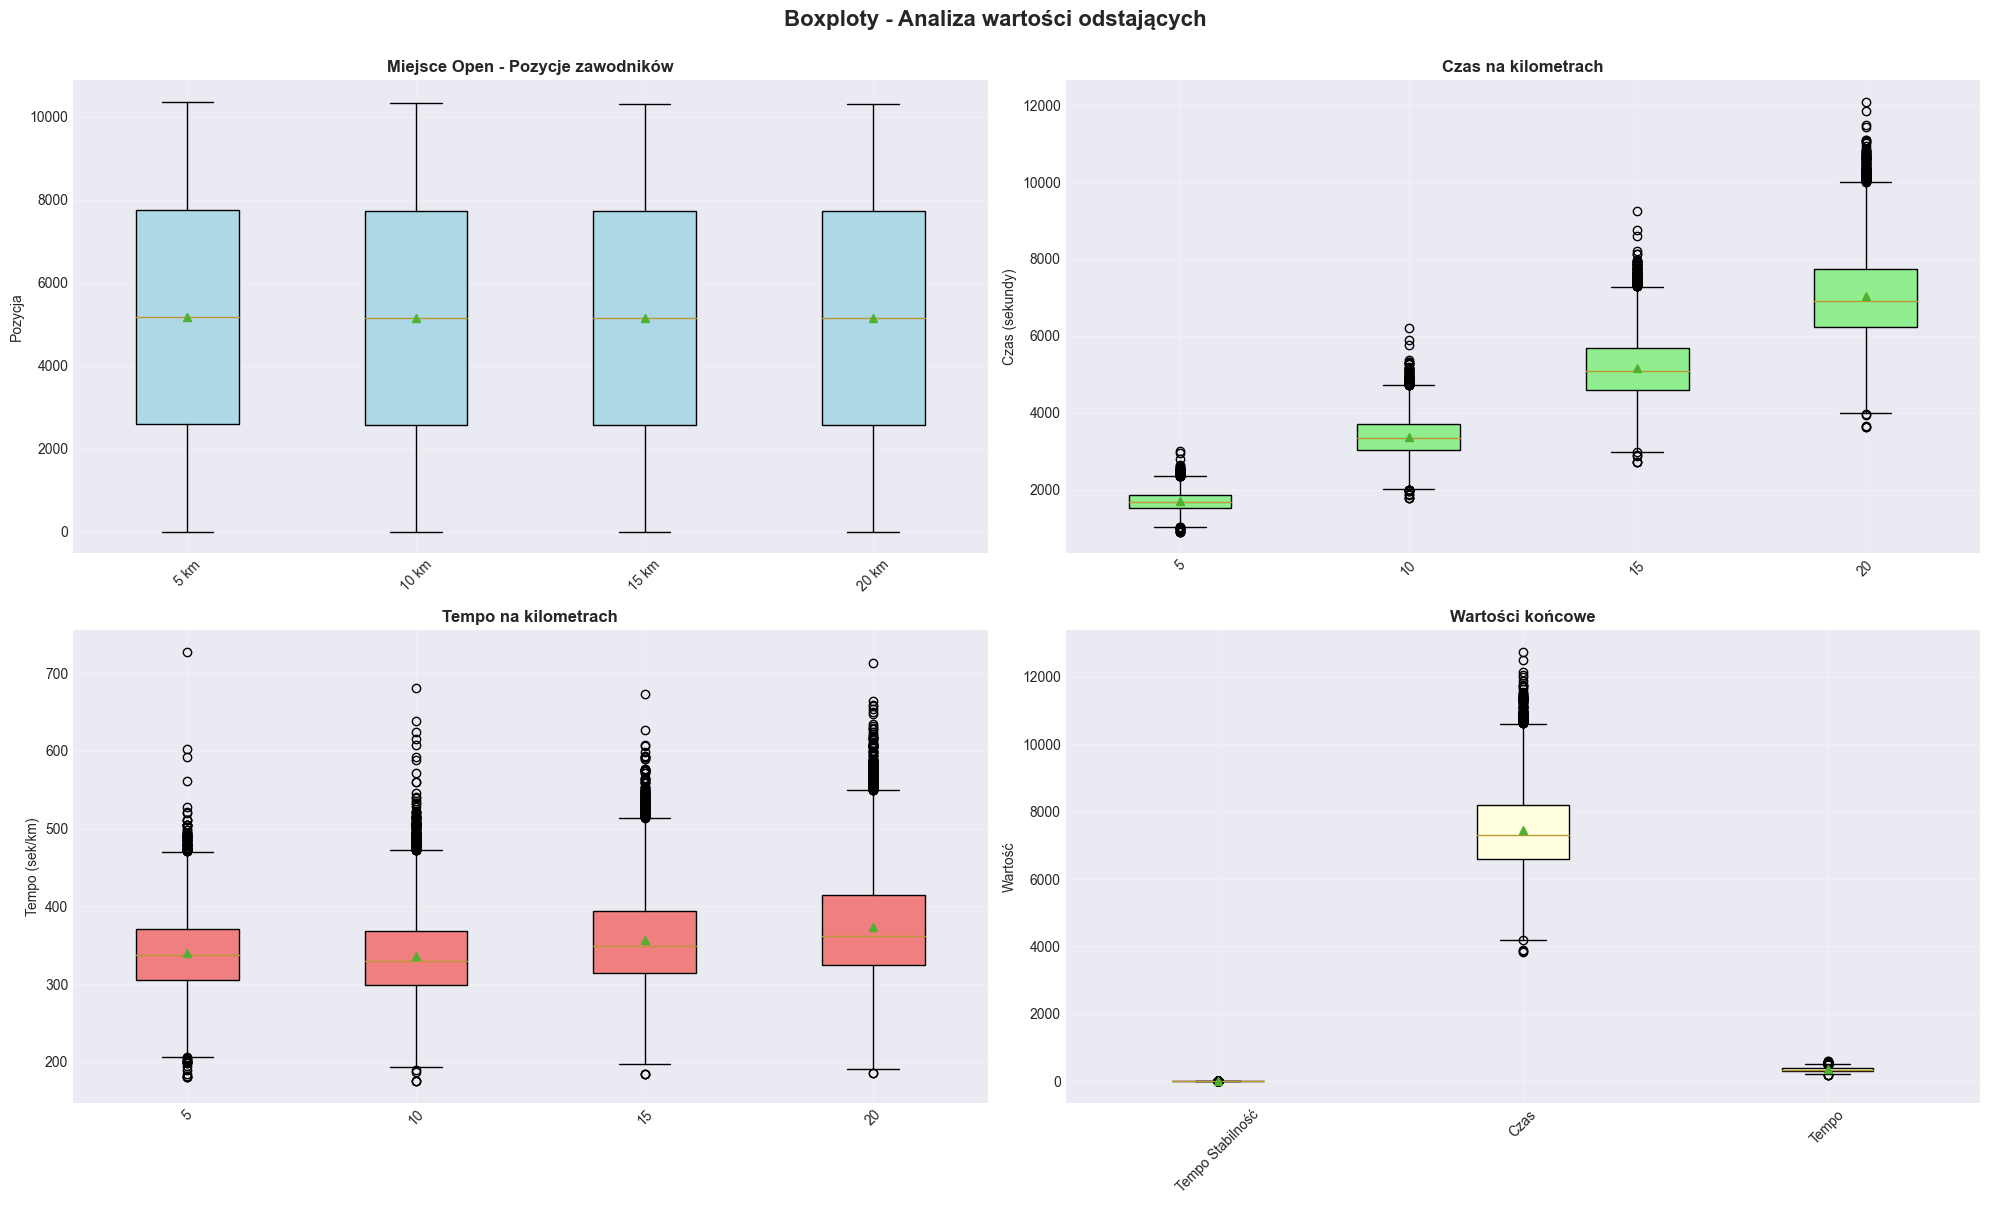


SZCZEGÓŁOWA ANALIZA WARTOŚCI ODSTAJĄCYCH:

            Column Total Outliers Outlier %      Q1  Median      Q3 Lower Bound Upper Bound     Min      Max
         5 km Czas 10279       94     0.91% 1526.00 1689.00 1857.00     1029.50     2353.50  906.00  3014.00
 5 km Miejsce Open 10279        0     0.00% 2587.50 5165.00 7746.50    -5151.00    15485.00    2.00 10353.00
        5 km Tempo 10279       95     0.92%  305.20  337.80  371.40      205.90      470.70  181.20   727.87
        10 km Czas 10279      124     1.21% 3020.00 3342.00 3697.00     2004.50     4712.50 1782.00  6208.00
10 km Miejsce Open 10279        0     0.00% 2580.50 5158.00 7735.50    -5152.00    15468.00    1.00 10330.00
       10 km Tempo 10279      163     1.59%  298.40  330.40  368.00      194.00      472.40  175.20   680.80
        15 km Czas 10279      128     1.25% 4598.00 5089.00 5673.50     2984.75     7286.75 2707.00  9249.00
15 km Miejsce Open 10279        0     0.00% 2579.50 5152.00 7724.50    -5138.00    1

In [81]:
import numpy as np

print("=" * 80)
print("ANALIZA BOXPLOT - WYKRYWANIE WARTOŚCI ODSTAJĄCYCH")
print("=" * 80)

kilometer_columns = {
    '5 km': ['5 km Czas', '5 km Miejsce Open', '5 km Tempo'],
    '10 km': ['10 km Czas', '10 km Miejsce Open', '10 km Tempo'],
    '15 km': ['15 km Czas', '15 km Miejsce Open', '15 km Tempo'],
    '20 km': ['20 km Czas', '20 km Miejsce Open', '20 km Tempo']
}

final_columns = ['Tempo Stabilność', 'Czas', 'Tempo']

all_columns_to_plot = []
for km, cols in kilometer_columns.items():
    for col in cols:
        if col in df.columns:
            all_columns_to_plot.append(col)

for col in final_columns:
    if col in df.columns:
        all_columns_to_plot.append(col)

print(f"\n✓ Znaleziono {len(all_columns_to_plot)} kolumn do analizy")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Boxploty - Analiza wartości odstających', fontsize=16, fontweight='bold', y=1.0)

ax1 = axes[0, 0]
miejsce_cols = [col for col in all_columns_to_plot if 'Miejsce Open' in col]
if miejsce_cols:
    data_miejsce = [df[col].dropna() for col in miejsce_cols]
    bp1 = ax1.boxplot(data_miejsce, labels=[col.replace(' Miejsce Open', '') for col in miejsce_cols], 
                       patch_artist=True, showmeans=True)
    ax1.set_title('Miejsce Open - Pozycje zawodników', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Pozycja')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    for patch in bp1['boxes']:
        patch.set_facecolor('lightblue')
else:
    ax1.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax1.transAxes)


ax2 = axes[0, 1]
czas_cols = [col for col in all_columns_to_plot if 'km Czas' in col]
if czas_cols:
    data_czas = [df[col].dropna() for col in czas_cols]
    bp2 = ax2.boxplot(data_czas, labels=[col.replace(' km Czas', '') for col in czas_cols],
                      patch_artist=True, showmeans=True)
    ax2.set_title('Czas na kilometrach', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Czas (sekundy)')
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    for patch in bp2['boxes']:
        patch.set_facecolor('lightgreen')
else:
    ax2.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax2.transAxes)


ax3 = axes[1, 0]
tempo_cols = [col for col in all_columns_to_plot if 'km Tempo' in col]
if tempo_cols:
    data_tempo = [df[col].dropna() for col in tempo_cols]
    bp3 = ax3.boxplot(data_tempo, labels=[col.replace(' km Tempo', '') for col in tempo_cols],
                      patch_artist=True, showmeans=True)
    ax3.set_title('Tempo na kilometrach', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Tempo (sek/km)')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
    
    for patch in bp3['boxes']:
        patch.set_facecolor('lightcoral')
else:
    ax3.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax3.transAxes)


ax4 = axes[1, 1]
final_cols = [col for col in final_columns if col in all_columns_to_plot]
if final_cols:
    data_final = [df[col].dropna() for col in final_cols]
    bp4 = ax4.boxplot(data_final, labels=final_cols, patch_artist=True, showmeans=True)
    ax4.set_title('Wartości końcowe', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Wartość')
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
    
    for patch in bp4['boxes']:
        patch.set_facecolor('lightyellow')
else:
    ax4.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()


print("\n" + "=" * 80)
print("SZCZEGÓŁOWA ANALIZA WARTOŚCI ODSTAJĄCYCH:")
print("=" * 80)

def detect_outliers_iqr(data, column_name):
    """Wykrywa wartości odstające używając metody IQR"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers, lower_bound, upper_bound, Q1, Q3

outlier_summary = []

for col in all_columns_to_plot:
    data = df[col].dropna()
    if len(data) > 0:
        outliers, lower, upper, Q1, Q3 = detect_outliers_iqr(data, col)
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(data)) * 100 if len(data) > 0 else 0
        
        outlier_summary.append({
            'Column': col,
            'Total': str(len(data)),
            'Outliers': str(outlier_count),
            'Outlier %': f"{outlier_pct:.2f}%",
            'Q1': f"{Q1:.2f}",
            'Median': f"{data.median():.2f}",
            'Q3': f"{Q3:.2f}",
            'Lower Bound': f"{lower:.2f}",
            'Upper Bound': f"{upper:.2f}",
            'Min': f"{data.min():.2f}",
            'Max': f"{data.max():.2f}"
        })


if outlier_summary:
    summary_df = pd.DataFrame(outlier_summary)
    print("\n" + summary_df.to_string(index=False))
    
    
    print("\n" + "=" * 80)
    print("PODSUMOWANIE:")
    print("=" * 80)
    
    total_outliers = sum(int(row['Outliers']) for row in outlier_summary if row['Outliers'].isdigit())
    total_records = sum(int(row['Total']) for row in outlier_summary if row['Total'].isdigit())
    
    print(f"\n✓ Przeanalizowano: {len(outlier_summary)} kolumn")
    print(f"✓ Łączna liczba rekordów: {total_records}")
    print(f"✓ Łączna liczba wartości odstających: {total_outliers}")
    print(f"✓ Procent wartości odstających: {(total_outliers/total_records)*100:.2f}%")
    
    
    print("\n📊 Kolumny z największą liczbą wartości odstających:")
    sorted_summary = sorted(outlier_summary, key=lambda x: int(x['Outliers']) if x['Outliers'].isdigit() else 0, reverse=True)
    for idx, row in enumerate(sorted_summary[:5], 1):
        print(f"  {idx}. {row['Column']:30s}: {row['Outliers']} outliers ({row['Outlier %']})")
else:
    print("\n⚠ Nie znaleziono kolumn do analizy")


### 1784/13009 - 13.7%

In [82]:
df['Wiek'] = 2024 - df['Rocznik']
df


,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo,Wiek
0,1.0,M,1.0,M20,1.0,1998.0,906,3.0,181.2,1782,3.0,175.2,2707.0,2.0,185.0,3633.0,1.0,185.2,0.007267,3843.0,182.175871,26.0
1,2.0,M,2.0,M20,2.0,1997.0,906,4.0,181.2,1782,1.0,175.2,2707.0,3.0,185.0,3638.0,2.0,186.2,0.008267,3864.0,183.171368,27.0
2,3.0,M,3.0,M20,3.0,1998.0,906,2.0,181.2,1782,2.0,175.2,2707.0,1.0,185.0,3659.0,3.0,190.4,0.012467,3880.0,183.929841,26.0
3,4.0,M,4.0,M20,4.0,1997.0,947,7.0,189.4,1880,5.0,186.6,2868.0,4.0,197.6,3940.0,4.0,214.4,0.028667,4184.0,198.340839,27.0
4,5.0,M,5.0,M30,1.0,1992.0,907,5.0,181.4,1853,4.0,189.2,2889.0,5.0,207.2,3965.0,5.0,215.2,0.039800,4205.0,199.336336,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10295,10298.0,K,3059.0,K70,6.0,1948.0,2610,10344.0,522.0,5286,10321.0,535.2,7962.0,10298.0,529.99998,10638.0,10280.0,531.0,0.041167,11987.0,568.238919,76.0
10296,10299.0,K,3060.0,K40,1030.0,1978.0,2526,10337.0,505.2,5254,10318.0,545.6,8128.0,10301.0,574.8,11419.0,10303.0,658.2,0.162733,12068.0,572.078692,46.0
10297,10300.0,K,3061.0,K60,48.0,1955.0,2960,10352.0,592.0,5899,10329.0,587.8,8602.0,10303.0,540.6,11494.0,10304.0,578.4,-0.029333,12138.0,575.397014,69.0
10298,10301.0,K,3062.0,K40,1031.0,1981.0,2808,10350.0,561.6,5769,10328.0,592.2,8763.0,10304.0,598.8,11845.0,10305.0,616.4,0.057000,12512.0,593.126333,43.0


In [83]:
df_with_outliers = df.copy()

In [84]:
df_with_outliers.head()


,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo,Wiek
0,1.0,M,1.0,M20,1.0,1998.0,906,3.0,181.2,1782,3.0,175.2,2707.0,2.0,185.0,3633.0,1.0,185.2,0.007267,3843.0,182.175871,26.0
1,2.0,M,2.0,M20,2.0,1997.0,906,4.0,181.2,1782,1.0,175.2,2707.0,3.0,185.0,3638.0,2.0,186.2,0.008267,3864.0,183.171368,27.0
2,3.0,M,3.0,M20,3.0,1998.0,906,2.0,181.2,1782,2.0,175.2,2707.0,1.0,185.0,3659.0,3.0,190.4,0.012467,3880.0,183.929841,26.0
3,4.0,M,4.0,M20,4.0,1997.0,947,7.0,189.4,1880,5.0,186.6,2868.0,4.0,197.6,3940.0,4.0,214.4,0.028667,4184.0,198.340839,27.0
4,5.0,M,5.0,M30,1.0,1992.0,907,5.0,181.4,1853,4.0,189.2,2889.0,5.0,207.2,3965.0,5.0,215.2,0.039800,4205.0,199.336336,32.0


In [85]:
df_with_outliers.isna().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    0
Tempo Stabilność               0
Czas                           0
Tempo                          0
Wiek                         284
dtype: int64

In [86]:
df['Płeć'].value_counts()

Płeć
M    7220
K    3059
Name: count, dtype: int64

#### Mamy doczynienia z niezbalansowanymi danymi ponad 2.5 razy wiecej panów

In [87]:
# !conda install -y conda-forge::pandera
import pandera as pa

In [ ]:
##!pip install --quiet black pyyaml frictionless

In [88]:
import numpy as np
from sklearn.impute import KNNImputer

df['Rocznik'] = pd.to_numeric(df['Rocznik'], errors='coerce')
df['5 km Czas'] = pd.to_numeric(df['5 km Czas'], errors='coerce')
df['Czas'] = pd.to_numeric(df['Czas'], errors='coerce')

df['Wiek'] = 2024 - df['Rocznik']


def uzupelnij_tylko_brakujacy_wiek(group):
    
    if group['Wiek'].isna().sum() == 0:
        return group
    
   
    if len(group) < 5:
        group['Wiek'] = group['Wiek'].fillna(group['Wiek'].median())
        return group

    
    imputer = KNNImputer(n_neighbors=5, weights='distance')
    dane_wejsciowe = group[['5 km Czas', 'Wiek']].values
    
    dane_uzupelnione = imputer.fit_transform(dane_wejsciowe)
    
    
    group['Wiek'] = dane_uzupelnione[:, 1]
    
    return group

df = df.groupby('Kategoria wiekowa', group_keys=False).apply(uzupelnij_tylko_brakujacy_wiek)

df['Wiek'] = df['Wiek'].round()

In [90]:


infered_schema = pa.infer_schema(df)
schema_script = infered_schema.to_script()

with open('generated_schema.py', 'w', encoding='utf-8') as f:
    f.write(schema_script)

print("="*80)
print("Schema generated and saved to 'generated_schema.py'")
print("You can:")
print("1. Open the file 'generated_schema.py' to copy the schema")
print("2. Or run in next cell: print(schema_script)")
print("="*80)
print(f"\nSchema length: {len(schema_script)} characters")
print(f"File saved: generated_schema.py")



c:\Users\Admin\miniconda3\envs\zad9_domowe\Lib\site-packages\pandera\schema_statistics\pandas.py:214: UserWarning: You do not need more than one check out of equal_to (eq), greater_than (gt), less_than (lt), greater_than_or_equal_to (lt), less_than_or_equal_to (le), in_range (between).
  warnings.warn(


Schema generated and saved to 'generated_schema.py'
You can:
1. Open the file 'generated_schema.py' to copy the schema
2. Or run in next cell: print(schema_script)

Schema length: 12900 characters
File saved: generated_schema.py


In [91]:

from pandera import DataFrameSchema, Column, Check, Index
import pandera.pandas as pa

corrected_columns = {}

for col_name, col_def in infered_schema.columns.items():
    
    checks = col_def.checks if col_def.checks else None
    nullable = col_def.nullable
    required = col_def.required
    
    
    if "Miejsce" in col_name:
        
        dtype = "int64"
        coerce = True  
    elif "Czas" in col_name:
        
        dtype = "int64"
        coerce = True  
        if col_def.dtype != "int64":
            print(f"✓ Changed '{col_name}': {col_def.dtype} -> int64")
        else:
            print(f"  '{col_name}' already int64 (OK)")
    elif col_name == "Wiek":
        
        dtype = "Int64"  
        coerce = True  
        print(f"✓ Changed '{col_name}': {col_def.dtype} -> Int64 (nullable integer, NaN acceptable)")
    elif col_name == "Rocznik":
        
        dtype = "Int64"  
        coerce = True  
        print(f"✓ Changed '{col_name}': {col_def.dtype} -> Int64 (nullable integer, NaN acceptable)")
    elif col_name == "Płeć" or col_name == "Kategoria wiekowa":
       
        dtype = "category"
        coerce = True  
        print(f"✓ Changed '{col_name}': {col_def.dtype} -> category")
    elif col_def.dtype == "object":
        
        dtype = "category"
        coerce = True  
        print(f"✓ Changed '{col_name}': object -> category")
    else:
        
        dtype = col_def.dtype
        coerce = col_def.coerce
    
    
    corrected_columns[col_name] = Column(
        dtype=dtype,
        checks=checks,  
        nullable=nullable,
        coerce=coerce,
        required=required
    )


if "Wiek" not in corrected_columns and "Wiek" in df.columns:
    
    corrected_columns["Wiek"] = Column(
        dtype="Int64",  
        checks=None,  
        nullable=True,  
        coerce=True,  
        required=True
    )
    print("✓ Added 'Wiek' column to schema: Int64 (nullable integer, NaN acceptable)")


corrected_schema = DataFrameSchema(
    columns=corrected_columns,
    index=infered_schema.index,  
    checks=infered_schema.checks,  
    coerce=True,
    strict=infered_schema.strict
)

print("\n" + "="*80)
print("✓ Corrected schema created WITH value range checks!")
print("="*80)
print(f"\nSchema saved as 'corrected_schema'")
print("This schema validates:")
print("  - Data types (int64, float64, category)")
print("  - Value ranges (min/max constraints)")
print("  - Required columns")
print("  - Nullable constraints")
print("\nYou can use it with: corrected_schema.validate(df)")

✓ Changed 'Płeć': object -> category
✓ Changed 'Kategoria wiekowa': object -> category
✓ Changed 'Rocznik': float64 -> Int64 (nullable integer, NaN acceptable)
✓ Changed '5 km Czas': int64 -> int64
✓ Changed '10 km Czas': int64 -> int64
✓ Changed '15 km Czas': float64 -> int64
✓ Changed '20 km Czas': float64 -> int64
✓ Changed 'Czas': float64 -> int64
✓ Changed 'Wiek': float64 -> Int64 (nullable integer, NaN acceptable)

✓ Corrected schema created WITH value range checks!

Schema saved as 'corrected_schema'
This schema validates:
  - Data types (int64, float64, category)
  - Value ranges (min/max constraints)
  - Required columns
  - Nullable constraints

You can use it with: corrected_schema.validate(df)


c:\Users\Admin\miniconda3\envs\zad9_domowe\Lib\site-packages\pandera\_pandas_deprecated.py:146: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


In [92]:
corrected_schema_script = corrected_schema.to_script()

with open('corrected_schema.py', 'w', encoding='utf-8') as f:
    f.write(corrected_schema_script)

c:\Users\Admin\miniconda3\envs\zad9_domowe\Lib\site-packages\pandera\schema_statistics\pandas.py:214: UserWarning: You do not need more than one check out of equal_to (eq), greater_than (gt), less_than (lt), greater_than_or_equal_to (lt), less_than_or_equal_to (le), in_range (between).
  warnings.warn(


In [93]:


try:
    validated_df = corrected_schema.validate(df)  
    print("="*80)
    print("✓ VALIDATION SUCCESSFUL!")
    print("="*80)
    print(f"\nValidated DataFrame shape: {validated_df.shape}")
    print(f"\nValidated DataFrame dtypes:")
    print(validated_df.dtypes)
    print("\n✓ All data conforms to the schema")
    
except pa.errors.SchemaErrors as e:
    print("="*80)
    print("✗ VALIDATION FAILED - Schema Errors Found")
    print("="*80)
    
    failure_df = e.failure_cases
    print(f"\nTotal failure cases: {len(failure_df)}")
    print(f"\n{'='*80}")
    print("FAILURE CASES (detailed):")
    print("="*80)
    
    import pandas as pd
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None, 'display.max_colwidth', None):
        print(failure_df)
    
    print(f"\n{'='*80}")
    print("SUMMARY BY COLUMN:")
    print("="*80)
    if 'column' in failure_df.columns:
        print(failure_df['column'].value_counts())
    
    print(f"\n{'='*80}")
    print("SUMMARY BY ERROR TYPE:")
    print("="*80)
    if 'check' in failure_df.columns:
        print(failure_df['check'].value_counts())
    
    print("\n" + "="*80)
    print("Full error object:")
    print("="*80)
    print(e)
    
    
    print("\n" + "="*80)
    print("NOTE: If errors are about 'Rocznik' with NaN values - this is acceptable!")
    print("Records with missing 'Rocznik' have 'Kategoria wiekowa' which is sufficient.")
    print("="*80)

✓ VALIDATION SUCCESSFUL!

Validated DataFrame shape: (10279, 22)

Validated DataFrame dtypes:
Miejsce                         int64
Płeć                         category
Płeć Miejsce                    int64
Kategoria wiekowa            category
Kategoria wiekowa Miejsce       int64
Rocznik                         Int64
5 km Czas                       int64
5 km Miejsce Open               int64
5 km Tempo                    float64
10 km Czas                      int64
10 km Miejsce Open              int64
10 km Tempo                   float64
15 km Czas                      int64
15 km Miejsce Open              int64
15 km Tempo                   float64
20 km Czas                      int64
20 km Miejsce Open              int64
20 km Tempo                   float64
Tempo Stabilność              float64
Czas                            int64
Tempo                         float64
Wiek                            Int64
dtype: object

✓ All data conforms to the schema


In [94]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      284
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    0
Tempo Stabilność               0
Czas                           0
Tempo                          0
Wiek                           0
dtype: int64

In [95]:
## !pip install pycaret

In [96]:
df_without_outliers = df.copy()

In [ ]:
# 5 km Czas 10279       94     
#         5 km Tempo 10279       95     
#         10 km Czas 10279      124    
#        10 km Tempo 10279      163     
#         15 km Czas 10279      128     
#        15 km Tempo 10279      155     
#         20 km Czas 10279      128     
#        20 km Tempo 10279      198     
#   Tempo Stabilność 10279      449    
#               Czas 10279      125     
#              Tempo 10279      125    

##### Następną komórkę z kodem trzeba odpalać do momentu ilości rekordów 9214 wtedy boxploty pokazują 0 wszędzie

In [111]:
kolumny_do_sprawdzenia = ["Czas", "5 km Czas", "5 km Tempo","10 km Czas","10 km Tempo","15 km Czas",
"15 km Tempo","20 km Czas","20 km Tempo","Tempo Stabilność","Tempo"]

Q1 = df_without_outliers[kolumny_do_sprawdzenia].quantile(0.25)
Q3 = df_without_outliers[kolumny_do_sprawdzenia].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (df_without_outliers[kolumny_do_sprawdzenia] < lower_bound) | (df_without_outliers[kolumny_do_sprawdzenia] > upper_bound)
df_without_outliers = df_without_outliers[~outliers_mask.any(axis=1)]
print(f"Pozostało rekordów: {len(df_without_outliers)}")

Pozostało rekordów: 9214


ANALIZA BOXPLOT - WERYFIKACJA PO USUNIĘCIU OUTLIERÓW

✓ Znaleziono 15 kolumn do weryfikacji w wyczyszczonym zbiorze


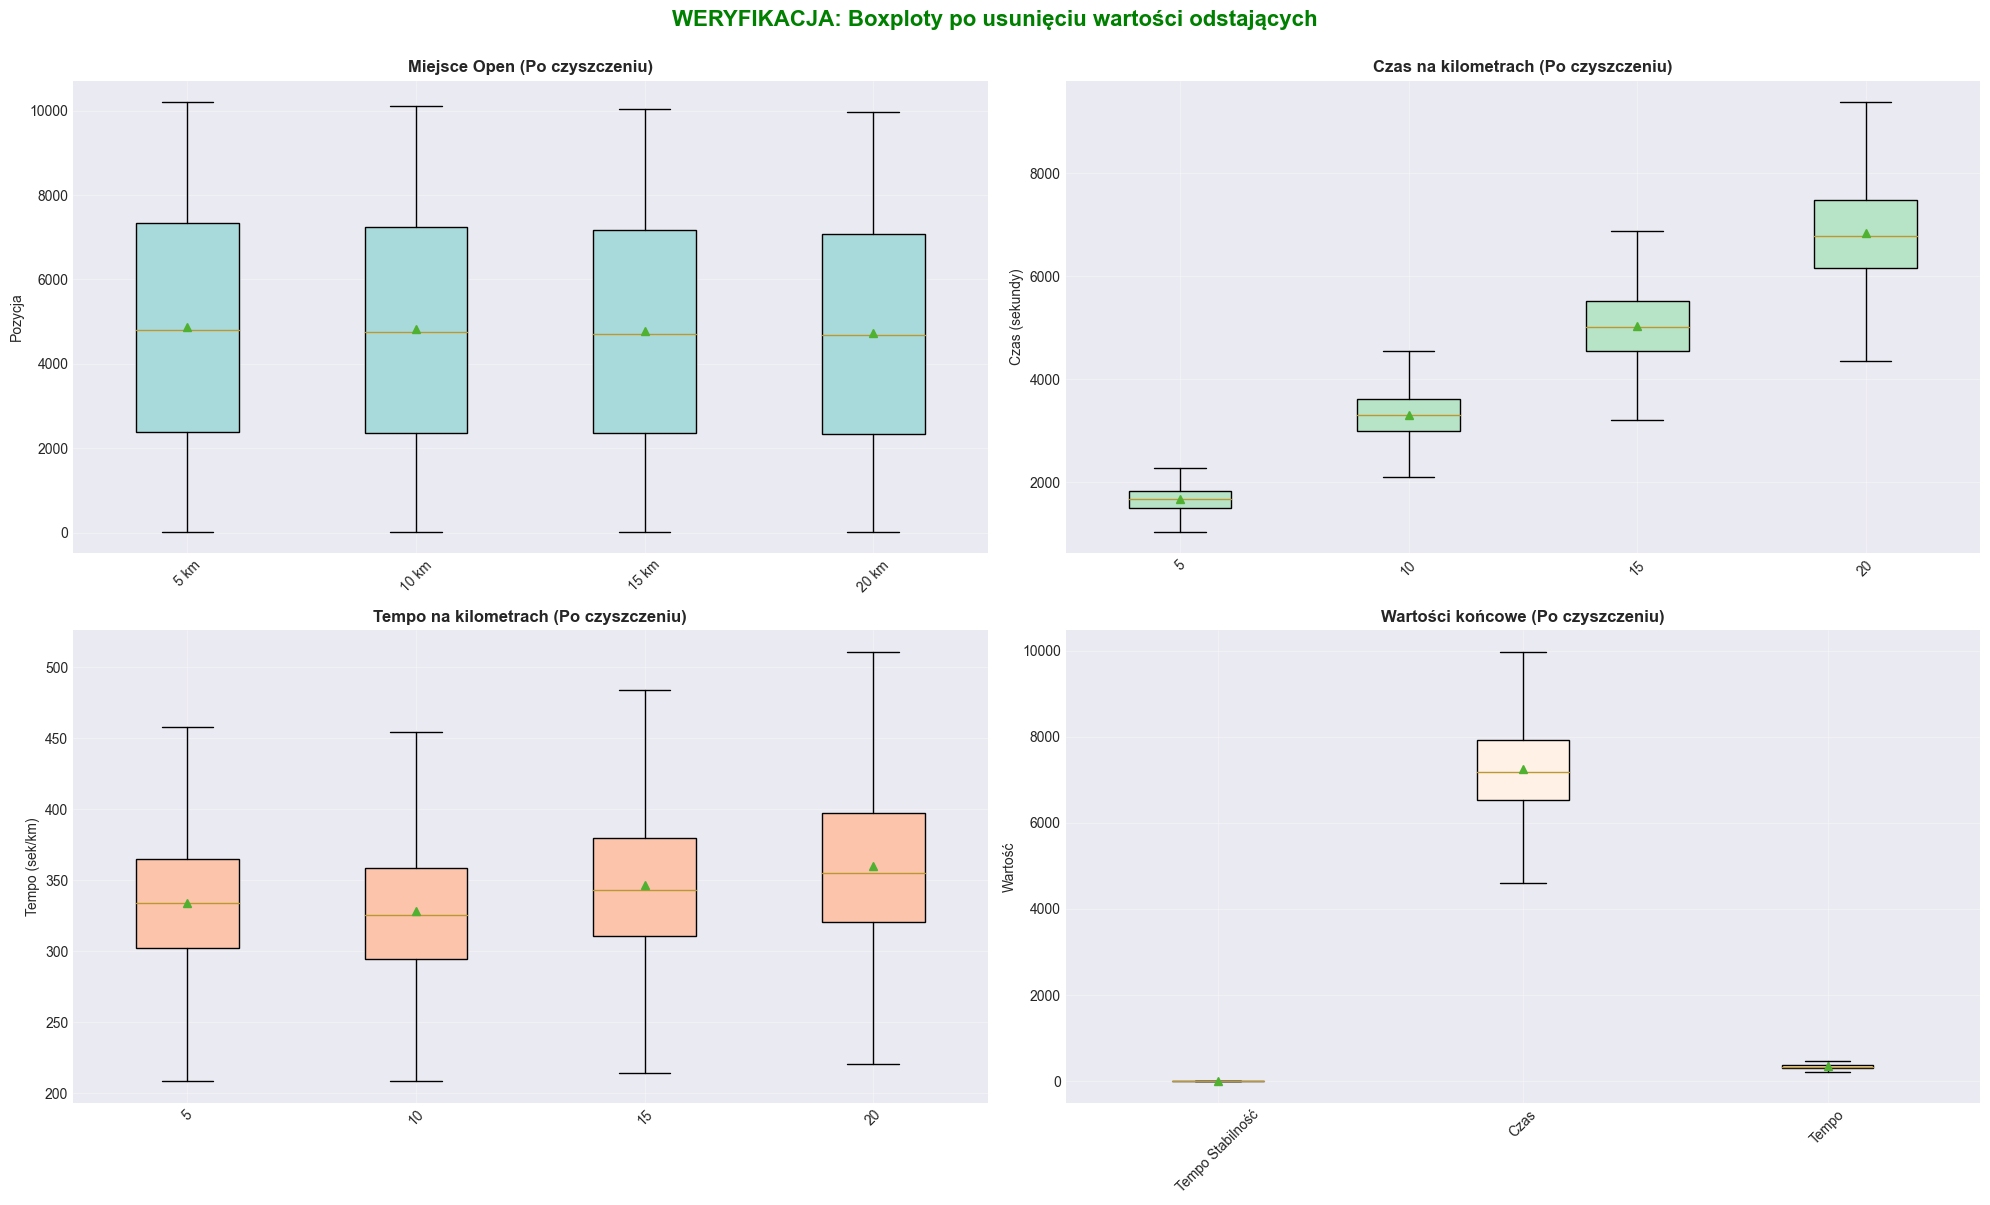


SZCZEGÓŁOWA ANALIZA STATYSTYCZNA (PO CZYSZCZENIU):

            Column   Status Outliers Outlier %     Min      Max
         5 km Czas ✅ CZYSTO        0     0.00% 1042.00  2288.00
 5 km Miejsce Open ✅ CZYSTO        0     0.00%   22.00 10203.00
        5 km Tempo ✅ CZYSTO        0     0.00%  208.40   457.60
        10 km Czas ✅ CZYSTO        0     0.00% 2112.00  4549.00
10 km Miejsce Open ✅ CZYSTO        0     0.00%   21.00 10118.00
       10 km Tempo ✅ CZYSTO        0     0.00%  208.80   454.20
        15 km Czas ✅ CZYSTO        0     0.00% 3210.00  6880.00
15 km Miejsce Open ✅ CZYSTO        0     0.00%   20.00 10032.00
       15 km Tempo ✅ CZYSTO        0     0.00%  214.20   484.20
        20 km Czas ✅ CZYSTO        0     0.00% 4349.00  9384.00
20 km Miejsce Open ✅ CZYSTO        0     0.00%   19.00  9971.00
       20 km Tempo ✅ CZYSTO        0     0.00%  220.40   511.00
  Tempo Stabilność ✅ CZYSTO        0     0.00%   -0.05     0.11
              Czas ✅ CZYSTO        0     0.00% 4604

In [112]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_analyzed = df_without_outliers.copy()

print("=" * 80)
print("ANALIZA BOXPLOT - WERYFIKACJA PO USUNIĘCIU OUTLIERÓW")
print("=" * 80)

kilometer_columns = {
    '5 km': ['5 km Czas', '5 km Miejsce Open', '5 km Tempo'],
    '10 km': ['10 km Czas', '10 km Miejsce Open', '10 km Tempo'],
    '15 km': ['15 km Czas', '15 km Miejsce Open', '15 km Tempo'],
    '20 km': ['20 km Czas', '20 km Miejsce Open', '20 km Tempo']
}

final_columns = ['Tempo Stabilność', 'Czas', 'Tempo']

all_columns_to_plot = []
for km, cols in kilometer_columns.items():
    for col in cols:
        if col in df_analyzed.columns:
            all_columns_to_plot.append(col)

for col in final_columns:
    if col in df_analyzed.columns:
        all_columns_to_plot.append(col)

print(f"\n✓ Znaleziono {len(all_columns_to_plot)} kolumn do weryfikacji w wyczyszczonym zbiorze")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('WERYFIKACJA: Boxploty po usunięciu wartości odstających', fontsize=16, fontweight='bold', color='green', y=1.0)

ax1 = axes[0, 0]
miejsce_cols = [col for col in all_columns_to_plot if 'Miejsce Open' in col]
if miejsce_cols:
    data_miejsce = [df_analyzed[col].dropna() for col in miejsce_cols]
    bp1 = ax1.boxplot(data_miejsce, labels=[col.replace(' Miejsce Open', '') for col in miejsce_cols], 
                        patch_artist=True, showmeans=True)
    ax1.set_title('Miejsce Open (Po czyszczeniu)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Pozycja')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    for patch in bp1['boxes']:
        patch.set_facecolor('#a8dadc')
else:
    ax1.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax1.transAxes)

ax2 = axes[0, 1]
czas_cols = [col for col in all_columns_to_plot if 'km Czas' in col]
if czas_cols:
    data_czas = [df_analyzed[col].dropna() for col in czas_cols]
    bp2 = ax2.boxplot(data_czas, labels=[col.replace(' km Czas', '') for col in czas_cols],
                      patch_artist=True, showmeans=True)
    ax2.set_title('Czas na kilometrach (Po czyszczeniu)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Czas (sekundy)')
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    for patch in bp2['boxes']:
        patch.set_facecolor('#b7e4c7') 
else:
    ax2.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax2.transAxes)

ax3 = axes[1, 0]
tempo_cols = [col for col in all_columns_to_plot if 'km Tempo' in col]
if tempo_cols:
    data_tempo = [df_analyzed[col].dropna() for col in tempo_cols]
    bp3 = ax3.boxplot(data_tempo, labels=[col.replace(' km Tempo', '') for col in tempo_cols],
                      patch_artist=True, showmeans=True)
    ax3.set_title('Tempo na kilometrach (Po czyszczeniu)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Tempo (sek/km)')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
    
    for patch in bp3['boxes']:
        patch.set_facecolor('#fbc4ab')
else:
    ax3.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax3.transAxes)

ax4 = axes[1, 1]
final_cols = [col for col in final_columns if col in all_columns_to_plot]
if final_cols:
    data_final = [df_analyzed[col].dropna() for col in final_cols]
    bp4 = ax4.boxplot(data_final, labels=final_cols, patch_artist=True, showmeans=True)
    ax4.set_title('Wartości końcowe (Po czyszczeniu)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Wartość')
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
    
    for patch in bp4['boxes']:
        patch.set_facecolor('#fff1e6') 
else:
    ax4.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()


print("\n" + "=" * 80)
print("SZCZEGÓŁOWA ANALIZA STATYSTYCZNA (PO CZYSZCZENIU):")
print("=" * 80)

def detect_outliers_iqr(data, column_name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers, lower_bound, upper_bound, Q1, Q3

outlier_summary = []

for col in all_columns_to_plot:
    data = df_analyzed[col].dropna()
    if len(data) > 0:
        outliers, lower, upper, Q1, Q3 = detect_outliers_iqr(data, col)
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(data)) * 100 if len(data) > 0 else 0
        
      
        status = "✅ CZYSTO" if outlier_count == 0 else f"⚠️ {outlier_count}"
        
        outlier_summary.append({
            'Column': col,
            'Status': status,
            'Total': str(len(data)),
            'Outliers': str(outlier_count),
            'Outlier %': f"{outlier_pct:.2f}%",
            'Min': f"{data.min():.2f}",
            'Max': f"{data.max():.2f}",
            'Lower Bound': f"{lower:.2f}",
            'Upper Bound': f"{upper:.2f}"
        })

if outlier_summary:
    summary_df = pd.DataFrame(outlier_summary)
   
    cols_to_show = ['Column', 'Status', 'Outliers', 'Outlier %', 'Min', 'Max']
    print("\n" + summary_df[cols_to_show].to_string(index=False))
    
    print("\n" + "=" * 80)
    print("PODSUMOWANIE CZYSZCZENIA:")
    print("=" * 80)
    
    total_outliers = sum(int(row['Outliers']) for row in outlier_summary if row['Outliers'].isdigit())
    total_records = sum(int(row['Total']) for row in outlier_summary if row['Total'].isdigit())
    
    print(f"\n✓ Przeanalizowano rekordów: {len(df_analyzed)}")
    print(f"✓ Pozostałe 'statystyczne' outliery: {total_outliers}")
    
    if total_outliers == 0:
        print("\n⭐⭐⭐ SUKCES! ZBIÓR JEST IDEALNIE WYCZYSZCZONY WG KRYTERIUM IQR ⭐⭐⭐")
    else:
        print("\nℹ️ UWAGA: Pojawienie się małej liczby nowych outlierów jest normalne.")
        print("   Po usunięciu skrajnych wartości, rozkład się zwęził (nowe Q1 i Q3),")
        print("   przez co nowe punkty mogą znaleźć się tuż za granicą wąsów.")
        print("   Zazwyczaj nie trzeba ich usuwać w drugiej iteracji.")

else:
    print("\n⚠ Nie znaleziono kolumn do analizy")

In [113]:
df_analyzed.to_csv('cleaned_halfmarathon_wroclaw_2024.csv', sep=';', index=False)

In [116]:
df_analyzed.describe().T

,count,mean,std,min,25%,50%,75%,max
Miejsce,9214.0,4731.601585,2775.551285,19.000000,2337.250000,4672.500000,7059.750000,9965.000000
Płeć Miejsce,9214.0,2772.592142,1930.824028,1.000000,1169.000000,2343.000000,4291.750000,7087.000000
Kategoria wiekowa Miejsce,9214.0,748.498046,595.180577,1.000000,263.000000,600.000000,1098.750000,2351.000000
Rocznik,8979.0,1985.035750,10.091945,1944.000000,1978.000000,1985.000000,1993.000000,2006.000000
5 km Czas,9214.0,1669.976992,225.696006,1042.000000,1511.000000,1669.500000,1826.000000,2288.000000
5 km Miejsce Open,9214.0,4875.298676,2871.440250,22.000000,2386.250000,4802.500000,7327.500000,10203.000000
5 km Tempo,9214.0,333.995398,45.139201,208.400000,302.200000,333.900000,365.200000,457.600000
10 km Czas,9214.0,3310.195572,453.053176,2112.000000,2988.000000,3301.000000,3620.000000,4549.000000
10 km Miejsce Open,9214.0,4829.620686,2845.087710,21.000000,2367.250000,4758.500000,7252.750000,10118.000000
10 km Tempo,9214.0,328.043499,46.211360,208.800000,294.800000,325.800000,358.600000,454.200000


In [117]:
df_without_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
Miejsce,9214.0,4731.601585,2775.551285,19.000000,2337.250000,4672.500000,7059.750000,9965.000000
Płeć Miejsce,9214.0,2772.592142,1930.824028,1.000000,1169.000000,2343.000000,4291.750000,7087.000000
Kategoria wiekowa Miejsce,9214.0,748.498046,595.180577,1.000000,263.000000,600.000000,1098.750000,2351.000000
Rocznik,8979.0,1985.035750,10.091945,1944.000000,1978.000000,1985.000000,1993.000000,2006.000000
5 km Czas,9214.0,1669.976992,225.696006,1042.000000,1511.000000,1669.500000,1826.000000,2288.000000
5 km Miejsce Open,9214.0,4875.298676,2871.440250,22.000000,2386.250000,4802.500000,7327.500000,10203.000000
5 km Tempo,9214.0,333.995398,45.139201,208.400000,302.200000,333.900000,365.200000,457.600000
10 km Czas,9214.0,3310.195572,453.053176,2112.000000,2988.000000,3301.000000,3620.000000,4549.000000
10 km Miejsce Open,9214.0,4829.620686,2845.087710,21.000000,2367.250000,4758.500000,7252.750000,10118.000000
10 km Tempo,9214.0,328.043499,46.211360,208.800000,294.800000,325.800000,358.600000,454.200000


#### Sprawdźmy jak będzie sobie radził model gdy wyrzucimy te 1784 rekordy z outliersami

In [ ]:
from pycaret.regression import setup, compare_models, predict_model, models


exp_without = setup(
    data=df_without_outliers,
    target='Czas',  
    categorical_features=['Płeć'],
    numeric_features=['Wiek', '5 km Czas'],
    ignore_features=[
        '10 km Czas', '10 km Miejsce Open', '10 km Tempo',
        '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
        '20 km Czas', '20 km Miejsce Open', '20 km Tempo',
        'Miejsce', 'Płeć Miejsce', 'Kategoria wiekowa Miejsce', 
        'Tempo', 'Tempo Stabilność', '5 km Miejsce Open', '5 km Tempo',
        'Rocznik', 'Kategoria wiekowa'
    ],
    # remove_outliers=True,  
    # outliers_threshold=0.05,  
    normalize=True,            
    transformation=True,
    transformation_method='yeo-johnson',
    session_id=123,
    verbose=False
)


In [ ]:
best_models_without = exp_without.compare_models(sort='R2',n_select=3)
tuned_best_models_without = [exp_without.tune_model(m, optimize="MAE") for m in best_models_without]
best_model_without = exp_without.compare_models(best_models_without + tuned_best_models_without, sort="R2")

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,230.3022,85649.9083,292.4609,0.9182,0.0395,0.0314,0.6540
lasso,Lasso Regression,230.3209,85652.2625,292.4653,0.9182,0.0395,0.0314,0.4170
ridge,Ridge Regression,230.3071,85649.9262,292.4611,0.9182,0.0395,0.0314,0.0170
lar,Least Angle Regression,230.3022,85649.9083,292.4609,0.9182,0.0395,0.0314,0.0180
llar,Lasso Least Angle Regression,230.3208,85652.2561,292.4653,0.9182,0.0395,0.0314,0.0190
br,Bayesian Ridge,230.3035,85649.9175,292.4610,0.9182,0.0395,0.0314,0.0210
gbr,Gradient Boosting Regressor,230.1427,85821.4278,292.7861,0.9180,0.0394,0.0314,0.0540
huber,Huber Regressor,228.7423,86108.0549,293.2641,0.9177,0.0395,0.0311,0.0210
omp,Orthogonal Matching Pursuit,231.0730,86352.4750,293.6587,0.9175,0.0396,0.0315,0.0180
par,Passive Aggressive Regressor,229.2072,88071.6181,296.6124,0.9159,0.0400,0.0311,0.0190


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,242.9069,93456.9228,305.7073,0.9152,0.0409,0.0330
1,242.5647,91544.7533,302.5636,0.9194,0.0411,0.0333
2,225.1918,82080.9772,286.4978,0.9211,0.0382,0.0305
3,226.4219,80689.0866,284.0582,0.9212,0.0384,0.0308
4,220.8816,81338.5024,285.1991,0.9199,0.0381,0.0298
5,221.0419,77919.4141,279.1405,0.9238,0.0382,0.0305
6,218.7219,79755.5452,282.4102,0.9257,0.0377,0.0296
7,238.4095,95305.2225,308.7154,0.9085,0.0420,0.0326
8,224.6587,81740.0089,285.9021,0.9234,0.0387,0.0307


Fitting 10 folds for each of 2 candidates, totalling 20 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,242.9683,93497.3478,305.7734,0.9152,0.0409,0.0330
1,242.5886,91553.1070,302.5774,0.9194,0.0411,0.0333
2,225.2081,82119.0421,286.5642,0.9210,0.0382,0.0305
3,226.4554,80679.4551,284.0413,0.9213,0.0383,0.0308
4,220.8645,81346.5840,285.2132,0.9199,0.0381,0.0298
5,221.0677,77916.5847,279.1354,0.9238,0.0382,0.0305
6,218.7391,79764.2680,282.4257,0.9257,0.0377,0.0296
7,238.3843,95282.1752,308.6781,0.9085,0.0420,0.0326
8,224.6105,81715.6929,285.8596,0.9234,0.0387,0.0307


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,242.9113,93458.3900,305.7096,0.9152,0.0409,0.0330
1,242.5733,91548.3629,302.5696,0.9194,0.0411,0.0333
2,225.1994,82084.9162,286.5047,0.9211,0.0382,0.0305
3,226.4218,80686.7995,284.0542,0.9212,0.0383,0.0308
4,220.8846,81341.3320,285.2040,0.9199,0.0381,0.0298
5,221.0448,77919.6561,279.1409,0.9238,0.0382,0.0305
6,218.7276,79756.6945,282.4123,0.9257,0.0377,0.0296
7,238.4067,95301.2538,308.7090,0.9085,0.0420,0.0326
8,224.6582,81739.0870,285.9005,0.9234,0.0387,0.0307


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
0,Linear Regression,230.3022,85649.9083,292.4609,0.9182,0.0395,0.0314,0.0180
1,Lasso Regression,230.3209,85652.2625,292.4653,0.9182,0.0395,0.0314,0.0180
2,Ridge Regression,230.3071,85649.9262,292.4611,0.9182,0.0395,0.0314,0.0240
3,Linear Regression,230.3022,85649.9083,292.4609,0.9182,0.0395,0.0314,0.0180
4,Lasso Regression,230.3114,85650.5405,292.4622,0.9182,0.0395,0.0314,0.0200
5,Ridge Regression,230.3048,85649.9100,292.4610,0.9182,0.0395,0.0314,0.0190


In [ ]:
exp_without.predict_model(best_model_without)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,229.3137,83285.5048,288.5923,0.9182,0.0393,0.0315


,Płeć,5 km Czas,Wiek,Czas,prediction_label
227,M,1243,34.0,5331.0,5342.907228
3862,M,1602,48.0,6990.0,6983.563802
8759,K,2028,30.0,8732.0,8779.757621
5684,M,1744,49.0,7497.0,7598.373342
805,M,1332,35.0,5870.0,5752.843859
...,...,...,...,...,...
9587,K,2116,47.0,9402.0,9183.538928
4716,M,1628,41.0,7188.0,7081.046602
2561,M,1466,35.0,6593.0,6354.779522
7884,K,1906,30.0,8273.0,8272.191425


In [ ]:
# Przykładowe dane od użytkownika
nowe_dane = pd.DataFrame({
    'Płeć': ['K'],          
    'Wiek': [31],          
    '5 km Czas': [1280]     
})


prediction = exp_without.predict_model(best_model_without, data=nowe_dane)


przewidziany_czas = prediction['prediction_label'].iloc[0]
print(f"Twój przewidywany czas na mecie to: {przewidziany_czas} sekund")

Twój przewidywany czas na mecie to: 5539.3330681208 sekund


In [ ]:
from pycaret.regression import setup, compare_models, predict_model, models


exp = setup(
    data=df,
    target='Czas',  
    categorical_features=['Płeć'],
    numeric_features=['Wiek', '5 km Czas'],
    ignore_features=[
        '10 km Czas', '10 km Miejsce Open', '10 km Tempo',
        '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
        '20 km Czas', '20 km Miejsce Open', '20 km Tempo',
        'Miejsce', 'Płeć Miejsce', 'Kategoria wiekowa Miejsce', 
        'Tempo', 'Tempo Stabilność', '5 km Miejsce Open', '5 km Tempo',
        'Rocznik', 'Kategoria wiekowa'
    ],
    # remove_outliers=True,  
    # outliers_threshold=0.05,   
    normalize=True,            
    transformation=True,
    transformation_method='yeo-johnson',
    session_id=123,
    verbose=False
)


In [ ]:
best_models = exp.compare_models(sort='MAE',n_select=4)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,300.8561,175343.2693,418.3599,0.8817,0.0525,0.0390,0.0630
lightgbm,Light Gradient Boosting Machine,305.3317,181347.2751,425.4902,0.8776,0.0534,0.0396,0.2750
par,Passive Aggressive Regressor,308.2734,189888.2724,435.3584,0.8719,0.0549,0.0398,0.0210
huber,Huber Regressor,308.5853,186908.6766,431.9131,0.8739,0.0544,0.0399,0.0270
lasso,Lasso Regression,314.4681,182869.7187,427.3287,0.8766,0.0544,0.0411,0.0200
llar,Lasso Least Angle Regression,314.4683,182869.9267,427.3289,0.8766,0.0544,0.0411,0.0200
ridge,Ridge Regression,314.5289,182896.3161,427.3602,0.8766,0.0544,0.0411,0.0210
br,Bayesian Ridge,314.5327,182896.3463,427.3604,0.8766,0.0544,0.0411,0.0200
lar,Least Angle Regression,314.5355,182896.4007,427.3605,0.8766,0.0544,0.0411,0.0210
lr,Linear Regression,314.5355,182896.4007,427.3605,0.8766,0.0544,0.0411,0.0210


In [ ]:
tuned_best_models = [exp.tune_model(m, optimize="MAE") for m in best_models]
best_model = exp.compare_models(best_models + tuned_best_models, sort="MAE")

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,02:37:30
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,324.1846,205373.0737,453.1811,0.8543,0.0569,0.0426
1,325.4464,222352.0676,471.5422,0.8611,0.0577,0.0416
2,335.8999,216448.6385,465.2404,0.8640,0.0577,0.0431
3,320.0071,191586.6351,437.7061,0.8609,0.0568,0.0426
4,326.7349,206898.3274,454.8608,0.8641,0.0558,0.0415
5,349.8537,233343.9513,483.0569,0.8415,0.0611,0.0449
6,335.4951,242710.5752,492.6567,0.8434,0.0606,0.0428
7,342.9512,218415.3340,467.3493,0.8461,0.0591,0.0444
8,324.8788,194001.9564,440.4565,0.8729,0.0547,0.0423


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,291.6883,167487.2301,409.2520,0.8812,0.0526,0.0386
1,300.4455,191392.3350,437.4841,0.8804,0.0534,0.0386
2,311.5370,178088.2585,422.0050,0.8881,0.0532,0.0405
3,293.9413,155671.1119,394.5518,0.8870,0.0513,0.0391
4,305.6705,175304.0163,418.6932,0.8849,0.0522,0.0392
5,321.7277,192237.5212,438.4490,0.8694,0.0554,0.0414
6,303.4586,211929.6846,460.3582,0.8633,0.0570,0.0391
7,307.9980,183730.8119,428.6383,0.8705,0.0556,0.0403
8,307.8827,171280.6133,413.8606,0.8878,0.0517,0.0401


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,294.1702,173896.4483,417.0089,0.8766,0.0544,0.0387
1,313.7332,210658.4233,458.9754,0.8684,0.0572,0.0404
2,321.4816,191237.2008,437.3068,0.8799,0.0558,0.0417
3,307.1971,166565.6497,408.1246,0.8791,0.0544,0.0410
4,317.9837,193705.9921,440.1204,0.8728,0.0552,0.0406
5,330.4855,211087.2536,459.4423,0.8566,0.0588,0.0425
6,316.5444,225260.1397,474.6158,0.8547,0.0599,0.0407
7,314.7676,195132.8529,441.7384,0.8625,0.0584,0.0413
8,309.3589,177168.1185,420.9134,0.8839,0.0534,0.0403


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,292.4577,170625.2060,413.0680,0.8790,0.0526,0.0382
1,309.1759,208338.3485,456.4410,0.8698,0.0557,0.0394
2,315.1343,188868.9865,434.5906,0.8813,0.0543,0.0405
3,300.7573,162368.2744,402.9495,0.8821,0.0528,0.0398
4,315.2207,194802.6133,441.3645,0.8721,0.0541,0.0399
5,322.4675,204665.3142,452.3995,0.8610,0.0570,0.0412
6,312.8103,220793.7302,469.8869,0.8576,0.0582,0.0398
7,309.1012,189688.1233,435.5320,0.8663,0.0562,0.0401
8,305.8796,177149.1278,420.8909,0.8840,0.0523,0.0394


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
0,Gradient Boosting Regressor,300.8561,175343.2693,418.3599,0.8817,0.0525,0.0390,0.0630
4,Gradient Boosting Regressor,300.8561,175343.2693,418.3599,0.8817,0.0525,0.0390,0.0580
5,Light Gradient Boosting Machine,304.9456,180702.7776,424.7446,0.8780,0.0536,0.0397,0.1460
1,Light Gradient Boosting Machine,305.3317,181347.2751,425.4902,0.8776,0.0534,0.0396,0.2170
7,Huber Regressor,308.0794,189624.9525,435.0147,0.8721,0.0547,0.0397,0.0210
2,Passive Aggressive Regressor,308.2734,189888.2724,435.3584,0.8719,0.0549,0.0398,0.0190
6,Passive Aggressive Regressor,308.2734,189888.2724,435.3584,0.8719,0.0549,0.0398,0.0200
3,Huber Regressor,308.5853,186908.6766,431.9131,0.8739,0.0544,0.0399,0.0200


In [ ]:
exp.predict_model(best_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,303.0731,168851.7425,410.9157,0.8838,0.0522,0.0395


,Płeć,5 km Czas,Wiek,Czas,prediction_label
2015,K,1509,44.0,6409.0,6507.580942
9330,K,1994,26.0,9130.0,8838.184833
7893,M,1872,53.0,8277.0,8279.590853
2611,K,1435,31.0,6609.0,6309.089510
1285,M,1442,45.0,6109.0,6321.717192
...,...,...,...,...,...
3727,M,1572,34.0,6953.0,6809.760854
5701,M,1701,40.0,7502.0,7447.133180
2934,M,1532,42.0,6723.0,6733.744227
1297,M,1493,44.0,6118.0,6512.753351


In [ ]:
# Przykładowe dane od użytkownika
nowe_dane = pd.DataFrame({
    'Płeć': ['M'],          
    'Wiek': [50],          
    '5 km Czas': [1280]     
})


prediction = exp.predict_model(best_model, data=nowe_dane)


przewidziany_czas = prediction['prediction_label'].iloc[0]
print(f"Twój przewidywany czas na mecie to: {przewidziany_czas} sekund")

Twój przewidywany czas na mecie to: 5551.282036093399 sekund


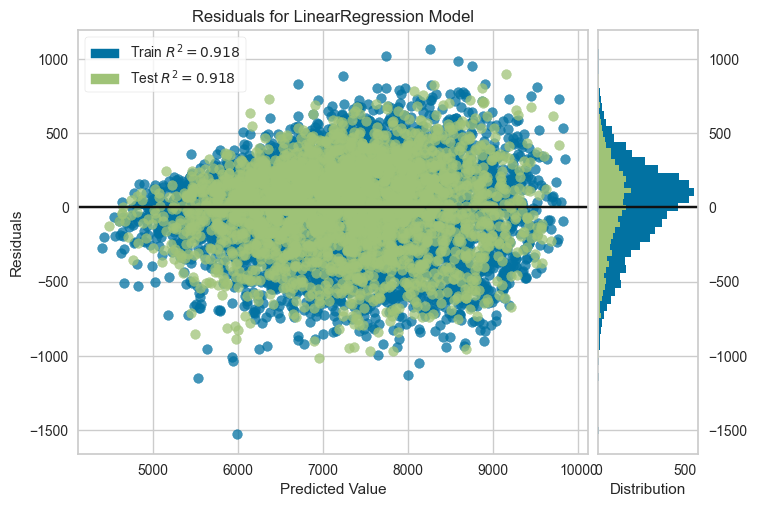

In [ ]:
exp_without.plot_model(best_model_without, plot="residuals")

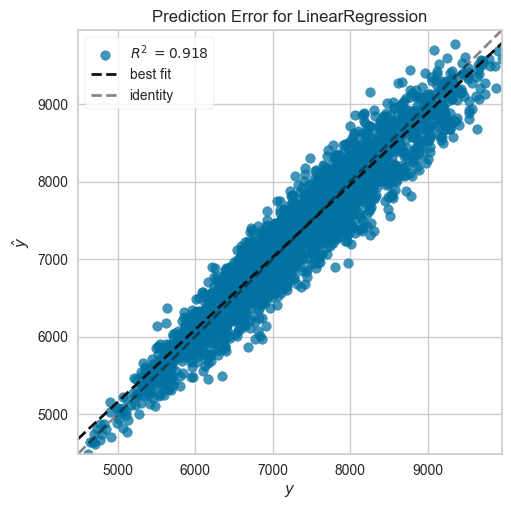

In [ ]:
exp_without.plot_model(best_model_without, plot="error")

In [ ]:
best_final_model = exp_without.finalize_model(best_model_without)
# best_final_model

In [ ]:
exp_without.save_model(best_final_model, "po_final_halfmaraton_model", verbose=False);

## 5. Zapisz model do Digital Ocean Spaces

In [ ]:
BUCKET_NAME = "zad9-domowe"
MODEL_FILENAME = "po_final_halfmaraton_model.pkl"


if os.path.exists(MODEL_FILENAME):
    print(f"\n✅ Znaleziono lokalny plik modelu: {MODEL_FILENAME}")
    
    s3_key_latest = f"models/{MODEL_FILENAME}"
    
    try:
        
        print(f"\n📤 Wysyłam model do bucketu '{BUCKET_NAME}'...")
        s3.upload_file(
            Filename=MODEL_FILENAME,
            Bucket=BUCKET_NAME,
            Key=s3_key_latest
        )
        print(f"✅ Model zapisany jako: {s3_key_latest}")
        
        
        response = s3.head_object(Bucket=BUCKET_NAME, Key=s3_key_latest)
        cloud_size_mb = response['ContentLength'] / (1024 * 1024)
        print(f"\n✅ Weryfikacja: Model w chmurze ma {cloud_size_mb:.2f} MB")
        
  
        
    except Exception as e:
        print(f"\n❌ Błąd podczas wysyłania modelu: {e}")
        
else:
    print(f"\n❌ Nie znaleziono pliku modelu: {MODEL_FILENAME}")
    print("Upewnij się, że model został zapisany lokalnie przed wysłaniem do chmury.")


✅ Znaleziono lokalny plik modelu: po_final_halfmaraton_model.pkl

📤 Wysyłam model do bucketu 'zad9-domowe'...
✅ Model zapisany jako: models/po_final_halfmaraton_model.pkl

✅ Weryfikacja: Model w chmurze ma 0.01 MB
